# Imports

In [649]:
import pandas as pd

from sklearn.model_selection import train_test_split
import xgboost as xgb

# Load raw data

In [650]:
label_file_path = "variable_view_with_value_labels.csv"
label_ds = pd.read_csv(label_file_path, index_col='variable_name',)
label_ds = label_ds.fillna({'value_label_set':'', 'value_labels':''})

label_ds

,variable_label,value_label_set,value_labels
variable_name,,,
id.case,"ID,case - unique identifier - LAL 2025",,
responsemode,ResponseMode,labels0,1.0 = Face-to-face interview; 2.0 = Postal; 3....
mergeid,MergeID_Unique numeric ID,,
q1,"In the past 7 days, have you done a continuous...",labels1,1.0 = Yes; 2.0 = No; 3.0 = Don’t know; 4.0 = P...
q1a,"In the past 7 days, on how many days did you d...",labels2,1.0 = 1; 2.0 = 2; 3.0 = 3; 4.0 = 4; 5.0 = 5; 6...
...,...,...,...
dep_children,Any dependent children (0-15 or dependent 16-19)?,labels81,1.0 = Yes
no_dep_children,No dependent children (0-15 or dependent 16-19)?,labels81,1.0 = Yes
receive_oow_ben,Receive OOW benefits,labels82,1.0 = Yes; 2.0 = No; 3.0 = Not stated


In [651]:
def load_answer_labels(ds, q_label):
  t = dict()
  if q_label in ds.index:
    labels = ds.loc[q_label]['value_labels']
    if labels:
      for r in labels.split(';'):
        ind = r.find('=')
        k, v = r[:ind], r[ind+1:]
        t[k.strip()] = v.strip()
  return t

q2_answers = load_answer_labels(label_ds, 'q2')
print(q2_answers)

mins_total_activ_answers = load_answer_labels(label_ds, 'mins_total_activ')
print(mins_total_activ_answers)

broad_area_name_answers = load_answer_labels(label_ds, 'broad_area_name')
print(broad_area_name_answers)

{'1.0': 'Yes', '2.0': 'No', '3.0': 'Don’t know', '4.0': 'Prefer not to say'}
{}
{}


In [652]:
file_path = "data_raw__no_index.csv"  
# file_path = "data_raw__no_index_area_classified_main.csv" !!!!!! mb change

raw_ds = pd.read_csv(file_path)


raw_ds

,id.case,responsemode,mergeid,q1,q1a,q1b,q1bb,q1b_dk,q1c,q2,...,postcode_lookup_status,area_interest_code,area_assignment_source,area_interest_name,broad_area_name,area_classification_changed,area_correction_reason,area_uncertainty_reason,area_classification_uncertain,area_validation_note
0,00486f03-815d-4831-8d2b-a0ce1af11788,3.0,60785.0,2.0,NaN,NaN,NaN,NaN,NaN,2.0,...,matched,14.0,authoritative_postcode_consensus,Exeter: Hamlins Lane and Honeylands area,Mincinglake,False,NaN,NaN,False,NaN
1,0065efaf-f27a-4122-b536-abf0b1ea0913,1.0,9618.0,1.0,2.0,0.0,40.0,NaN,1.0,2.0,...,matched,21.0,authoritative_non_exeter_postcode,Cranbrook,Cranbrook,False,NaN,NaN,False,NaN
2,0067f207-733c-4fa8-8672-c1a0d121293b,2.0,8321.0,1.0,3.0,NaN,30.0,NaN,1.0,2.0,...,matched,21.0,authoritative_non_exeter_postcode,Cranbrook,Cranbrook,False,NaN,NaN,False,NaN
3,00a1b94f-760c-444b-8e1f-b2fa44874874,2.0,8582.0,2.0,NaN,NaN,NaN,NaN,NaN,4.0,...,matched,21.0,authoritative_non_exeter_postcode,Cranbrook,Cranbrook,False,NaN,NaN,False,NaN
4,00a20603-1d79-4b04-8d58-9f896fb4f3af,1.0,7838.0,1.0,5.0,NaN,45.0,NaN,2.0,2.0,...,matched,19.0,authoritative_postcode_consensus,Exeter: Whipton - Leypark Road and Bramley Ave...,Whipton,False,NaN,NaN,False,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1659,ffb8947a-31ce-4fdf-bc8f-1a29f00c110b,1.0,5791.0,1.0,4.0,NaN,30.0,NaN,1.0,2.0,...,matched,14.0,authoritative_postcode_consensus,Exeter: Hamlins Lane and Honeylands area,Mincinglake,False,NaN,NaN,False,NaN
1660,ffc7fc33-a65e-4bba-867e-a6a4a19c5d20,1.0,3124.0,1.0,4.0,1.0,NaN,NaN,1.0,2.0,...,matched,7.0,authoritative_postcode_consensus,Exeter: City Centre West,St David's,False,NaN,NaN,False,NaN
1661,ffd16292-3a83-400a-856d-6a4e754d3da8,1.0,1919.0,1.0,7.0,NaN,40.0,NaN,2.0,2.0,...,matched,6.0,authoritative_postcode_consensus,Exeter: Cathedral and City Centre East,City Centre,False,NaN,NaN,False,NaN
1662,ffe752c8-e9aa-4a30-9ab9-c916d55be57d,1.0,2804.0,1.0,5.0,NaN,20.0,NaN,2.0,2.0,...,matched,7.0,authoritative_postcode_consensus,Exeter: City Centre West,St David's,False,NaN,NaN,False,NaN


In [653]:
raw_column_names = list(raw_ds.columns)

# Data-preparation functions

In [654]:
import pandas as pd

def drop_columns(df, columns_to_drop):
    """
    Remove columns from a DataFrame by name.

    Args:
        df: Input DataFrame.
        columns_to_drop: List of column names to remove.

    Returns:
        DataFrame without the specified columns.
    """
    return pd.DataFrame(df).drop(columns=columns_to_drop)

In [655]:
def clean_empty_in_column(df, column_names):
    """
    Remove rows with missing values in one specified column.

    Args:
        df: Input DataFrame.
        column_name: Column name (string).

    Returns:
        DataFrame without rows with missing values in that column.
    """
    return df.dropna(subset=column_names)

In [656]:
def replace_values(df, column_name, mapping_dict):
    """
    Replace values in a specified column according to a mapping dictionary.

    Args:
        df: Input DataFrame.
        column_name: Column name (string).
        mapping_dict: Replacement mapping {old_value: new_value}.

    Returns:
        DataFrame with the replaced values.
    """
    df_copy = df.copy()
    df_copy[column_name] = df_copy[column_name].replace(mapping_dict)
    return df_copy

In [657]:
def fill_empty_values(df, default_value_dict={}):
    """
    Replace missing values with a default value in specified columns.

    Args:
        df: Input DataFrame.
        columns: A list of column names or one column name (string).
        default_value: Value used to replace missing entries.

    Returns:
        DataFrame with replaced values.
    """
    return df.fillna(default_value_dict)

In [658]:
def calc_time_col(df, time_col, hour_col, min_col):
  df = fill_empty_values(df, {col: 0 for col in [hour_col, min_col]})
  df[time_col] = 60*df[hour_col] + df[min_col]
  return df

In [659]:
def create_categorical_from_bins(df, column, new_column_name, bins, labels=None):
    """
    Create a categorical feature by splitting a numeric field into ranges.

    Args:
        df: Input DataFrame.
        column: Source numeric column.
        new_column_name: Name of the new column.
        bins: Number of intervals or a list of boundaries.
        labels: Optional category labels.

    Returns:
        DataFrame with the new column.
    """
    df[new_column_name] = pd.cut(df[column], bins=bins, labels=labels)
    return df

In [660]:
def convert_column_types(df, columns, target_type):
    """
    Convert specified object columns to a target data type.

    Args:
        df: Input DataFrame.
        columns: A list of column names or one column name (string).
        target_type: Target data type (int, float, str, datetime, category, etc.).

    Returns:
        DataFrame with converted columns.
    """
    if isinstance(columns, str):
        columns = [columns]

    for col in columns:
        if col in df.columns:
            df[col] = df[col].astype(target_type)

    return df

In [661]:
DK_ANSWERS = [
    'Don’t know',
    "Don't know",
    'Prefer not to say',
    'Not applicable',
    'Not stated',
    ]

In [662]:
def get_dk_keys(column):
  # print(column)
  col_answers = load_answer_labels(label_ds, column)
  # print(col_answers)
  keys = []
  for ans in DK_ANSWERS:
    keys += [float(k) for k, v in col_answers.items() if v == ans]
  # print(column, keys)
  other = [float(k) for k in col_answers.keys() if float(k) not in keys]
  return keys, other

In [663]:
get_dk_keys('Q8a')

([3.0, 4.0], [1.0, 2.0])

In [664]:
get_dk_keys('broad_area_name')

([], [])

In [665]:
def process_not_specified_col(df, column, new_column=None):
  keys, other = get_dk_keys(column)
  # print('===', column, new_column, keys, other)
  if keys:
    df = df.fillna({column: keys[0]})
  if new_column:
    df[new_column] = df[column].isin(keys).astype(int)
  df = replace_values(df, column, {k: None for k in keys})
  # print(df[col].value_counts())
  return df

In [666]:
def process_dummy_col(df, column, add_all=False):
  new_columns = []
  keys, other = get_dk_keys(column)
  if add_all:
    print('--- all:', other)
    vals = df[column].value_counts().index
    for v in vals:
      if v not in other:
        other.append(v)
    print('+++ all:', other)

  for v in other:
    col_name = f'{column}_{v}'
    # print(f'dummy {col_name}')
    df[col_name] = (df[column]==v).astype(int)
    new_columns.append(col_name)
  col_name = f'{column}_dk'
  df[col_name] = (~df[column].isin(other)).astype(int)
  new_columns.append(col_name)
  return df, new_columns

In [667]:
import matplotlib.pyplot as plt

def plot_column_histogram(df, column, bins=10, figsize=(10, 6), title=None,
                          xlabel=None, ylabel='Frequency', color='steelblue',
                          edgecolor='black', alpha=0.7, show_stats=False):
    """Plot a histogram of values in a chosen column."""
    fig, ax = plt.subplots(figsize=figsize)


    n, bins, patches = ax.hist(df[column].dropna(), bins=bins,
                                color=color, edgecolor=edgecolor,
                                alpha=alpha, rwidth=0.95)


    if title is None:
        title = f'Distribution of {column}'
    ax.set_title(title, fontsize=14, fontweight='bold')

    if xlabel is None:
        xlabel = column
    ax.set_xlabel(xlabel, fontsize=12)
    ax.set_ylabel(ylabel, fontsize=12)


    ax.grid(True, alpha=0.3, linestyle='--')


    if show_stats:
        col_data = df[column].dropna()
        stats_text = (f'Amount: {len(col_data)}\n'
                      f'Mean: {col_data.mean():.2f}\n'
                      f'Median: {col_data.median():.2f}\n'
                      f'St. Dev: {col_data.std():.2f}\n'
                      f'Min: {col_data.min():.2f}\n'
                      f'Max: {col_data.max():.2f}')

        ax.text(0.95, 0.95, stats_text,
                transform=ax.transAxes,
                verticalalignment='top',
                horizontalalignment='right',
                bbox=dict(boxstyle='round', facecolor='white', alpha=0.8),
                fontsize=10)

    plt.tight_layout()
    return fig, ax

# Question-tree construction methods

In [668]:
# [
#     ['q1', 'group', [
#         ['q1a', 'int', []], ['q1b_dk', 'time',
#     ]]
# ]

In [669]:
def q_float(col, dk_proc='fill_0', add_to_model=True):
  node = [col, 'float', dk_proc, add_to_model, None, None]
  return node

In [670]:
def q_int(col, dk_proc='fill_0', add_to_model=True):
  node = [col, 'int', dk_proc, add_to_model, None, None]
  return node

In [671]:
def q_dk_int(col, dk_col, dk_proc='fill_0', add_to_model=True):
  node = [dk_col, 'dk_int', None, add_to_model, [
      [col, 'int', dk_proc, add_to_model, None, None]
  ], None]
  return node

In [672]:
def q_scale(col, dk_proc='dk_column', add_to_model=True, mapping=None):
  node = [col, 'scale', dk_proc, add_to_model, None, {'mapping':mapping}]
  return node

In [673]:
def q_dummy(col, dk_proc='dk_dummy', add_to_model=False):
  node = [col, 'dummy', dk_proc, add_to_model, None, None]
  return node

In [674]:
def q_time_group(col, childs, add_to_model=False):
  node = [col, 'time_group', None, add_to_model, childs, None]
  return node

In [675]:
def q_time(col, col_h, col_m, col_time):
  node = [col, 'time_dk', 'fill_0', True, [q_time_group(col_time,
      [
          [col_h, 'hours', 'fill_0', None, False, None],
          [col_m, 'minutes', 'fill_0', None, False, None],
      ], add_to_model=True
  )], None]
  return node

In [676]:
def q_group(col, childs, dk_proc=None, add_to_model=False):
  node = [col, 'group', dk_proc, add_to_model, childs, None]
  return node

In [677]:
def q_united_group(col, childs, dk_proc=None, add_to_model=True, weights=None):
  node = [col, 'united_group', dk_proc, add_to_model, childs, {'weights':weights}]
  return node

In [678]:
def process_dk(df, col, dk_proc):
  # print('***', col, dk_proc, df.columns)
  new_columns = []
  if dk_proc == 'fill_0':
    df = process_not_specified_col(df, col, new_column=None)
    df = fill_empty_values(df, {col: 0})
  elif dk_proc == 'dk_column':
    df = process_not_specified_col(df, col, new_column=col+'_dk')
    df = fill_empty_values(df, {col: 0})
    new_columns = [col+'_dk']
  elif dk_proc == 'dk_dummy':
    df, new_columns = process_dummy_col(df, col)
  elif dk_proc == 'dk_dummy_add_all':
    df, new_columns = process_dummy_col(df, col, add_all=True)
  # print('*=*=*', col, dk_proc, df.columns)
  return df, new_columns

# Build the survey question tree

In [679]:
raw_target = 'activity_level'

# raw_target = 'mins_total_activ'
# raw_target = 'mins_total_any'

In [680]:
tree = q_group('Q0',
    [
        q_group('q1',
            [
            q_int('q1a', dk_proc='dk_column'),
            q_time('q1b_dk', 'q1b', 'q1bb', 'q1_time'),
            q_int('q1c'),
            ], dk_proc='dk_column', add_to_model=True
        ),
      q_group('q2',
            [
            q_int('q2a'),
            q_time('q2b_dk', 'q2b', 'q2bb', 'q2_time'),
            q_int('q2c'),
            ], dk_proc='dk_column', add_to_model=True
        ),
        q_group('q3',
            [
            q_int('q3a'),
            q_time('q3b_dk', 'q3b', 'q3bb', 'q3_time'),
            q_int('q3c'),
            ], dk_proc='dk_column', add_to_model=True
        ),
        q_united_group('q4',
            [
            q_scale('q4a', mapping={1.0:3, 2.0:1, 3.0:0, 4.0:-1, 5.0:-3}),
            q_scale('q4b', mapping={1.0:3, 2.0:1, 3.0:0, 4.0:-1, 5.0:-3}),
            q_scale('q4c', mapping={1.0:3, 2.0:1, 3.0:0, 4.0:-1, 5.0:-3}),
            q_scale('q4d', mapping={1.0:3, 2.0:1, 3.0:0, 4.0:-1, 5.0:-3}),
            q_scale('q4e', mapping={1.0:3, 2.0:1, 3.0:0, 4.0:-1, 5.0:-3}),
            ], weights={'q4a':1, 'q4b':1, 'q4c':1, 'q4d':1, 'q4e':1,}
        ),
        q_united_group('q5',
            [
            q_scale('q5a', dk_proc='fill_0'),
            q_scale('q5b', dk_proc='fill_0'),
            q_scale('q5c', dk_proc='fill_0'),
            q_scale('q5d', dk_proc='fill_0'),
            ], weights={'q5a':1, 'q5b':1, 'q5c':1, 'q5d':-1,}
        ),
        q_scale('q6'),
        q_scale('q7'),
        q_group('q8',
            [
            q_int('q8_1'),
            q_int('q8_2'),
            q_int('q8_3'),
            q_int('q8_4'),
            q_int('q8_5'),
            q_int('q8_6'),
            q_int('q8_7'),
            q_int('q8_8'),
            q_int('q8_9'),
            ]
        ),
        q_scale('Q8a'),
        q_united_group('q9',
            [
            q_scale('q9a', dk_proc='fill_0'),
            q_scale('q9b', dk_proc='fill_0'),
            q_scale('q9c', dk_proc='fill_0'),
            q_scale('q9d', dk_proc='fill_0'),
            q_scale('q9e', dk_proc='fill_0'),
            q_scale('q9f', dk_proc='fill_0'),
            q_scale('q9g', dk_proc='fill_0'),
            q_scale('q9h', dk_proc='fill_0'),
            q_scale('q9i', dk_proc='fill_0'),
            q_scale('q9j', dk_proc='fill_0'),
            q_scale('q9k', dk_proc='fill_0'),
            q_scale('q9l', dk_proc='fill_0'),
            q_scale('q9m', dk_proc='fill_0'),
            q_scale('q9n', dk_proc='fill_0'),
            q_scale('q9o', dk_proc='fill_0'),
            q_scale('q9p', dk_proc='fill_0'),
            ], weights={
                'q9a':1, 'q9b':1, 'q9c':1, 'q9d':1,
                'q9e':1, 'q9f':1, 'q9g':1, 'q9h':1,
                'q9i':1, 'q9j':1, 'q9k':1, 'q9l':1,
                'q9m':1, 'q9n':1, 'q9o':1, 'q9p':1,
                }
        ),
        q_dummy('q10'),
        q_int('q10b'),
        q_int('q11', dk_proc='fill_0'),
        q_int('q11a', dk_proc='fill_0'),
        q_dummy('q12'),
        q_group('q13',
            [
            q_int('q13ap', dk_proc='dk_column'),
            q_int('q13a2'),
            q_int('q13a3'),
            q_int('q13_sum'),
            ]
        ),
        q_group('q14',
            [
            q_int('q14bp', dk_proc='dk_column'),
            q_int('q14b'),
            q_int('q14b2'),
            q_int('q14b3'),
            q_int('q14_sum'),
            ]
        ),
        q_int('q13_q14_sum'),
        q_group('q15',
            [
            q_int('q15_hhold_1'),
            q_int('q15_hhold_2'),
            q_int('q15_hhold_3'),
            q_int('q15_hhold_4'),
            q_int('q15_hhold_5'),
            q_int('q15_hhold_6'),
            q_int('q15_hhold_7'),
            q_int('q15_hhold_8'),
            q_int('q15_hhold_9'),
            q_int('q15_hhold_10'),
            q_int('q15_hhold_11'),
            q_int('q15_hhold_12'),
            ]
        ),
        q_int('q16'),
        q_int('q17'),
        q_scale('q18'),
        q_dummy('q19'),
        q_int('q20'),
        q_dummy('q21'),
        q_int('q22'),
        q_dummy('q23'),
        q_dummy('q24'),
        q_dummy('q25'),
        q_dummy('q26'),
        q_dummy('q27'),
        q_group('q28',
            [
            q_int('q28a_1'),
            q_int('q28a_2'),
            q_int('q28a_3'),
            q_int('q28a_4'),
            q_int('q28a_5'),
            q_int('q28a_6'),
            q_int('q28a_7'),
            q_int('q28a_8'),
            q_int('q28a_9'),
            q_int('q28a_10'),
            q_dummy('q28b'),
            ]
        ),
        # q_regoin('q29'), # TODO ?
        q_group('q30',
            [
            q_int('q30_1'),
            q_int('q30_2'),
            q_int('q30_3'),
            q_int('q30_4'),
            ]
        ),
        q_group('q31',
            [
            q_int('q31_1'),
            q_int('q31_2'),
            q_int('q31_3'),
            q_int('q31_4'),
            q_int('q31_5'),
            ]
        ),
        q_group('q32',
            [
            q_int('q32_1'),
            q_int('q32_2'),
            q_int('q32_3'),
            q_int('q32_4'),
            q_int('q32_5'),
            q_int('q32_6'),
            q_int('q32_7'),
            q_int('q32_8'),
            q_int('q32_9'),
            ]
        ),
        q_group('Q33',
            [
            q_int('q33dk', dk_proc='dk_column'),
            q_float('q33'),
            q_float('q33a'),
            ]
        ),
        # q_regoin('q34'), # TODO ?

        # q_dummy('mins_activ_bkdwn'),
        # q_dummy('mins_any_bkdwn'),
        q_scale('activity_level'),
        q_float('mins_total_activ'),
        q_float('mins_total_any'),
        # q_dummy('lsoa_name'),
        # q_dummy('location'),
        # q_float('weight'),
        # q_scale('inactive1'),
        # q_scale('inactive2'),
        # q_int('walk10minsbr'),
        # q_int('cycle10minsbr'),
        # q_int('sports10minsbr'),
        # q_scale('dayswalk_rbr'),
        # q_scale('dayscycle_rbr'),
        # q_scale('dayssport_rbr'),
        q_dummy('ns_sec'),
        q_dummy('ns_sec_summ'),
        q_int('dep_children'),
        q_int('no_dep_children'),
        q_int('receive_oow_ben'),
        q_int('low_income_fam'),
        q_int('workage_ndc_bens'),
        q_dummy('broad_area_name', dk_proc='dk_dummy_add_all'),
    ]
)

In [681]:
tree

['Q0',
 'group',
 None,
 False,
 [['q1',
   'group',
   'dk_column',
   True,
   [['q1a', 'int', 'dk_column', True, None, None],
    ['q1b_dk',
     'time_dk',
     'fill_0',
     True,
     [['q1_time',
       'time_group',
       None,
       True,
       [['q1b', 'hours', 'fill_0', None, False, None],
        ['q1bb', 'minutes', 'fill_0', None, False, None]],
       None]],
     None],
    ['q1c', 'int', 'fill_0', True, None, None]],
   None],
  ['q2',
   'group',
   'dk_column',
   True,
   [['q2a', 'int', 'fill_0', True, None, None],
    ['q2b_dk',
     'time_dk',
     'fill_0',
     True,
     [['q2_time',
       'time_group',
       None,
       True,
       [['q2b', 'hours', 'fill_0', None, False, None],
        ['q2bb', 'minutes', 'fill_0', None, False, None]],
       None]],
     None],
    ['q2c', 'int', 'fill_0', True, None, None]],
   None],
  ['q3',
   'group',
   'dk_column',
   True,
   [['q3a', 'int', 'fill_0', True, None, None],
    ['q3b_dk',
     'time_dk',
     'fi

# Preprocess raw data

In [682]:
source_ds = pd.DataFrame(raw_ds)

In [683]:
source_ds

,id.case,responsemode,mergeid,q1,q1a,q1b,q1bb,q1b_dk,q1c,q2,...,postcode_lookup_status,area_interest_code,area_assignment_source,area_interest_name,broad_area_name,area_classification_changed,area_correction_reason,area_uncertainty_reason,area_classification_uncertain,area_validation_note
0,00486f03-815d-4831-8d2b-a0ce1af11788,3.0,60785.0,2.0,NaN,NaN,NaN,NaN,NaN,2.0,...,matched,14.0,authoritative_postcode_consensus,Exeter: Hamlins Lane and Honeylands area,Mincinglake,False,NaN,NaN,False,NaN
1,0065efaf-f27a-4122-b536-abf0b1ea0913,1.0,9618.0,1.0,2.0,0.0,40.0,NaN,1.0,2.0,...,matched,21.0,authoritative_non_exeter_postcode,Cranbrook,Cranbrook,False,NaN,NaN,False,NaN
2,0067f207-733c-4fa8-8672-c1a0d121293b,2.0,8321.0,1.0,3.0,NaN,30.0,NaN,1.0,2.0,...,matched,21.0,authoritative_non_exeter_postcode,Cranbrook,Cranbrook,False,NaN,NaN,False,NaN
3,00a1b94f-760c-444b-8e1f-b2fa44874874,2.0,8582.0,2.0,NaN,NaN,NaN,NaN,NaN,4.0,...,matched,21.0,authoritative_non_exeter_postcode,Cranbrook,Cranbrook,False,NaN,NaN,False,NaN
4,00a20603-1d79-4b04-8d58-9f896fb4f3af,1.0,7838.0,1.0,5.0,NaN,45.0,NaN,2.0,2.0,...,matched,19.0,authoritative_postcode_consensus,Exeter: Whipton - Leypark Road and Bramley Ave...,Whipton,False,NaN,NaN,False,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1659,ffb8947a-31ce-4fdf-bc8f-1a29f00c110b,1.0,5791.0,1.0,4.0,NaN,30.0,NaN,1.0,2.0,...,matched,14.0,authoritative_postcode_consensus,Exeter: Hamlins Lane and Honeylands area,Mincinglake,False,NaN,NaN,False,NaN
1660,ffc7fc33-a65e-4bba-867e-a6a4a19c5d20,1.0,3124.0,1.0,4.0,1.0,NaN,NaN,1.0,2.0,...,matched,7.0,authoritative_postcode_consensus,Exeter: City Centre West,St David's,False,NaN,NaN,False,NaN
1661,ffd16292-3a83-400a-856d-6a4e754d3da8,1.0,1919.0,1.0,7.0,NaN,40.0,NaN,2.0,2.0,...,matched,6.0,authoritative_postcode_consensus,Exeter: Cathedral and City Centre East,City Centre,False,NaN,NaN,False,NaN
1662,ffe752c8-e9aa-4a30-9ab9-c916d55be57d,1.0,2804.0,1.0,5.0,NaN,20.0,NaN,2.0,2.0,...,matched,7.0,authoritative_postcode_consensus,Exeter: City Centre West,St David's,False,NaN,NaN,False,NaN


In [684]:
def get_param(d, name, default_value=None):
  if d:
    return d.get(name, default_value)
  return default_value

In [685]:
model_fields_cols = []
# st = [tree]
# while len(st) > 0:
def process_node(node, source_ds, model_fields_cols):
  # print(st[0])
  # col, col_type, dk_proc, add_to_model, childs, params = st.pop(0)
  # print('--***--', node[0])
  col, col_type, dk_proc, add_to_model, childs, params = node
  if add_to_model:
    model_fields_cols.append(col)

  if childs:
    # st = childs + st
    # print('--childs--', childs)
    for ch in childs:
      source_ds, model_fields_cols = process_node(ch, source_ds, model_fields_cols)

  if dk_proc:
    source_ds, new_columns = process_dk(source_ds, col, dk_proc)
    model_fields_cols.extend(new_columns)

  if col_type == 'time_group':
    col_h = childs[0]
    # source_ds, _ = process_dk(source_ds, col_h[0], col_h[2])
    col_m = childs[1]
    # source_ds, _ = process_dk(source_ds, col_m[0], col_m[2])
    source_ds = calc_time_col(source_ds, col, col_h[0], col_m[0])
  elif col_type == 'int':
    source_ds[col] = source_ds[col].astype(str).str.replace(',', '').astype(float).astype(int)
  elif col_type == 'float':
    source_ds[col] = source_ds[col].astype(str).str.replace(',', '').astype(float)
  elif col_type == 'scale':
    mapping = get_param(params, 'mapping')
    # print('--- scale', col, mapping, params)
    if mapping:
      source_ds[col] = source_ds[col].replace(mapping)
  elif col_type == 'united_group':
    weights = get_param(params, 'weights')
    # print('--- united_group', col, weights, params)
    if weights:
      source_ds[col] = sum(source_ds[sub_col] * weight for sub_col, weight in weights.items())

  # if col_type == 'time_group':

  return source_ds, model_fields_cols

source_ds, model_fields_cols = process_node(tree, source_ds, model_fields_cols)
print(model_fields_cols)

C:\Users\Raiet\AppData\Local\Temp\ipykernel_13520\2916678983.py:13: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  return df.fillna(default_value_dict)
C:\Users\Raiet\AppData\Local\Temp\ipykernel_13520\2916678983.py:13: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  return df.fillna(default_value_dict)
C:\Users\Raiet\AppData\Local\Temp\ipykernel_13520\2916678983.py:13: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the f

C:\Users\Raiet\AppData\Local\Temp\ipykernel_13520\2916678983.py:13: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  return df.fillna(default_value_dict)
C:\Users\Raiet\AppData\Local\Temp\ipykernel_13520\2916678983.py:13: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  return df.fillna(default_value_dict)
C:\Users\Raiet\AppData\Local\Temp\ipykernel_13520\2916678983.py:13: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the f

--- all: []
+++ all: ['Cranbrook', 'Wonford', 'St Thomas', 'Whipton', 'Mincinglake', 'Beacon Heath', "St David's", 'City Centre', 'Exwick', 'Redhills', 'Newtown', 'Countess Wear']
['q1', 'q1a', 'q1a_dk', 'q1b_dk', 'q1_time', 'q1c', 'q1_dk', 'q2', 'q2a', 'q2b_dk', 'q2_time', 'q2c', 'q2_dk', 'q3', 'q3a', 'q3b_dk', 'q3_time', 'q3c', 'q3_dk', 'q4', 'q4a', 'q4a_dk', 'q4b', 'q4b_dk', 'q4c', 'q4c_dk', 'q4d', 'q4d_dk', 'q4e', 'q4e_dk', 'q5', 'q5a', 'q5b', 'q5c', 'q5d', 'q6', 'q6_dk', 'q7', 'q7_dk', 'q8_1', 'q8_2', 'q8_3', 'q8_4', 'q8_5', 'q8_6', 'q8_7', 'q8_8', 'q8_9', 'Q8a', 'Q8a_dk', 'q9', 'q9a', 'q9b', 'q9c', 'q9d', 'q9e', 'q9f', 'q9g', 'q9h', 'q9i', 'q9j', 'q9k', 'q9l', 'q9m', 'q9n', 'q9o', 'q9p', 'q10_1.0', 'q10_2.0', 'q10_3.0', 'q10_4.0', 'q10_dk', 'q10b', 'q11', 'q11a', 'q12_1.0', 'q12_2.0', 'q12_3.0', 'q12_4.0', 'q12_5.0', 'q12_6.0', 'q12_7.0', 'q12_dk', 'q13ap', 'q13ap_dk', 'q13a2', 'q13a3', 'q13_sum', 'q14bp', 'q14bp_dk', 'q14b', 'q14b2', 'q14b3', 'q14_sum', 'q13_q14_sum', 'q15_hhold

C:\Users\Raiet\AppData\Local\Temp\ipykernel_13520\2916678983.py:13: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  return df.fillna(default_value_dict)
C:\Users\Raiet\AppData\Local\Temp\ipykernel_13520\2916678983.py:13: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  return df.fillna(default_value_dict)
C:\Users\Raiet\AppData\Local\Temp\ipykernel_13520\2916678983.py:13: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the f

In [686]:
source_ds

,id.case,responsemode,mergeid,q1,q1a,q1b,q1bb,q1b_dk,q1c,q2,...,broad_area_name_Whipton,broad_area_name_Mincinglake,broad_area_name_Beacon Heath,broad_area_name_St David's,broad_area_name_City Centre,broad_area_name_Exwick,broad_area_name_Redhills,broad_area_name_Newtown,broad_area_name_Countess Wear,broad_area_name_dk
0,00486f03-815d-4831-8d2b-a0ce1af11788,3.0,60785.0,2.0,0,0.0,0.0,0,0,2.0,...,0,1,0,0,0,0,0,0,0,0
1,0065efaf-f27a-4122-b536-abf0b1ea0913,1.0,9618.0,1.0,2,0.0,40.0,0,1,2.0,...,0,0,0,0,0,0,0,0,0,0
2,0067f207-733c-4fa8-8672-c1a0d121293b,2.0,8321.0,1.0,3,0.0,30.0,0,1,2.0,...,0,0,0,0,0,0,0,0,0,0
3,00a1b94f-760c-444b-8e1f-b2fa44874874,2.0,8582.0,2.0,0,0.0,0.0,0,0,0.0,...,0,0,0,0,0,0,0,0,0,0
4,00a20603-1d79-4b04-8d58-9f896fb4f3af,1.0,7838.0,1.0,5,0.0,45.0,0,2,2.0,...,1,0,0,0,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1659,ffb8947a-31ce-4fdf-bc8f-1a29f00c110b,1.0,5791.0,1.0,4,0.0,30.0,0,1,2.0,...,0,1,0,0,0,0,0,0,0,0
1660,ffc7fc33-a65e-4bba-867e-a6a4a19c5d20,1.0,3124.0,1.0,4,1.0,0.0,0,1,2.0,...,0,0,0,1,0,0,0,0,0,0
1661,ffd16292-3a83-400a-856d-6a4e754d3da8,1.0,1919.0,1.0,7,0.0,40.0,0,2,2.0,...,0,0,0,0,1,0,0,0,0,0
1662,ffe752c8-e9aa-4a30-9ab9-c916d55be57d,1.0,2804.0,1.0,5,0.0,20.0,0,2,2.0,...,0,0,0,1,0,0,0,0,0,0


In [687]:
source_ds['broad_area_name_dk'].value_counts()

broad_area_name_dk
0    1664
Name: count, dtype: int64

In [688]:
source_ds[['q4a', 'q4b', 'q4c', 'q4d', 'q4e', 'q4']]

,q4a,q4b,q4c,q4d,q4e,q4
0,1.0,-3.0,3.0,3.0,1.0,5.0
1,3.0,3.0,3.0,3.0,3.0,15.0
2,1.0,1.0,3.0,3.0,1.0,9.0
3,-3.0,0.0,3.0,3.0,1.0,4.0
4,1.0,1.0,1.0,1.0,1.0,5.0
...,...,...,...,...,...,...
1659,1.0,1.0,0.0,1.0,0.0,3.0
1660,3.0,3.0,1.0,1.0,0.0,8.0
1661,3.0,3.0,3.0,3.0,-1.0,11.0
1662,1.0,1.0,-3.0,-3.0,-3.0,-7.0


In [689]:
source_ds[['q5a', 'q5b', 'q5c', 'q5d', 'q5']]

,q5a,q5b,q5c,q5d,q5
0,9.0,9.0,9.0,3.0,24.0
1,10.0,10.0,10.0,2.0,28.0
2,9.0,9.0,9.0,9.0,18.0
3,3.0,9.0,5.0,1.0,16.0
4,5.0,5.0,5.0,7.0,8.0
...,...,...,...,...,...
1659,8.0,7.0,8.0,2.0,21.0
1660,7.0,8.0,7.0,1.0,21.0
1661,10.0,10.0,9.0,8.0,21.0
1662,9.0,9.0,10.0,2.0,26.0


In [690]:
source_ds['q4a'].value_counts()

q4a
 3.0    675
 1.0    557
-1.0    184
-3.0    137
 0.0    111
Name: count, dtype: int64

In [691]:
source_ds['q4'].value_counts()

q4
 5.0     134
 15.0    132
 13.0    130
 3.0     128
 9.0     111
 1.0     104
 4.0     104
 11.0    103
 2.0      93
 7.0      75
-3.0      60
-1.0      57
-5.0      50
 0.0      50
 12.0     48
-15.0     43
 8.0      38
 6.0      38
-2.0      37
 10.0     27
-7.0      26
-4.0      22
-8.0      12
-11.0     11
-6.0       9
-12.0      9
-9.0       7
-13.0      4
-10.0      2
Name: count, dtype: int64

In [692]:
source_ds

,id.case,responsemode,mergeid,q1,q1a,q1b,q1bb,q1b_dk,q1c,q2,...,broad_area_name_Whipton,broad_area_name_Mincinglake,broad_area_name_Beacon Heath,broad_area_name_St David's,broad_area_name_City Centre,broad_area_name_Exwick,broad_area_name_Redhills,broad_area_name_Newtown,broad_area_name_Countess Wear,broad_area_name_dk
0,00486f03-815d-4831-8d2b-a0ce1af11788,3.0,60785.0,2.0,0,0.0,0.0,0,0,2.0,...,0,1,0,0,0,0,0,0,0,0
1,0065efaf-f27a-4122-b536-abf0b1ea0913,1.0,9618.0,1.0,2,0.0,40.0,0,1,2.0,...,0,0,0,0,0,0,0,0,0,0
2,0067f207-733c-4fa8-8672-c1a0d121293b,2.0,8321.0,1.0,3,0.0,30.0,0,1,2.0,...,0,0,0,0,0,0,0,0,0,0
3,00a1b94f-760c-444b-8e1f-b2fa44874874,2.0,8582.0,2.0,0,0.0,0.0,0,0,0.0,...,0,0,0,0,0,0,0,0,0,0
4,00a20603-1d79-4b04-8d58-9f896fb4f3af,1.0,7838.0,1.0,5,0.0,45.0,0,2,2.0,...,1,0,0,0,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1659,ffb8947a-31ce-4fdf-bc8f-1a29f00c110b,1.0,5791.0,1.0,4,0.0,30.0,0,1,2.0,...,0,1,0,0,0,0,0,0,0,0
1660,ffc7fc33-a65e-4bba-867e-a6a4a19c5d20,1.0,3124.0,1.0,4,1.0,0.0,0,1,2.0,...,0,0,0,1,0,0,0,0,0,0
1661,ffd16292-3a83-400a-856d-6a4e754d3da8,1.0,1919.0,1.0,7,0.0,40.0,0,2,2.0,...,0,0,0,0,1,0,0,0,0,0
1662,ffe752c8-e9aa-4a30-9ab9-c916d55be57d,1.0,2804.0,1.0,5,0.0,20.0,0,2,2.0,...,0,0,0,1,0,0,0,0,0,0


In [693]:
'q1a_dk' in model_fields_cols

True

In [694]:
empty_df = source_ds.isna().sum()
empty_df[empty_df > 0]

q8b                        1077
q9.1                        954
q12aa                        24
q18_oth                    1644
q19                        1614
q21                         180
q23                         292
q24                        1499
q25                        1622
q26                         114
q27                         863
q28a_oth                   1641
q28b                        991
q29                         889
q30_oth                    1392
mins_activ_bkdwn             28
mins_any_bkdwn                4
inactive1                   948
inactive2                   926
postcode_clean                2
postcode_lsoa21cd             2
postcode_lsoa21nm             2
postcode_ward24nm             2
postcode_lad24nm              2
area_correction_reason     1641
area_uncertainty_reason    1660
area_validation_note       1660
dtype: int64

In [695]:
empty_df

id.case                          0
responsemode                     0
mergeid                          0
q1                               0
q1a                              0
                                ..
broad_area_name_Exwick           0
broad_area_name_Redhills         0
broad_area_name_Newtown          0
broad_area_name_Countess Wear    0
broad_area_name_dk               0
Length: 286, dtype: int64

In [696]:
empty_df['q1a_dk']

np.int64(0)

In [697]:
clean_empty_cols = [raw_target] + model_fields_cols
clean_empty_cols

['activity_level',
 'q1',
 'q1a',
 'q1a_dk',
 'q1b_dk',
 'q1_time',
 'q1c',
 'q1_dk',
 'q2',
 'q2a',
 'q2b_dk',
 'q2_time',
 'q2c',
 'q2_dk',
 'q3',
 'q3a',
 'q3b_dk',
 'q3_time',
 'q3c',
 'q3_dk',
 'q4',
 'q4a',
 'q4a_dk',
 'q4b',
 'q4b_dk',
 'q4c',
 'q4c_dk',
 'q4d',
 'q4d_dk',
 'q4e',
 'q4e_dk',
 'q5',
 'q5a',
 'q5b',
 'q5c',
 'q5d',
 'q6',
 'q6_dk',
 'q7',
 'q7_dk',
 'q8_1',
 'q8_2',
 'q8_3',
 'q8_4',
 'q8_5',
 'q8_6',
 'q8_7',
 'q8_8',
 'q8_9',
 'Q8a',
 'Q8a_dk',
 'q9',
 'q9a',
 'q9b',
 'q9c',
 'q9d',
 'q9e',
 'q9f',
 'q9g',
 'q9h',
 'q9i',
 'q9j',
 'q9k',
 'q9l',
 'q9m',
 'q9n',
 'q9o',
 'q9p',
 'q10_1.0',
 'q10_2.0',
 'q10_3.0',
 'q10_4.0',
 'q10_dk',
 'q10b',
 'q11',
 'q11a',
 'q12_1.0',
 'q12_2.0',
 'q12_3.0',
 'q12_4.0',
 'q12_5.0',
 'q12_6.0',
 'q12_7.0',
 'q12_dk',
 'q13ap',
 'q13ap_dk',
 'q13a2',
 'q13a3',
 'q13_sum',
 'q14bp',
 'q14bp_dk',
 'q14b',
 'q14b2',
 'q14b3',
 'q14_sum',
 'q13_q14_sum',
 'q15_hhold_1',
 'q15_hhold_2',
 'q15_hhold_3',
 'q15_hhold_4',
 'q15_hhold_5

In [698]:
empty_df = source_ds[clean_empty_cols].isna().sum()
empty_df[empty_df > 0]

Series([], dtype: int64)

In [699]:
source_ds_cleaned = clean_empty_in_column(source_ds, clean_empty_cols)
source_ds_cleaned

,id.case,responsemode,mergeid,q1,q1a,q1b,q1bb,q1b_dk,q1c,q2,...,broad_area_name_Whipton,broad_area_name_Mincinglake,broad_area_name_Beacon Heath,broad_area_name_St David's,broad_area_name_City Centre,broad_area_name_Exwick,broad_area_name_Redhills,broad_area_name_Newtown,broad_area_name_Countess Wear,broad_area_name_dk
0,00486f03-815d-4831-8d2b-a0ce1af11788,3.0,60785.0,2.0,0,0.0,0.0,0,0,2.0,...,0,1,0,0,0,0,0,0,0,0
1,0065efaf-f27a-4122-b536-abf0b1ea0913,1.0,9618.0,1.0,2,0.0,40.0,0,1,2.0,...,0,0,0,0,0,0,0,0,0,0
2,0067f207-733c-4fa8-8672-c1a0d121293b,2.0,8321.0,1.0,3,0.0,30.0,0,1,2.0,...,0,0,0,0,0,0,0,0,0,0
3,00a1b94f-760c-444b-8e1f-b2fa44874874,2.0,8582.0,2.0,0,0.0,0.0,0,0,0.0,...,0,0,0,0,0,0,0,0,0,0
4,00a20603-1d79-4b04-8d58-9f896fb4f3af,1.0,7838.0,1.0,5,0.0,45.0,0,2,2.0,...,1,0,0,0,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1659,ffb8947a-31ce-4fdf-bc8f-1a29f00c110b,1.0,5791.0,1.0,4,0.0,30.0,0,1,2.0,...,0,1,0,0,0,0,0,0,0,0
1660,ffc7fc33-a65e-4bba-867e-a6a4a19c5d20,1.0,3124.0,1.0,4,1.0,0.0,0,1,2.0,...,0,0,0,1,0,0,0,0,0,0
1661,ffd16292-3a83-400a-856d-6a4e754d3da8,1.0,1919.0,1.0,7,0.0,40.0,0,2,2.0,...,0,0,0,0,1,0,0,0,0,0
1662,ffe752c8-e9aa-4a30-9ab9-c916d55be57d,1.0,2804.0,1.0,5,0.0,20.0,0,2,2.0,...,0,0,0,1,0,0,0,0,0,0


In [700]:
cleaned_indexes = list(set(source_ds.index) - set(source_ds_cleaned.index))
cleaned_indexes

[]

In [701]:
if cleaned_indexes:
  row = source_ds.iloc[cleaned_indexes[0]]
  for col, value in row.items():
      print(f"{col:12}: {value}")
  print()

# Create the target variable

In [702]:
is_binary_class = False # False

target_col_name = 'target'

In [703]:
source_ds = source_ds_cleaned

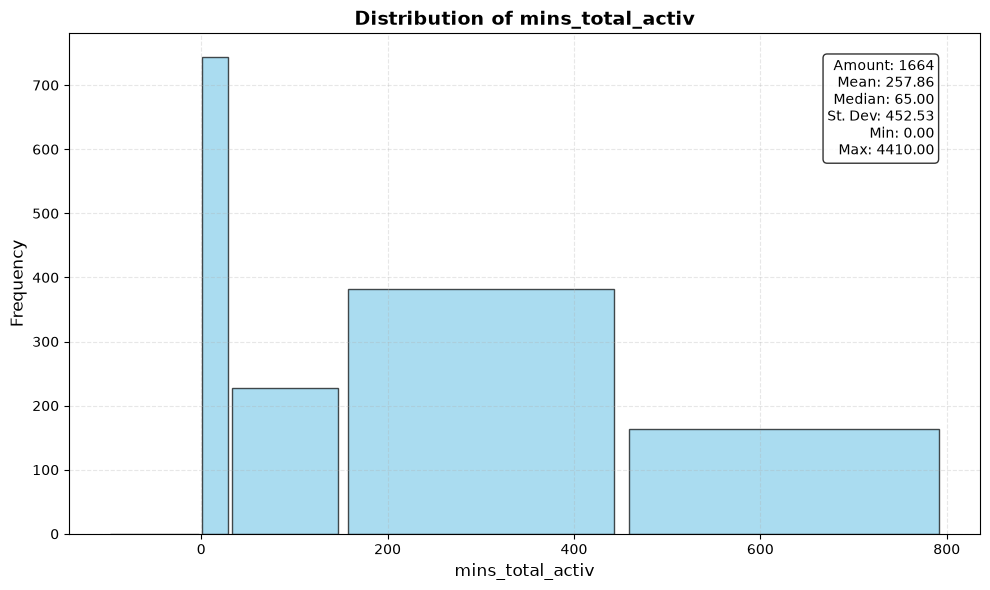

In [704]:
fig1, ax1 = plot_column_histogram(source_ds, 'mins_total_activ', bins=[-100, 0, 30, 150, 450, 800],
                                   color='skyblue', show_stats=True)
plt.show()

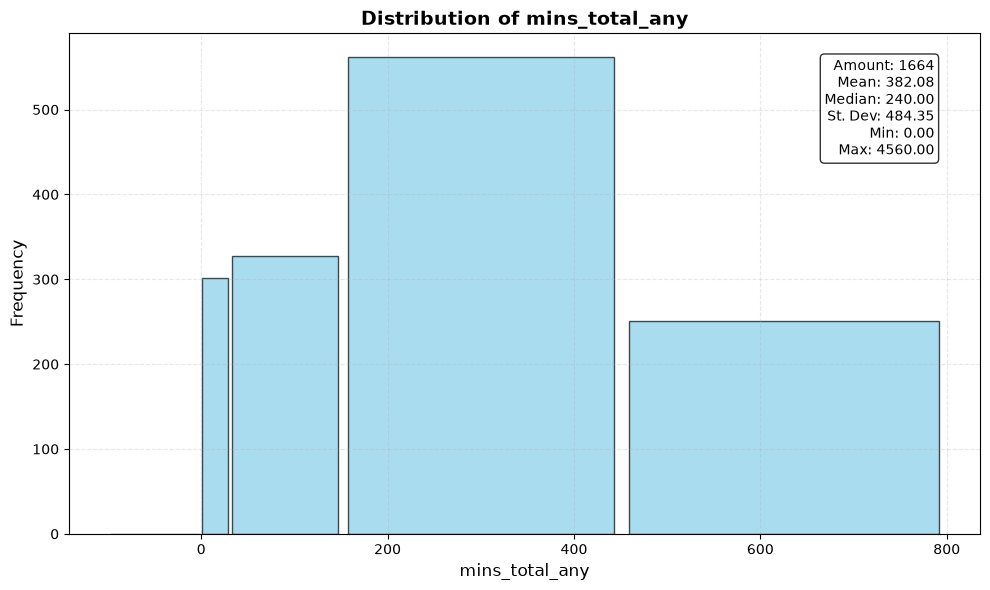

In [705]:
fig1, ax1 = plot_column_histogram(source_ds, 'mins_total_any', bins=[-100, 0, 30, 150, 450, 800],
                                   color='skyblue', show_stats=True)
plt.show()

# source_ds['mins_total_any'].hist()

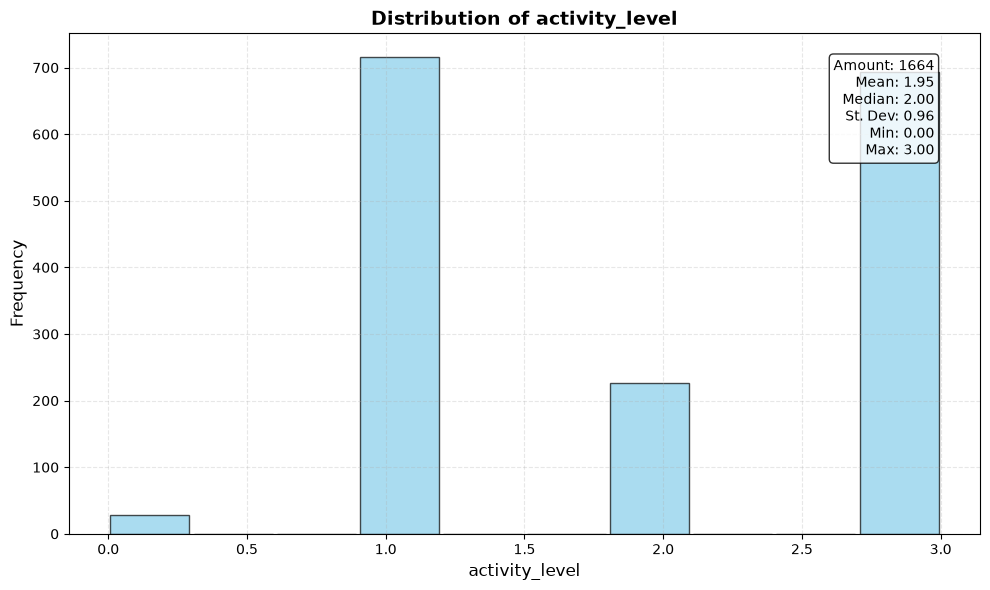

In [706]:
fig1, ax1 = plot_column_histogram(source_ds, 'activity_level',
                                   color='skyblue', show_stats=True)
plt.show()

In [707]:
if raw_target in ['mins_total_activ', 'mins_total_any']:
  target_intervals = [-1,29.999,149.999,1000000000]
  # target_intervals = [-1,29.299,849.999,1000000000]
  # target_labels = ['Inactive','Fairly Active','Active']
  target_labels = [1,2,3]
  # target_labels = None
  source_ds = create_categorical_from_bins(source_ds, raw_target, target_col_name, target_intervals, labels=target_labels)
  model_fields_cols += [target_col_name]
else:
  target_col_name = raw_target

target_col_name

'activity_level'

In [708]:
source_ds[target_col_name].value_counts()

activity_level
1.0    716
3.0    693
2.0    227
0.0     28
Name: count, dtype: int64

In [709]:
source_ds = convert_column_types(source_ds, [target_col_name], int)

In [710]:
source_ds = source_ds[source_ds[target_col_name] > 0]
source_ds

,id.case,responsemode,mergeid,q1,q1a,q1b,q1bb,q1b_dk,q1c,q2,...,broad_area_name_Whipton,broad_area_name_Mincinglake,broad_area_name_Beacon Heath,broad_area_name_St David's,broad_area_name_City Centre,broad_area_name_Exwick,broad_area_name_Redhills,broad_area_name_Newtown,broad_area_name_Countess Wear,broad_area_name_dk
0,00486f03-815d-4831-8d2b-a0ce1af11788,3.0,60785.0,2.0,0,0.0,0.0,0,0,2.0,...,0,1,0,0,0,0,0,0,0,0
1,0065efaf-f27a-4122-b536-abf0b1ea0913,1.0,9618.0,1.0,2,0.0,40.0,0,1,2.0,...,0,0,0,0,0,0,0,0,0,0
2,0067f207-733c-4fa8-8672-c1a0d121293b,2.0,8321.0,1.0,3,0.0,30.0,0,1,2.0,...,0,0,0,0,0,0,0,0,0,0
3,00a1b94f-760c-444b-8e1f-b2fa44874874,2.0,8582.0,2.0,0,0.0,0.0,0,0,0.0,...,0,0,0,0,0,0,0,0,0,0
4,00a20603-1d79-4b04-8d58-9f896fb4f3af,1.0,7838.0,1.0,5,0.0,45.0,0,2,2.0,...,1,0,0,0,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1659,ffb8947a-31ce-4fdf-bc8f-1a29f00c110b,1.0,5791.0,1.0,4,0.0,30.0,0,1,2.0,...,0,1,0,0,0,0,0,0,0,0
1660,ffc7fc33-a65e-4bba-867e-a6a4a19c5d20,1.0,3124.0,1.0,4,1.0,0.0,0,1,2.0,...,0,0,0,1,0,0,0,0,0,0
1661,ffd16292-3a83-400a-856d-6a4e754d3da8,1.0,1919.0,1.0,7,0.0,40.0,0,2,2.0,...,0,0,0,0,1,0,0,0,0,0
1662,ffe752c8-e9aa-4a30-9ab9-c916d55be57d,1.0,2804.0,1.0,5,0.0,20.0,0,2,2.0,...,0,0,0,1,0,0,0,0,0,0


In [711]:
def norm_y(yy):
  if is_binary_class: return (yy-1) // 2
  return yy-1

'''Disabled target-label conversion example.'''

source_ds[target_col_name] = source_ds[target_col_name].apply(norm_y)

C:\Users\Raiet\AppData\Local\Temp\ipykernel_13520\3642218824.py:7: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  source_ds[target_col_name] = source_ds[target_col_name].apply(norm_y)


In [712]:
source_ds[target_col_name].value_counts()

activity_level
0    716
2    693
1    227
Name: count, dtype: int64

In [713]:
source_ds_cleaned = source_ds
source_ds = pd.DataFrame(source_ds_cleaned)

In [714]:
raw_model_fields_cols = model_fields_cols

In [715]:
for col in ['q10', 'q11']:
  display(source_ds_cleaned[col].value_counts())

q10
1.0    945
2.0    675
5.0     11
3.0      3
4.0      2
Name: count, dtype: int64

q11
0     46
68    43
70    37
34    36
63    35
      ..
90     2
94     2
95     1
97     1
91     1
Name: count, Length: 82, dtype: int64

# Filter by conditions

In [716]:
DO_FILTER = False
HOW_FILTER = 'and' # and / or / xor

conditions = {
    'ns_sec_summ': 3.0,
    # 'salary': '> 50000'
}

In [717]:
# BEST conditions

In [718]:
import pandas as pd
import numpy as np

def filter_dataframe(df, conditions, how='and', verbose=True):
    """Create a boolean mask for one filtering condition."""

    df_copy = df.copy()
    original_len = len(df_copy)
    mask = pd.Series(True, index=df_copy.index)


    if isinstance(conditions, dict):
        conditions = [conditions]


    condition_masks = []

    for cond_dict in conditions:
        for col, condition in cond_dict.items():
            if col not in df_copy.columns:
                if verbose:
                    print(f" Field '{col}' not found. Skipping condition.")
                continue


            col_mask = _create_condition_mask(df_copy[col], condition)
            condition_masks.append(col_mask)


    if how == 'and':
        final_mask = pd.Series(True, index=df_copy.index)
        for mask in condition_masks:
            final_mask = final_mask & mask
    elif how == 'or':
        final_mask = pd.Series(False, index=df_copy.index)
        for mask in condition_masks:
            final_mask = final_mask | mask
    elif how == 'xor':

        final_mask = pd.Series(0, index=df_copy.index)
        for mask in condition_masks:
            final_mask = final_mask + mask.astype(int)
        final_mask = final_mask == 1
    else:
        raise ValueError(f"Unknown parameter 'how': {how}. Available options: 'and', 'or', 'xor'")


    result = df_copy[final_mask]
    filtered_len = len(result)

    if verbose:
        print(f"\n=== Filtered data ===")
        print(f"  Original number of records: {original_len}")
        print(f"  Filtered records: {filtered_len}")
        print(f"  Records removed: {original_len - filtered_len}")
        print(f"  Type of condition combination: {how}")
        print(f"  Number of applied conditions: {len(condition_masks)}")

    return result


def _create_condition_mask(series, condition):
    """Filter a DataFrame using conditions applied to its columns."""

    if callable(condition):
        return series.apply(condition)


    if isinstance(condition, tuple) and len(condition) == 2:
        min_val, max_val = condition
        return (series >= min_val) & (series <= max_val)


    if isinstance(condition, dict):
        mask = pd.Series(True, index=series.index)
        if 'min' in condition:
            mask = mask & (series >= condition['min'])
        if 'max' in condition:
            mask = mask & (series <= condition['max'])
        if 'in' in condition:
            mask = mask & (series.isin(condition['in']))
        if 'not_in' in condition:
            mask = mask & (~series.isin(condition['not_in']))
        if 'like' in condition:
            mask = mask & (series.str.contains(condition['like'], na=False))
        return mask


    if isinstance(condition, list):
        return series.isin(condition)


    if isinstance(condition, str):

        if condition.startswith('contains:'):
            substring = condition[9:]
            return series.str.contains(substring, na=False)
        elif condition.startswith('startswith:'):
            prefix = condition[11:]
            return series.str.startswith(prefix, na=False)
        elif condition.startswith('endswith:'):
            suffix = condition[9:]
            return series.str.endswith(suffix, na=False)
        elif condition.startswith('regex:'):
            pattern = condition[6:]
            return series.str.contains(pattern, na=False, regex=True)
        elif condition.startswith('>'):
            val = float(condition[1:].strip())
            return series > val
        elif condition.startswith('>='):
            val = float(condition[2:].strip())
            return series >= val
        elif condition.startswith('<'):
            val = float(condition[1:].strip())
            return series < val
        elif condition.startswith('<='):
            val = float(condition[2:].strip())
            return series <= val
        elif condition.startswith('!='):
            val = float(condition[2:].strip())
            return series != val
        elif condition.startswith('='):
            val = condition[1:].strip()
            return series == val


    return series == condition

In [719]:
if DO_FILTER:
  filtred_ds = filter_dataframe(source_ds_cleaned, conditions, how=HOW_FILTER)
else:
  filtred_ds = source_ds_cleaned

In [720]:
filtred_ds

,id.case,responsemode,mergeid,q1,q1a,q1b,q1bb,q1b_dk,q1c,q2,...,broad_area_name_Whipton,broad_area_name_Mincinglake,broad_area_name_Beacon Heath,broad_area_name_St David's,broad_area_name_City Centre,broad_area_name_Exwick,broad_area_name_Redhills,broad_area_name_Newtown,broad_area_name_Countess Wear,broad_area_name_dk
0,00486f03-815d-4831-8d2b-a0ce1af11788,3.0,60785.0,2.0,0,0.0,0.0,0,0,2.0,...,0,1,0,0,0,0,0,0,0,0
1,0065efaf-f27a-4122-b536-abf0b1ea0913,1.0,9618.0,1.0,2,0.0,40.0,0,1,2.0,...,0,0,0,0,0,0,0,0,0,0
2,0067f207-733c-4fa8-8672-c1a0d121293b,2.0,8321.0,1.0,3,0.0,30.0,0,1,2.0,...,0,0,0,0,0,0,0,0,0,0
3,00a1b94f-760c-444b-8e1f-b2fa44874874,2.0,8582.0,2.0,0,0.0,0.0,0,0,0.0,...,0,0,0,0,0,0,0,0,0,0
4,00a20603-1d79-4b04-8d58-9f896fb4f3af,1.0,7838.0,1.0,5,0.0,45.0,0,2,2.0,...,1,0,0,0,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1659,ffb8947a-31ce-4fdf-bc8f-1a29f00c110b,1.0,5791.0,1.0,4,0.0,30.0,0,1,2.0,...,0,1,0,0,0,0,0,0,0,0
1660,ffc7fc33-a65e-4bba-867e-a6a4a19c5d20,1.0,3124.0,1.0,4,1.0,0.0,0,1,2.0,...,0,0,0,1,0,0,0,0,0,0
1661,ffd16292-3a83-400a-856d-6a4e754d3da8,1.0,1919.0,1.0,7,0.0,40.0,0,2,2.0,...,0,0,0,0,1,0,0,0,0,0
1662,ffe752c8-e9aa-4a30-9ab9-c916d55be57d,1.0,2804.0,1.0,5,0.0,20.0,0,2,2.0,...,0,0,0,1,0,0,0,0,0,0


In [721]:
filtred_ds['ns_sec_summ'].value_counts()

ns_sec_summ
2.0    553
1.0    546
3.0    405
5.0    101
4.0     31
Name: count, dtype: int64

# Select variables by correlation

In [722]:
min_cor_val = 0.2 # 0.3
max_cor_val = 0.8 # 0.9

In [723]:
req_model_fields_cols = [
    'q11',
    'q10_1.0',
    # 'q10_2.0',
    'q4', 'q5', 'q9',
]

In [724]:
model_fields_cols = list(raw_model_fields_cols)

In [725]:
import pandas as pd
import numpy as np

def find_features_by_correlation(df, target_column, corr_range, method='pearson',
                                  include_target=False, min_samples=10,
                                  drop_na=True, verbose=True):
    """Classify correlation strength from its absolute value."""


    if target_column not in df.columns:
        raise ValueError(f"Column '{target_column}' not found in the dataset")


    if len(corr_range) != 2:
        raise ValueError("corr_range must be a tuple (min, max)")

    corr_min, corr_max = corr_range
    if corr_min > corr_max:
        raise ValueError("min must be less than or equal to max")


    if verbose:
        print(f"Searching for columns with correlation in the range [{corr_min:.3f}, {corr_max:.3f}]")
        print(f"Method: {method}")
        print(f"Target column: {target_column}")
        print("-" * 60)


    if drop_na:

        df_clean = df[df[target_column].notna()].copy()
    else:
        df_clean = df.copy()


    numeric_cols = df_clean.select_dtypes(include=[np.number]).columns.tolist()


    if target_column not in numeric_cols:

        try:
            df_clean[target_column] = pd.to_numeric(df_clean[target_column], errors='coerce')
            numeric_cols = df_clean.select_dtypes(include=[np.number]).columns.tolist()
        except:
            raise ValueError(f"Target column '{target_column}' must be numeric")


    cols_to_check = [col for col in numeric_cols if col != target_column]

    if len(cols_to_check) == 0:
        print("No numeric columns to check")
        return pd.DataFrame()

    if verbose:
        print(f"Checking columns: {len(cols_to_check)}")
        print(f"Total numeric columns in the dataset: {len(numeric_cols)}")
        print("-" * 60)


    results = []

    for col in cols_to_check:

        valid_mask = df_clean[col].notna() & df_clean[target_column].notna()
        n_valid = valid_mask.sum()

        if n_valid < min_samples:
            if verbose:
                print(f"  {col}: not enough data ({n_valid} < {min_samples})")
            continue


        try:
            corr_val = df_clean.loc[valid_mask, [col, target_column]].corr(
                method=method
            ).iloc[0, 1]


            if np.isnan(corr_val):
                continue


            if corr_min <= corr_val <= corr_max:
                results.append({
                    'feature': col,
                    'correlation': corr_val,
                    'abs_correlation': abs(corr_val),
                    'n_samples': n_valid,
                    'correlation_type': 'positive' if corr_val > 0 else 'negative',
                    'strength': _correlation_strength(abs(corr_val))
                })
        except Exception as e:
            if verbose:
                print(f"Error calculating correlation for {col}: {e}")
            continue


    result_df = pd.DataFrame(results)

    if include_target:

        target_row = pd.DataFrame([{
            'feature': target_column,
            'correlation': 1.0,
            'abs_correlation': 1.0,
            'n_samples': len(df_clean),
            'correlation_type': 'positive',
            'strength': 'perfect'
        }])
        result_df = pd.concat([target_row, result_df], ignore_index=True)


    if not result_df.empty:
        result_df = result_df.sort_values('abs_correlation', ascending=False)

    if verbose:
        print(f"\nFound columns: {len(result_df)}")
        if not result_df.empty:
            print("\nTop-5 results:")
            print(result_df[['feature', 'correlation', 'abs_correlation', 'strength']].head())

    return result_df


def _correlation_strength(abs_corr):
    """Find numeric features whose correlation with the target is within a specified range."""
    if abs_corr >= 0.9:
        return 'very strong'
    elif abs_corr >= 0.7:
        return 'strong'
    elif abs_corr >= 0.5:
        return 'moderate'
    elif abs_corr >= 0.3:
        return 'weak'
    else:
        return 'very weak'

In [726]:
pos_corr_list = find_features_by_correlation(
    source_ds,
    target_column=target_col_name,
    corr_range=(min_cor_val, max_cor_val),
    method='pearson',
    verbose=True
)

pos_corr_list

Searching for columns with correlation in the range [0.200, 0.800]
Method: pearson
Target column: activity_level
------------------------------------------------------------
Checking columns: 262
Total numeric columns in the dataset: 263
------------------------------------------------------------

Found columns: 23

Top-5 results:
             feature  correlation  abs_correlation  strength
15    mins_any_bkdwn     0.607684         0.607684  moderate
16  mins_total_activ     0.600886         0.600886  moderate
21                q4     0.475234         0.475234      weak
17    mins_total_any     0.440122         0.440122      weak
4                q3a     0.438201         0.438201      weak


,feature,correlation,abs_correlation,n_samples,correlation_type,strength
15,mins_any_bkdwn,0.607684,0.607684,1636,positive,moderate
16,mins_total_activ,0.600886,0.600886,1636,positive,moderate
21,q4,0.475234,0.475234,1636,positive,weak
17,mins_total_any,0.440122,0.440122,1636,positive,weak
4,q3a,0.438201,0.438201,1636,positive,weak
11,q4d,0.437550,0.437550,1636,positive,weak
1,q1a,0.434752,0.434752,1636,positive,weak
10,q4c,0.430733,0.430733,1636,positive,weak
9,q4b,0.418347,0.418347,1636,positive,weak
8,q4a,0.395040,0.395040,1636,positive,weak


In [727]:
neg_corr_list = find_features_by_correlation(
    source_ds,
    target_column=target_col_name,
    corr_range=(-max_cor_val, -min_cor_val),
    method='pearson',
    verbose=True
)

neg_corr_list

Searching for columns with correlation in the range [-0.800, -0.200]
Method: pearson
Target column: activity_level
------------------------------------------------------------
Checking columns: 262
Total numeric columns in the dataset: 263
------------------------------------------------------------

Found columns: 17

Top-5 results:
           feature  correlation  abs_correlation  strength
7     walk10minsbr    -0.675557         0.675557  moderate
9   sports10minsbr    -0.499680         0.499680      weak
12   dayssport_rbr    -0.480657         0.480657      weak
2               q3    -0.409182         0.409182      weak
0               q1    -0.383102         0.383102      weak


,feature,correlation,abs_correlation,n_samples,correlation_type,strength
7,walk10minsbr,-0.675557,0.675557,1636,negative,moderate
9,sports10minsbr,-0.499680,0.499680,1636,negative,weak
12,dayssport_rbr,-0.480657,0.480657,1636,negative,weak
2,q3,-0.409182,0.409182,1636,negative,weak
0,q1,-0.383102,0.383102,1636,negative,weak
13,q1a_dk,-0.383102,0.383102,1636,negative,weak
10,dayswalk_rbr,-0.376933,0.376933,1636,negative,weak
8,cycle10minsbr,-0.315635,0.315635,1636,negative,weak
11,dayscycle_rbr,-0.275736,0.275736,1636,negative,very weak
5,q20,-0.270165,0.270165,1636,negative,very weak


In [728]:
for col in ['dayswalk_rbr', 'cycle10minsbr', 'mins_activ_bkdwn']:
  print(col, col in model_fields_cols)

dayswalk_rbr False
cycle10minsbr False
mins_activ_bkdwn False


In [729]:
corr_model_fields_cols = []

for col in pos_corr_list['feature']:
  # print(col, col in model_fields_cols)
  if col in model_fields_cols:
    corr_model_fields_cols.append(str(col))

for col in neg_corr_list['feature']:
  # print(col, col in model_fields_cols)
  if col in model_fields_cols:
    corr_model_fields_cols.append(str(col))

corr_model_fields_cols

['mins_total_activ',
 'q4',
 'mins_total_any',
 'q3a',
 'q4d',
 'q1a',
 'q4c',
 'q4b',
 'q4a',
 'q3c',
 'q3_time',
 'q1_time',
 'q2a',
 'Q8a_dk',
 'q4e',
 'q2_time',
 'q8_1',
 'q3',
 'q1',
 'q1a_dk',
 'q20',
 'q18',
 'q27_dk',
 'q28b_dk',
 'ns_sec_summ_3.0',
 'q2',
 'Q8a']

In [730]:
model_fields_cols_old = list(corr_model_fields_cols)

In [731]:
for col in req_model_fields_cols:
  if col not in model_fields_cols_old:
    model_fields_cols_old.append(col)

In [732]:
def do_correl_find(source_ds, target_col_name, raw_model_fields_cols,
                   min_cor_val, max_cor_val,
                   method='pearson', verbose=False, req_model_fields_cols=[]):
  model_fields_cols = list(raw_model_fields_cols)
  if target_col_name not in model_fields_cols:
    model_fields_cols.append(target_col_name)
  source_ds = source_ds[model_fields_cols]

  pos_corr_list = find_features_by_correlation(
    source_ds,
    target_column=target_col_name,
    corr_range=(min_cor_val, max_cor_val),
    method=method,
    verbose=verbose
  )
  display(pos_corr_list)

  neg_corr_list = find_features_by_correlation(
    source_ds,
    target_column=target_col_name,
    corr_range=(-max_cor_val, -min_cor_val),
    method=method,
    verbose=verbose
  )
  display(neg_corr_list)

  corr_model_fields_cols = []

  if not pos_corr_list.empty:
    for col in pos_corr_list['feature']:
      if col in model_fields_cols:
        corr_model_fields_cols.append(str(col))

  if not neg_corr_list.empty:
    for col in neg_corr_list['feature']:
      if col in model_fields_cols:
        corr_model_fields_cols.append(str(col))

  for col in req_model_fields_cols:
    if col not in corr_model_fields_cols:
      corr_model_fields_cols.append(col)

  return corr_model_fields_cols

In [733]:
# Keep all candidate fields until after the train/test split.  Correlation-based
# screening is outcome-based and must be learned from training rows only.
model_fields_cols = list(raw_model_fields_cols)
model_fields_cols

['q1',
 'q1a',
 'q1a_dk',
 'q1b_dk',
 'q1_time',
 'q1c',
 'q1_dk',
 'q2',
 'q2a',
 'q2b_dk',
 'q2_time',
 'q2c',
 'q2_dk',
 'q3',
 'q3a',
 'q3b_dk',
 'q3_time',
 'q3c',
 'q3_dk',
 'q4',
 'q4a',
 'q4a_dk',
 'q4b',
 'q4b_dk',
 'q4c',
 'q4c_dk',
 'q4d',
 'q4d_dk',
 'q4e',
 'q4e_dk',
 'q5',
 'q5a',
 'q5b',
 'q5c',
 'q5d',
 'q6',
 'q6_dk',
 'q7',
 'q7_dk',
 'q8_1',
 'q8_2',
 'q8_3',
 'q8_4',
 'q8_5',
 'q8_6',
 'q8_7',
 'q8_8',
 'q8_9',
 'Q8a',
 'Q8a_dk',
 'q9',
 'q9a',
 'q9b',
 'q9c',
 'q9d',
 'q9e',
 'q9f',
 'q9g',
 'q9h',
 'q9i',
 'q9j',
 'q9k',
 'q9l',
 'q9m',
 'q9n',
 'q9o',
 'q9p',
 'q10_1.0',
 'q10_2.0',
 'q10_3.0',
 'q10_4.0',
 'q10_dk',
 'q10b',
 'q11',
 'q11a',
 'q12_1.0',
 'q12_2.0',
 'q12_3.0',
 'q12_4.0',
 'q12_5.0',
 'q12_6.0',
 'q12_7.0',
 'q12_dk',
 'q13ap',
 'q13ap_dk',
 'q13a2',
 'q13a3',
 'q13_sum',
 'q14bp',
 'q14bp_dk',
 'q14b',
 'q14b2',
 'q14b3',
 'q14_sum',
 'q13_q14_sum',
 'q15_hhold_1',
 'q15_hhold_2',
 'q15_hhold_3',
 'q15_hhold_4',
 'q15_hhold_5',
 'q15_hhold_6',


In [734]:
model_fields_cols_old

['mins_total_activ',
 'q4',
 'mins_total_any',
 'q3a',
 'q4d',
 'q1a',
 'q4c',
 'q4b',
 'q4a',
 'q3c',
 'q3_time',
 'q1_time',
 'q2a',
 'Q8a_dk',
 'q4e',
 'q2_time',
 'q8_1',
 'q3',
 'q1',
 'q1a_dk',
 'q20',
 'q18',
 'q27_dk',
 'q28b_dk',
 'ns_sec_summ_3.0',
 'q2',
 'Q8a',
 'q11',
 'q10_1.0',
 'q5',
 'q9']

In [735]:
# This historical, full-data screen is retained only as a reference.  It must not
# equal the training-only screen used below, because that would reintroduce leakage.
assert set(model_fields_cols_old).issubset(
    set(raw_model_fields_cols) | set(req_model_fields_cols)
)

# Remove unnecessary columns

In [736]:
skip_cols = [
    'q1',
    'q1_dk',
    'q1a_dk',
    'q1b_dk',
    'q1a',
    'q1c',
    'q1_time',
    'q2',
    'q2_dk',
    'q2b_dk',
    'q2a',
    'q2c',
    'q2_time',
    'q3',
    'q3_dk',
    'q3b_dk',
    'q3a',
    'q3c',
    'q3_time',
    'q4a', 'q4b', 'q4c', 'q4d', 'q4e',
    'q5a', 'q5b', 'q5c', 'q5d',
    'q9a', 'q9b', 'q9c', 'q9d', 'q9e', 'q9f', 'q9g', 'q9h', 'q9i', 'q9j', 'q9k', 'q9l', 'q9m', 'q9n', 'q9o', 'q9p',
    'q10_2.0',
]

In [737]:
def do_filter_columns(source_ds, target_col_name, model_fields_cols):

  if target_col_name not in model_fields_cols:
    model_fields_cols.append(target_col_name)

  # print(len(model_fields_cols))


  target_arr = [
      'activity_level',
      'mins_total_activ',
      'mins_total_any',
      ]

  for col in target_arr:
    if col != target_col_name and col in model_fields_cols:
      model_fields_cols.remove(col)

  # print(len(model_fields_cols))

  for col in skip_cols:
    if col in model_fields_cols:
      model_fields_cols.remove(col)
    # else:
    #   print('UNKNOWN: ', col)

  # print(len(model_fields_cols))

  source_ds = source_ds[model_fields_cols]



  # y_min = min(source_ds[target_col_name])

  # source_ds[target_col_name] = source_ds[target_col_name] - y_min

  return source_ds, model_fields_cols

In [738]:
source_ds, model_fields_cols = do_filter_columns(pd.DataFrame(filtred_ds), target_col_name, model_fields_cols)

In [739]:
for col in model_fields_cols:
  print(col)

q4
q4a_dk
q4b_dk
q4c_dk
q4d_dk
q4e_dk
q5
q6
q6_dk
q7
q7_dk
q8_1
q8_2
q8_3
q8_4
q8_5
q8_6
q8_7
q8_8
q8_9
Q8a
Q8a_dk
q9
q10_1.0
q10_3.0
q10_4.0
q10_dk
q10b
q11
q11a
q12_1.0
q12_2.0
q12_3.0
q12_4.0
q12_5.0
q12_6.0
q12_7.0
q12_dk
q13ap
q13ap_dk
q13a2
q13a3
q13_sum
q14bp
q14bp_dk
q14b
q14b2
q14b3
q14_sum
q13_q14_sum
q15_hhold_1
q15_hhold_2
q15_hhold_3
q15_hhold_4
q15_hhold_5
q15_hhold_6
q15_hhold_7
q15_hhold_8
q15_hhold_9
q15_hhold_10
q15_hhold_11
q15_hhold_12
q16
q17
q18
q18_dk
q19_1.0
q19_2.0
q19_3.0
q19_4.0
q19_5.0
q19_6.0
q19_dk
q20
q21_1.0
q21_2.0
q21_dk
q22
q23_1.0
q23_2.0
q23_3.0
q23_dk
q24_1.0
q24_2.0
q24_dk
q25_1.0
q25_2.0
q25_3.0
q25_dk
q26_1.0
q26_2.0
q26_3.0
q26_4.0
q26_5.0
q26_6.0
q26_7.0
q26_8.0
q26_dk
q27_1.0
q27_2.0
q27_3.0
q27_4.0
q27_dk
q28a_1
q28a_2
q28a_3
q28a_4
q28a_5
q28a_6
q28a_7
q28a_8
q28a_9
q28a_10
q28b_1.0
q28b_2.0
q28b_3.0
q28b_4.0
q28b_5.0
q28b_6.0
q28b_7.0
q28b_8.0
q28b_9.0
q28b_dk
q30_1
q30_2
q30_3
q30_4
q31_1
q31_2
q31_3
q31_4
q31_5
q32_1
q32_2
q32_3
q32_4
q3

In [740]:
for col in [raw_target, target_col_name, 'q1c', 'q1a_dk', 'q4b_dk', 'Q8a', 'q10_dk', 'q4d', 'q16', 'q17', 'q4', 'q5', 'q9']:
  display(source_ds_cleaned[col].value_counts())

activity_level
0    716
2    693
1    227
Name: count, dtype: int64

activity_level
0    716
2    693
1    227
Name: count, dtype: int64

q1c
1    746
2    550
0    340
Name: count, dtype: int64

q1a_dk
0    1371
1     265
Name: count, dtype: int64

q4b_dk
0    1621
1      15
Name: count, dtype: int64

Q8a
0.0    898
2.0    389
1.0    349
Name: count, dtype: int64

q10_dk
0    1625
1      11
Name: count, dtype: int64

q4d
 1.0    610
 3.0    578
 0.0    204
-1.0    153
-3.0     91
Name: count, dtype: int64

q16
2    933
1    669
0     34
Name: count, dtype: int64

q17
0    982
1    477
2    177
Name: count, dtype: int64

q4
 15.0    132
 5.0     130
 13.0    130
 3.0     124
 9.0     111
 1.0     104
 11.0    103
 4.0     100
 2.0      91
 7.0      75
-3.0      58
-1.0      56
-5.0      49
 12.0     47
 0.0      46
-15.0     42
 8.0      38
 6.0      38
-2.0      37
 10.0     27
-7.0      25
-4.0      21
-8.0      11
-11.0     10
-6.0       9
-12.0      9
-9.0       7
-13.0      4
-10.0      2
Name: count, dtype: int64

q5
 26.0    105
 22.0    103
 23.0     88
 19.0     86
 32.0     85
 20.0     81
 25.0     81
 17.0     75
 18.0     73
 24.0     69
 16.0     63
 21.0     61
 15.0     58
 29.0     55
 14.0     54
 28.0     49
 27.0     45
 12.0     43
 13.0     41
 30.0     40
 10.0     40
 11.0     32
 8.0      31
 9.0      23
 5.0      22
 31.0     22
 7.0      21
 6.0      17
 3.0      14
 2.0      10
 0.0      10
-1.0       9
 4.0       6
 1.0       4
-2.0       4
-3.0       4
-6.0       3
-5.0       2
-4.0       2
-11.0      2
-8.0       2
-7.0       1
Name: count, dtype: int64

q9
32.0    145
34.0     81
36.0     71
35.0     69
28.0     67
       ... 
77.0      1
11.0      1
62.0      1
7.0       1
6.0       1
Name: count, Length: 63, dtype: int64

In [741]:
source_ds

,q4,q4a_dk,q4b_dk,q4c_dk,q4d_dk,q4e_dk,q5,q6,q6_dk,q7,...,broad_area_name_Whipton,broad_area_name_Mincinglake,broad_area_name_Beacon Heath,broad_area_name_St David's,broad_area_name_City Centre,broad_area_name_Exwick,broad_area_name_Redhills,broad_area_name_Newtown,broad_area_name_Countess Wear,broad_area_name_dk
0,5.0,0,0,0,0,0,24.0,2.0,0,2.0,...,0,1,0,0,0,0,0,0,0,0
1,15.0,0,0,0,0,0,28.0,2.0,0,2.0,...,0,0,0,0,0,0,0,0,0,0
2,9.0,0,0,0,0,0,18.0,1.0,0,3.0,...,0,0,0,0,0,0,0,0,0,0
3,4.0,0,0,0,0,0,16.0,2.0,0,4.0,...,0,0,0,0,0,0,0,0,0,0
4,5.0,0,0,0,0,0,8.0,5.0,0,3.0,...,1,0,0,0,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1659,3.0,0,0,0,0,0,21.0,2.0,0,3.0,...,0,1,0,0,0,0,0,0,0,0
1660,8.0,0,0,0,0,0,21.0,1.0,0,3.0,...,0,0,0,1,0,0,0,0,0,0
1661,11.0,0,0,0,0,0,21.0,2.0,0,3.0,...,0,0,0,0,1,0,0,0,0,0
1662,-7.0,0,0,0,0,0,26.0,2.0,0,3.0,...,0,0,0,1,0,0,0,0,0,0


In [742]:
model_fields_cols

['q4',
 'q4a_dk',
 'q4b_dk',
 'q4c_dk',
 'q4d_dk',
 'q4e_dk',
 'q5',
 'q6',
 'q6_dk',
 'q7',
 'q7_dk',
 'q8_1',
 'q8_2',
 'q8_3',
 'q8_4',
 'q8_5',
 'q8_6',
 'q8_7',
 'q8_8',
 'q8_9',
 'Q8a',
 'Q8a_dk',
 'q9',
 'q10_1.0',
 'q10_3.0',
 'q10_4.0',
 'q10_dk',
 'q10b',
 'q11',
 'q11a',
 'q12_1.0',
 'q12_2.0',
 'q12_3.0',
 'q12_4.0',
 'q12_5.0',
 'q12_6.0',
 'q12_7.0',
 'q12_dk',
 'q13ap',
 'q13ap_dk',
 'q13a2',
 'q13a3',
 'q13_sum',
 'q14bp',
 'q14bp_dk',
 'q14b',
 'q14b2',
 'q14b3',
 'q14_sum',
 'q13_q14_sum',
 'q15_hhold_1',
 'q15_hhold_2',
 'q15_hhold_3',
 'q15_hhold_4',
 'q15_hhold_5',
 'q15_hhold_6',
 'q15_hhold_7',
 'q15_hhold_8',
 'q15_hhold_9',
 'q15_hhold_10',
 'q15_hhold_11',
 'q15_hhold_12',
 'q16',
 'q17',
 'q18',
 'q18_dk',
 'q19_1.0',
 'q19_2.0',
 'q19_3.0',
 'q19_4.0',
 'q19_5.0',
 'q19_6.0',
 'q19_dk',
 'q20',
 'q21_1.0',
 'q21_2.0',
 'q21_dk',
 'q22',
 'q23_1.0',
 'q23_2.0',
 'q23_3.0',
 'q23_dk',
 'q24_1.0',
 'q24_2.0',
 'q24_dk',
 'q25_1.0',
 'q25_2.0',
 'q25_3.0',
 'q25

In [743]:
def optimized_type_summary(df, show_memory=True):
    """Display an optimised data-type summary for a large DataFrame."""

    dtypes = df.dtypes


    type_counts = dtypes.value_counts()


    summary = pd.DataFrame({
        'Column': df.columns,
        'Type': dtypes.values,
        # 'Memory (MB)': df.memory_usage(deep=True) / 1024 / 1024
    })


    # summary = summary.sort_values('Memory (MB)', ascending=False)

    print("=" * 70)
    print("DATA TYPE SUMMARY")
    print("=" * 70)
    print(f"Total columns: {len(df.columns)}")
    print(f"Total rows: {len(df)}")
    print(f"Total size: {df.memory_usage(deep=True).sum() / 1024 / 1024:.2f} MB")
    print("-" * 70)
    print("Distribution by Types:")
    for dtype, count in type_counts.items():
        print(f"  {dtype}: {count} columns")
    print("-" * 70)

    if show_memory:
        print("COLUMNS BY MEMORY SIZE (TOP 5):")
        print(summary.head(5).to_string(index=False))

    print("=" * 70)

    return summary

In [744]:
summary = optimized_type_summary(source_ds)
# summary

DATA TYPE SUMMARY
Total columns: 180
Total rows: 1636
Total size: 2.26 MB
----------------------------------------------------------------------
Distribution by Types:
  int64: 171 columns
  float64: 9 columns
----------------------------------------------------------------------
COLUMNS BY MEMORY SIZE (TOP 5):
Column    Type
    q4 float64
q4a_dk   int64
q4b_dk   int64
q4c_dk   int64
q4d_dk   int64


In [745]:
print(source_ds.select_dtypes(include=['object']).dtypes)

Series([], dtype: object)


In [746]:
print(source_ds.select_dtypes(include=['float']).dtypes)

q4      float64
q5      float64
q6      float64
q7      float64
Q8a     float64
q9      float64
q18     float64
q33     float64
q33a    float64
dtype: object


In [747]:
tdf = source_ds.select_dtypes(include=['int'])
for col in tdf:
  print(col)

q4a_dk
q4b_dk
q4c_dk
q4d_dk
q4e_dk
q6_dk
q7_dk
q8_1
q8_2
q8_3
q8_4
q8_5
q8_6
q8_7
q8_8
q8_9
Q8a_dk
q10_1.0
q10_3.0
q10_4.0
q10_dk
q10b
q11
q11a
q12_1.0
q12_2.0
q12_3.0
q12_4.0
q12_5.0
q12_6.0
q12_7.0
q12_dk
q13ap
q13ap_dk
q13a2
q13a3
q13_sum
q14bp
q14bp_dk
q14b
q14b2
q14b3
q14_sum
q13_q14_sum
q15_hhold_1
q15_hhold_2
q15_hhold_3
q15_hhold_4
q15_hhold_5
q15_hhold_6
q15_hhold_7
q15_hhold_8
q15_hhold_9
q15_hhold_10
q15_hhold_11
q15_hhold_12
q16
q17
q18_dk
q19_1.0
q19_2.0
q19_3.0
q19_4.0
q19_5.0
q19_6.0
q19_dk
q20
q21_1.0
q21_2.0
q21_dk
q22
q23_1.0
q23_2.0
q23_3.0
q23_dk
q24_1.0
q24_2.0
q24_dk
q25_1.0
q25_2.0
q25_3.0
q25_dk
q26_1.0
q26_2.0
q26_3.0
q26_4.0
q26_5.0
q26_6.0
q26_7.0
q26_8.0
q26_dk
q27_1.0
q27_2.0
q27_3.0
q27_4.0
q27_dk
q28a_1
q28a_2
q28a_3
q28a_4
q28a_5
q28a_6
q28a_7
q28a_8
q28a_9
q28a_10
q28b_1.0
q28b_2.0
q28b_3.0
q28b_4.0
q28b_5.0
q28b_6.0
q28b_7.0
q28b_8.0
q28b_9.0
q28b_dk
q30_1
q30_2
q30_3
q30_4
q31_1
q31_2
q31_3
q31_4
q31_5
q32_1
q32_2
q32_3
q32_4
q32_5
q32_6
q32_7
q32_8
q

# Class balancing

In [748]:
DO_BALANCE = False

In [749]:
import pandas as pd
import numpy as np
from sklearn.utils import resample

def upsample_train_data(X, y, random_state=42):
    """Upsample minority classes to the size of the majority class."""

    if isinstance(X, pd.DataFrame):
        df = X.copy()
        df['target'] = y
    else:

        df = pd.DataFrame(X)
        df['target'] = y


    max_size = df['target'].value_counts().max()


    df_list = []
    for cls in df['target'].unique():
        df_cls = df[df['target'] == cls]


        if len(df_cls) < max_size:
            df_cls = df_cls.sample(max_size, replace=True, random_state=random_state)

        df_list.append(df_cls)


    df_balanced = pd.concat(df_list).reset_index(drop=True)


    if isinstance(X, pd.DataFrame):
        X_resampled = df_balanced.drop('target', axis=1)
    else:
        X_resampled = df_balanced.drop('target', axis=1).values

    y_resampled = df_balanced['target']


    shuffle_idx = np.random.RandomState(random_state).permutation(len(X_resampled))
    X_resampled = X_resampled.iloc[shuffle_idx] if isinstance(X_resampled, pd.DataFrame) else X_resampled[shuffle_idx]
    y_resampled = y_resampled.iloc[shuffle_idx] if isinstance(y_resampled, pd.Series) else y_resampled[shuffle_idx]

    return X_resampled, y_resampled

In [750]:
import pandas as pd
import numpy as np
from sklearn.utils import resample

def upsample_train_data(X, y, random_state=42):
    """Upsample minority classes to the size of the majority class."""

    if isinstance(X, pd.DataFrame):
        df = X.copy()
        df['target'] = y
    else:

        df = pd.DataFrame(X)
        df['target'] = y


    max_size = df['target'].value_counts().max()


    df_list = []
    for cls in df['target'].unique():
        df_cls = df[df['target'] == cls]


        if len(df_cls) < max_size:
            df_cls = df_cls.sample(max_size, replace=True, random_state=random_state)

        df_list.append(df_cls)


    df_balanced = pd.concat(df_list).reset_index(drop=True)


    if isinstance(X, pd.DataFrame):
        X_resampled = df_balanced.drop('target', axis=1)
    else:
        X_resampled = df_balanced.drop('target', axis=1).values

    y_resampled = df_balanced['target']


    shuffle_idx = np.random.RandomState(random_state).permutation(len(X_resampled))
    X_resampled = X_resampled.iloc[shuffle_idx] if isinstance(X_resampled, pd.DataFrame) else X_resampled[shuffle_idx]
    y_resampled = y_resampled.iloc[shuffle_idx] if isinstance(y_resampled, pd.Series) else y_resampled[shuffle_idx]

    return X_resampled, y_resampled

# Select model features

In [751]:
def do_X_y_data(source_ds, target_col_name):
  y = source_ds[target_col_name]
  X = drop_columns(source_ds, [target_col_name])

  return X, y

In [752]:
X, y = do_X_y_data(source_ds, target_col_name)

In [753]:
y.value_counts()

activity_level
0    716
2    693
1    227
Name: count, dtype: int64

In [754]:
if is_binary_class:
  class_names = {0:'Inactive',1:'Active'}
else:
  class_names = {0:'Inactive',1:'Fairly active',2:'Active'}

# Train/test split

In [755]:
def split_source(X, y):
  # Split data before any outcome-based feature screening.
  X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
  return X_train, X_test, y_train, y_test

In [756]:
def screen_features_on_training_data(X_train, X_test, y_train, target_col_name,
                                     candidate_fields, min_cor_val, max_cor_val,
                                     req_model_fields_cols):
  """Select outcome-associated features using training data, then align hold-out columns."""
  train_with_target = X_train.copy()
  train_with_target[target_col_name] = y_train
  selected_fields = do_correl_find(
      train_with_target, target_col_name, candidate_fields,
      min_cor_val=min_cor_val, max_cor_val=max_cor_val,
      req_model_fields_cols=req_model_fields_cols
  )
  selected_features = [
      col for col in selected_fields
      if col != target_col_name and col in X_train.columns
  ]
  if not selected_features:
    raise ValueError('Outcome-based screening selected no usable training features.')
  return (X_train.loc[:, selected_features].copy(),
          X_test.loc[:, selected_features].copy(),
          selected_features + [target_col_name])


In [757]:
X_train, X_test, y_train, y_test = split_source(X, y)
X_train, X_test, model_fields_cols = screen_features_on_training_data(
    X_train, X_test, y_train, target_col_name, model_fields_cols,
    min_cor_val, max_cor_val, req_model_fields_cols
)

,feature,correlation,abs_correlation,n_samples,correlation_type,strength
0,q4,0.470326,0.470326,1308,positive,weak
1,Q8a_dk,0.253670,0.253670,1308,positive,very weak
2,q9,0.208832,0.208832,1308,positive,very weak


,feature,correlation,abs_correlation,n_samples,correlation_type,strength
1,q20,-0.280118,0.280118,1308,negative,very weak
0,q18,-0.259489,0.259489,1308,negative,very weak
2,q27_dk,-0.251972,0.251972,1308,negative,very weak
3,q28b_dk,-0.220971,0.220971,1308,negative,very weak


# Train the XGBoost

In [758]:
import numpy as np
import pandas as pd
import xgboost as xgb
from sklearn.datasets import make_classification
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
from sklearn.preprocessing import LabelEncoder
import matplotlib.pyplot as plt
import seaborn as sns

In [759]:
import xgboost as xgb
from sklearn.model_selection import train_test_split, StratifiedKFold, GridSearchCV, cross_validate
import matplotlib.pylab as pl
import pandas as pd
import numpy as np
import sklearn.metrics as metrics
import matplotlib.pyplot as plt

In [760]:
def fit_XGB_bin(X_train, y_train, X_test, y_test, verbose=False):
    # --- step 1 --- GridSearch
    xgbcl = xgb.XGBClassifier(base_score=0.5, booster='gbtree', colsample_bylevel=1.0,
            gamma=0.0, max_delta_step=0.0, min_child_weight=1.0,
            n_jobs=-1, objective='binary:logistic', random_state=42, reg_alpha=0.0,
            reg_lambda=1.0, scale_pos_weight=1.0, tree_method='auto')

    # xgbcl = xgb.XGBClassifier()

    kfold = StratifiedKFold(n_splits=3, shuffle=True, random_state=42)

    param_grid = {
        'colsample_bytree':[.75,1],
        'learning_rate':[0.1,0.3,0.5],
        'max_depth':[2,3,5],
        'subsample':[.75,1],
        'n_estimators': list(range(50, 200, 50))
    }

    grid_search = GridSearchCV(estimator=xgbcl, scoring='roc_auc', param_grid=param_grid, n_jobs=-1, cv=kfold)
    grid_result = grid_search.fit(X_train, y_train, verbose=1)

    if verbose:
      print(f'Best: {grid_result.best_score_} using {grid_result.best_params_}','\n')


    # --- step 2 --- cross_validate

    #Set our final hyperparameters to the tuned values

    xgbcl = xgb.XGBClassifier(base_score=0.5, booster='gbtree', colsample_bylevel=1.0,
            gamma=0.0, max_delta_step=0.0, min_child_weight=1.0,
            n_jobs=-1, objective='binary:logistic', random_state=42, reg_alpha=0.0,
            reg_lambda=1.0, scale_pos_weight=1.0, tree_method='auto',
            colsample_bytree = grid_result.best_params_['colsample_bytree'],
            learning_rate = grid_result.best_params_['learning_rate'],
            max_depth = grid_result.best_params_['max_depth'],
            subsample = grid_result.best_params_['subsample'],
            n_estimators = grid_result.best_params_['n_estimators'])

    if verbose:
        kfold = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

        #refit the model on k-folds to get stable avg error metrics
        scores = cross_validate(estimator=xgbcl, X=X_train, y=y_train, cv=kfold, n_jobs=-1,
                                scoring=['accuracy', 'roc_auc', 'precision', 'recall', 'f1'])

        print('Training 5-fold Cross Validation Results:\n')
        print('AUC: ', scores['test_roc_auc'].mean())
        print('Accuracy: ', scores['test_accuracy'].mean())
        print('Precision: ', scores['test_precision'].mean())
        print('Recall: ', scores['test_recall'].mean())
        print('F1: ', scores['test_f1'].mean(), '\n')


    # --- step 3 --- Fit the final model
    xgbcl.fit(X_train, y_train)

    if verbose:
        print(y_train.value_counts())
        print(y_test.value_counts())

        #Generate predictions against our training and test data
        pred_train = xgbcl.predict(X_train)
        proba_train = xgbcl.predict_proba(X_train)
        pred_test = xgbcl.predict(X_test)
        proba_test = xgbcl.predict_proba(X_test)

        # Print model report
        print("Classification report (Test): \n")
        print(metrics.classification_report(y_test, pred_test))
        print("Confusion matrix (Test): \n")
        print(metrics.confusion_matrix(y_test, pred_test)/len(y_test))

        print ('\nTrain Accuracy:', metrics.accuracy_score(y_train, pred_train))
        print ('Test Accuracy:', metrics.accuracy_score(y_test, pred_test))

        print ('\nTrain AUC:', metrics.roc_auc_score(y_train, proba_train[:,1]))
        print ('Test AUC:', metrics.roc_auc_score(y_test, proba_test[:,1]))

        # calculate the fpr and tpr for all thresholds of the classification
        train_fpr, train_tpr, train_threshold = metrics.roc_curve(y_train, proba_train[:,1])
        test_fpr, test_tpr, test_threshold = metrics.roc_curve(y_test, proba_test[:,1])

        train_roc_auc = metrics.auc(train_fpr, train_tpr)
        test_roc_auc = metrics.auc(test_fpr, test_tpr)

        import matplotlib.pyplot as plt
        fig, ax = plt.subplots(figsize=[7,5])
        plt.title('Receiver Operating Characteristic')
        plt.plot(train_fpr, train_tpr, 'b', label = 'Train AUC = %0.2f' % train_roc_auc)
        plt.plot(test_fpr, test_tpr, 'g', label = 'Test AUC = %0.2f' % test_roc_auc)
        plt.legend(loc = 'lower right')
        plt.plot([0, 1], [0, 1],'r--')
        plt.xlim([0, 1])
        plt.ylim([0, 1])
        plt.ylabel('True Positive Rate')
        plt.xlabel('False Positive Rate')
        plt.show()

    return xgbcl

In [761]:
import numpy as np
import pandas as pd
from sklearn.model_selection import cross_validate
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                           f1_score, roc_auc_score, confusion_matrix,
                           classification_report, make_scorer)
import matplotlib.pyplot as plt
import seaborn as sns


def run_multiclass_cross_validation(model, X, y, cv=5, scoring_metrics=None,
                                    verbose=True, return_results=True):
    """Visualise a confusion matrix."""


    if scoring_metrics is None:
        scoring_metrics = {
            # 'mlogloss': 'mlogloss',
            'accuracy': 'accuracy',
            'precision_macro': 'precision_macro',
            'recall_macro': 'recall_macro',
            'f1_macro': 'f1_macro',
            'roc_auc_ovr': 'roc_auc_ovr'  # for multiclass classification
        }


    print("="*70)
    print("Launching cross-validation for multiclass classification...")
    print("="*70)
    print(f"Fold amount: {cv if isinstance(cv, int) else 'custom'}")
    print(f"Number of classes: {len(np.unique(y))}")
    print(f"Dataset size: {len(y)}")
    print("-"*70)


    cv_results = cross_validate(
        model, X, y,
        cv=cv,
        scoring=scoring_metrics,
        return_train_score=True,
        return_estimator=True,
        verbose=0,
        # fit_params={'sample_weight': sample_weights,
        #                                    'eval_metric': 'mlogloss'},
        # eval_metric='mlogloss'
    )


    if verbose:
        _print_cv_results(cv_results, scoring_metrics)
        _print_detailed_metrics(model, X, y, cv_results)
        _print_confusion_matrices(cv_results, X, y)

    if return_results:
        return cv_results




def _print_cv_results(cv_results, scoring_metrics):
    """Calculate and print confusion matrices."""
    print("\n" + "="*70)
    print("Results of cross-validation:")
    print("="*70)


    results_df = pd.DataFrame()

    for metric in scoring_metrics.keys():
        train_key = f'train_{metric}'
        test_key = f'test_{metric}'

        if train_key in cv_results and test_key in cv_results:
            train_scores = cv_results[train_key]
            test_scores = cv_results[test_key]

            results_df[metric] = pd.Series({
                'Train Mean': train_scores.mean(),
                'Train Std': train_scores.std(),
                'Train Min': train_scores.min(),
                'Train Max': train_scores.max(),
                'Test Mean': test_scores.mean(),
                'Test Std': test_scores.std(),
                'Test Min': test_scores.min(),
                'Test Max': test_scores.max(),
                'Test/Val diff': test_scores.mean() - train_scores.mean()
            })


    print(results_df.T.round(4))
    print("-"*70)


    if 'fit_time' in cv_results:
        print(f"\nLearning time (average): {cv_results['fit_time'].mean():.2f} seconds")
        print(f"Prediction time (average): {cv_results['score_time'].mean():.2f} seconds")


def _print_detailed_metrics(model, X, y, cv_results):
    """Calculate and print metrics for each fold."""
    print("\n" + "="*70)
    print("Detailed metrics per fold:")
    print("="*70)

    n_folds = len(cv_results['estimator'])
    class_names = [str(cls) for cls in np.unique(y)]
    n_classes = len(class_names)


    fold_metrics = []

    for fold_idx in range(n_folds):

        fold_model = cv_results['estimator'][fold_idx]






        metrics_per_fold = {
            'fold': fold_idx + 1
        }


        for metric in ['accuracy', 'precision_macro', 'recall_macro', 'f1_macro']:
            test_key = f'test_{metric}'
            if test_key in cv_results:
                metrics_per_fold[metric] = cv_results[test_key][fold_idx]

        fold_metrics.append(metrics_per_fold)


    fold_df = pd.DataFrame(fold_metrics)
    print(fold_df.round(4))


    print("\n" + "-"*70)
    print("STATISTICS FOR ALL FOLDS:")
    print(f"  Average Accuracy: {fold_df['accuracy'].mean():.4f} (+/- {fold_df['accuracy'].std():.4f})")
    if 'precision_macro' in fold_df:
        print(f"  Average Precision (macro): {fold_df['precision_macro'].mean():.4f} (+/- {fold_df['precision_macro'].std():.4f})")
    if 'recall_macro' in fold_df:
        print(f"  Average Recall (macro): {fold_df['recall_macro'].mean():.4f} (+/- {fold_df['recall_macro'].std():.4f})")
    if 'f1_macro' in fold_df:
        print(f"  Average F1 (macro): {fold_df['f1_macro'].mean():.4f} (+/- {fold_df['f1_macro'].std():.4f})")


def _print_confusion_matrices(cv_results, X, y):
    """Print core cross-validation results."""
    print("\n" + "="*70)
    print("CONFUSION MATRICES PER FOLDS")
    print("="*70)

    n_folds = len(cv_results['estimator'])
    class_names = [str(cls) for cls in np.unique(y)]


    total_cm = None

    for fold_idx in range(n_folds):


        fold_model = cv_results['estimator'][fold_idx]



        y_pred = fold_model.predict(X)

        cm = confusion_matrix(y, y_pred)
        print('fold_idx', fold_idx)
        print(cm)
        # print(metrics.confusion_matrix(y_test, pred_test)/len(y_test))

        if total_cm is None:
            total_cm = cm
        else:
            total_cm += cm


    cm_normalized = total_cm.astype('float') / total_cm.sum(axis=1)[:, np.newaxis]
    # print('cm_normalized', cm_normalized)


    print("\nTotal confusion matrix (normalized):")
    cm_df = pd.DataFrame(
        cm_normalized,
        index=[f'True {c}' for c in class_names],
        columns=[f'Pred {c}' for c in class_names]
    )
    print(cm_df.round(3))


    _plot_confusion_matrix(total_cm, class_names)


def _plot_confusion_matrix(cm, class_names, figsize=(10, 8)):
    """Run cross-validation for a multiclass model and report complete statistics."""
    plt.figure(figsize=figsize)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=class_names, yticklabels=class_names)
    plt.title('Confusion Matrix (Total across all folds)', fontsize=14)
    plt.xlabel('Predicted Classes', fontsize=12)
    plt.ylabel('True Classes', fontsize=12)
    plt.tight_layout()
    plt.show()

In [762]:
y_train.value_counts()

activity_level
0    569
2    552
1    187
Name: count, dtype: int64

In [763]:
from sklearn.utils import compute_sample_weight

sample_weights = compute_sample_weight(class_weight='balanced', y=y_train)

sample_weights

array([2.3315508 , 0.76625659, 2.3315508 , ..., 0.78985507, 0.78985507,
       0.78985507], shape=(1308,))

In [764]:
from collections import Counter
from sklearn.utils.class_weight import compute_class_weight

def fit_XGB_multy(X_train, y_train, X_test, y_test, upsample=True, verbose=False):
    # balanced_ds = upsample_minority(df, target_col_name)
    # bX, by = do_X_y_data(balanced_ds, target_col_name, is_binary_class)
    # bX_train, bX_test, by_train, by_test = split_source(bX, by)

    scoring='roc_auc_ovo'


    train_counts = Counter(y_train)
    total_train = len(y_train)


    class_weights = {cls: ( total_train / (len(train_counts) * count) )**2
                    for cls, count in train_counts.items()}
    print(class_weights)

    if upsample:
      bX_train, by_train = upsample_train_data(X_train, y_train, random_state=42)
    else:
      bX_train, by_train = X_train, y_train


    # sample_weights = compute_sample_weight(class_weight='balanced', y=y_train)

    sample_weights = np.array([class_weights[cls] for cls in by_train])

    # --- step 1 --- GridSearch
    xgbcl = xgb.XGBClassifier(learning_rate=0.5,
                      n_estimators=150,
                      max_depth=6,
                      min_child_weight=0,
                      gamma=0,
                      reg_lambda=1,
                      subsample=1,
                      colsample_bytree=0.75,
                      # scale_pos_weight=1,
                      objective='multi:softprob',
                      num_class=3,
                      random_state=42,
                      eval_metric='mlogloss',
                      # fit_params={'sample_weight': sample_weights,
                      #             'eval_metric': 'mlogloss'},
                      )

    kfold = StratifiedKFold(n_splits=3, shuffle=True, random_state=42)

    param_grid = {
        'colsample_bytree':[.75,1],
        'learning_rate':[0.1,0.3,0.5],
        'max_depth':[2,3,5],
        'subsample':[.75,1],
        'n_estimators': list(range(50, 200, 50))
    }

    grid_search = GridSearchCV(estimator=xgbcl, scoring=scoring,
                               param_grid=param_grid, n_jobs=-1, cv=kfold,
                              #  fit_params={'sample_weight': sample_weights,
                              #              'eval_metric': 'mlogloss'},
                               )
    grid_result = grid_search.fit(bX_train, by_train, verbose=1,
                                  # sample_weight=sample_weights,
                                  ) # , eval_metric='mlogloss')

    if verbose:
      print(f'Best: {grid_result.best_score_} using {grid_result.best_params_}','\n')


    # --- step 2 --- cross_validate

    #Set our final hyperparameters to the tuned values

    xgbcl = xgb.XGBClassifier(booster='gbtree', colsample_bylevel=1.0,
            gamma=0.0, max_delta_step=0.0, min_child_weight=0, num_class=3,
            n_jobs=-1, objective='multi:softprob', random_state=42, reg_alpha=0.0,
            reg_lambda=1.0,
            # scale_pos_weight=1.0,
            tree_method='auto',
            colsample_bytree = grid_result.best_params_['colsample_bytree'],
            learning_rate = grid_result.best_params_['learning_rate'],
            max_depth = grid_result.best_params_['max_depth'],
            subsample = grid_result.best_params_['subsample'],
            n_estimators = grid_result.best_params_['n_estimators'],
                              eval_metric='mlogloss',
                              # fit_params={'sample_weight': sample_weights,
                              #     'eval_metric': 'mlogloss'},
                              )

    if verbose:
        run_multiclass_cross_validation(model=xgbcl, X=bX_train, y=by_train, cv=5,
                                        scoring_metrics=None, verbose=verbose,
                                        return_results=False)

    # xgbcl = xgb.XGBClassifier(learning_rate=0.5,
    #                   n_estimators=150,
    #                   max_depth=6,
    #                   min_child_weight=0,
    #                   gamma=0,
    #                   reg_lambda=1,
    #                   subsample=1,
    #                   colsample_bytree=0.75,
    #                   scale_pos_weight=1,
    #                   objective='multi:softprob',
    #                   num_class=3,
    #                   random_state=42)

    # xgbcl = xgbcl.fit(bX_train, by_train) #, eval_metric='mlogloss')
    xgbcl = xgbcl.fit(bX_train, by_train, sample_weight=sample_weights) #, eval_metric='mlogloss')
    # xgbcl = xgbcl.fit(X_train, y_train, eval_metric='mlogloss')
    # pred = xgbcl.predict(X_test)
    # proba = xgbcl.predict_proba(X_test)

    if verbose:
        print(y_train.value_counts())
        print(y_test.value_counts())

        #Generate predictions against our training and test data
        pred_train = xgbcl.predict(X_train)
        proba_train = xgbcl.predict_proba(X_train)
        pred_test = xgbcl.predict(X_test)
        proba_test = xgbcl.predict_proba(X_test)

        # Print model report
        print("Classification report (Test): \n")
        print(metrics.classification_report(y_test, pred_test))

        cm_normalized = metrics.confusion_matrix(y_test, pred_test)/len(y_test)
        print("Confusion matrix (Test): \n")
        cm_df = pd.DataFrame(
            cm_normalized,
            index=[f'True {c}' for c in class_names],
            columns=[f'Pred {c}' for c in class_names]
        )
        print(cm_df.round(3))

        print ('\nTrain Accuracy:', metrics.accuracy_score(y_train, pred_train))
        print ('Test Accuracy:', metrics.accuracy_score(y_test, pred_test))

        # print ('\nTrain AUC:', metrics.roc_auc_score(y_train, proba_train[:,1]))
        # print ('Test AUC:', metrics.roc_auc_score(y_test, proba_test[:,1]))

        # calculate the fpr and tpr for all thresholds of the classification
        # train_fpr, train_tpr, train_threshold = metrics.roc_curve(y_train, proba_train[:,1])
        # test_fpr, test_tpr, test_threshold = metrics.roc_curve(y_test, proba_test[:,1])

        # train_roc_auc = metrics.auc(train_fpr, train_tpr)
        # test_roc_auc = metrics.auc(test_fpr, test_tpr)

        # import matplotlib.pyplot as plt
        # fig, ax = plt.subplots(figsize=[7,5])
        # plt.title('Receiver Operating Characteristic')
        # plt.plot(train_fpr, train_tpr, 'b', label = 'Train AUC = %0.2f' % train_roc_auc)
        # plt.plot(test_fpr, test_tpr, 'g', label = 'Test AUC = %0.2f' % test_roc_auc)
        # plt.legend(loc = 'lower right')
        # plt.plot([0, 1], [0, 1],'r--')
        # plt.xlim([0, 1])
        # plt.ylim([0, 1])
        # plt.ylabel('True Positive Rate')
        # plt.xlabel('False Positive Rate')
        # plt.show()

    return xgbcl

In [765]:
def fit_XGB(X_train, y_train, X_test, y_test, is_binary_class, upsample=True, verbose=False):
  if is_binary_class:
    xgbcl = fit_XGB_bin(X_train, y_train, X_test, y_test, verbose=verbose)
  else:
    xgbcl = fit_XGB_multy(X_train, y_train, X_test, y_test, upsample=upsample, verbose=verbose)
  return xgbcl

In [766]:
y_train.value_counts()

activity_level
0    569
2    552
1    187
Name: count, dtype: int64

{1: 5.436129142955189, 0: 0.5871491624994981, 2: 0.6238710354967443}


Best: 0.9128808945691064 using {'colsample_bytree': 1, 'learning_rate': 0.5, 'max_depth': 5, 'n_estimators': 150, 'subsample': 1} 

Launching cross-validation for multiclass classification...
Fold amount: 5
Number of classes: 3
Dataset size: 1707
----------------------------------------------------------------------

Results of cross-validation:
                 Train Mean  Train Std  Train Min  Train Max  Test Mean  \
accuracy                1.0        0.0        1.0        1.0     0.7932   
precision_macro         1.0        0.0        1.0        1.0     0.7916   
recall_macro            1.0        0.0        1.0        1.0     0.7931   
f1_macro                1.0        0.0        1.0        1.0     0.7898   
roc_auc_ovr             1.0        0.0        1.0        1.0     0.9219   

                 Test Std  Test Min  Test Max  Test/Val diff  
accuracy           0.0257    0.7478    0.8275        -0.2068  
precision_macro    0.0262    0.7457    0.8272        -0.2084  
recall_macro

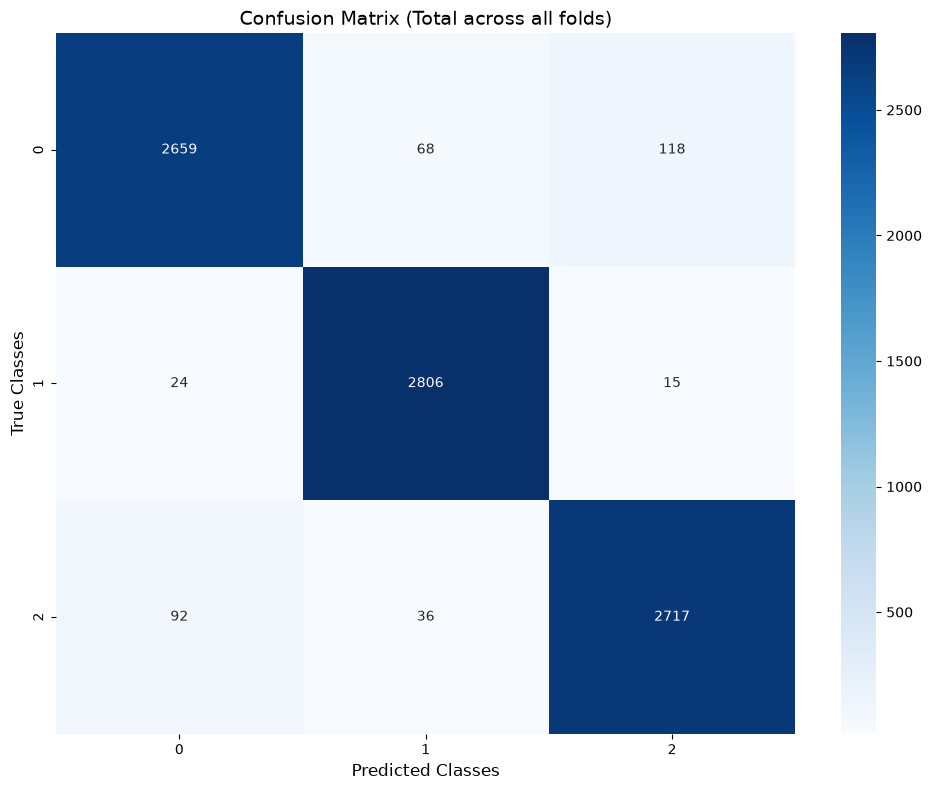

activity_level
0    569
2    552
1    187
Name: count, dtype: int64
activity_level
0    147
2    141
1     40
Name: count, dtype: int64
Classification report (Test): 

              precision    recall  f1-score   support

           0       0.62      0.61      0.62       147
           1       0.16      0.30      0.21        40
           2       0.61      0.47      0.53       141

    accuracy                           0.51       328
   macro avg       0.46      0.46      0.45       328
weighted avg       0.56      0.51      0.53       328

Confusion matrix (Test): 

        Pred 0  Pred 1  Pred 2
True 0   0.274   0.076   0.098
True 1   0.055   0.037   0.030
True 2   0.113   0.116   0.201

Train Accuracy: 0.9151376146788991
Test Accuracy: 0.5121951219512195


In [767]:
xgbcl = fit_XGB(X_train, y_train, X_test, y_test, is_binary_class, verbose=True)

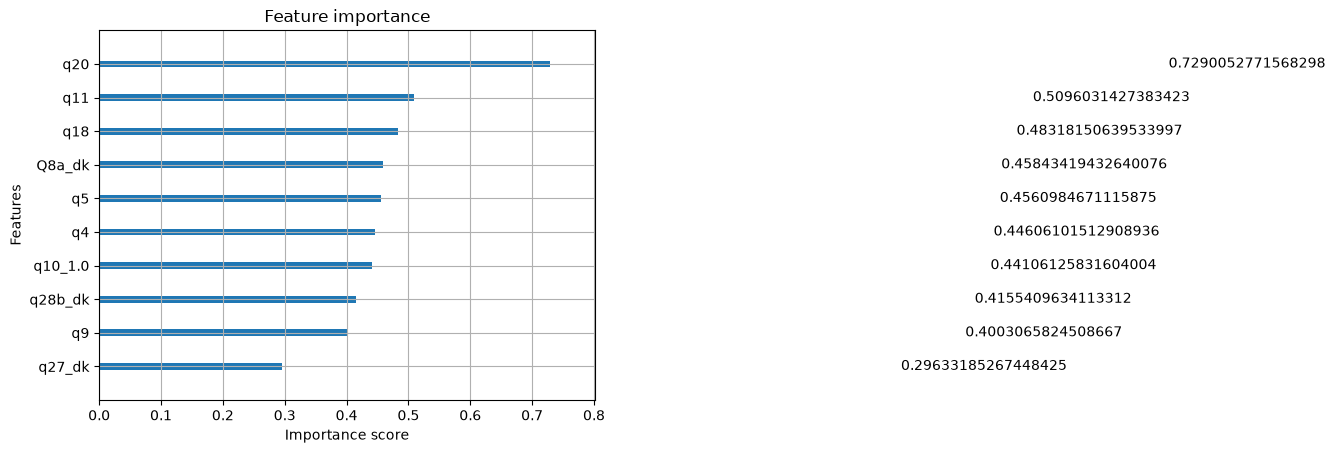

In [768]:
# plot feature importance
xgb.plot_importance(xgbcl, importance_type='gain', max_num_features=10);

In [769]:
model_name = 'XGBRegressor'
# model_name = 'XGBClassifier'

# if model_name == 'XGBRegressor':
#   model = xgb.XGBRegressor()
# elif model_name == 'XGBClassifier':
#   model = xgb.XGBClassifier()

# model.fit(X_train, y_train)

In [770]:
model = xgbcl

# Evaluate model performance

In [771]:
y_test

685     0
1616    2
1001    2
615     2
1416    0
       ..
1312    0
308     2
194     2
311     2
662     1
Name: activity_level, Length: 328, dtype: int64

In [772]:
test_ind = 4 # {0:0   327:1   1:1, 2(False) }
print(y_test.iloc[test_ind])

0


In [773]:
#take a random row of data
X_rand = X_test.iloc[[test_ind]]
rand_ind = X_rand.index[0]
print(rand_ind)
display(X_rand)

1416


,q4,Q8a_dk,q9,q20,q18,q27_dk,q28b_dk,q11,q10_1.0,q5
1416,4.0,1,38.0,0,1.0,0,0,32,1,20.0


In [774]:
#generate a prediction for the row
rand_pred = xgbcl.predict(X_rand)
rand_proba = xgbcl.predict_proba(X_rand)

print(f'Predicted Probability (no, yes): {rand_proba}')
print(f'Predicted class: {rand_pred}, {class_names[rand_pred[0]]}','\n')
print(f'Real result: {y_test.iloc[test_ind]}')

Predicted Probability (no, yes): [[0.04802112 0.67861277 0.2733661 ]]
Predicted class: [1], Fairly active 

Real result: 0


# SHAP Explanation and Visualizations

In [775]:
import shap
print(shap.__version__)

0.52.0


In [776]:
def raw_shap_to_prob_old(explainer, X_rand):
    shap_values = explainer.shap_values(X_rand)
    print(shap_values)


    base = explainer.expected_value



    if isinstance(base, list):
        base = base[1]


    probabilities = []
    for i in range(len(X_rand)):

        shap_sum = np.sum(shap_values[i])

        logit = base + shap_sum

        prob = 1 / (1 + np.exp(-logit))
        probabilities.append(prob)

    probabilities = np.array(probabilities)
    print(probabilities)

    return probabilities

In [777]:
import numpy as np
import pandas as pd
from scipy.special import expit, softmax

def raw_shap_to_prob_full(explainer, X_sample):
    """Convert raw SHAP values to approximate probability-scale contributions."""


    shap_values = explainer.shap_values(X_sample)


    base_raw = explainer.expected_value


    is_multiclass = isinstance(base_raw, (list, np.ndarray)) and len(base_raw) > 1


    if is_multiclass:

        n_samples = len(X_sample)
        n_classes = len(base_raw)


        logits = []
        for class_idx in range(n_classes):

            shap_sum = shap_values[class_idx].sum(axis=1)

            logit = base_raw[class_idx] + shap_sum
            logits.append(logit)


        logits_matrix = np.column_stack(logits)


        predicted_probs = softmax(logits_matrix, axis=1)


        shap_probs = []
        for class_idx in range(n_classes):

            shap_class = shap_values[class_idx]



            class_probs = predicted_probs[:, class_idx]


            shap_prob = shap_class * (class_probs * (1 - class_probs)).reshape(-1, 1)
            shap_probs.append(shap_prob)

        base_prob = softmax(base_raw)

        result = {
            'shap_values': shap_values,
            'shap_probabilities': shap_probs,
            'base_raw': base_raw,
            'base_prob': base_prob,
            'predicted_probabilities': predicted_probs,
            'is_multiclass': True,
            'n_classes': n_classes
        }

    else:

        if isinstance(base_raw, (list, np.ndarray)):

            base_logit = base_raw[1] if len(base_raw) == 2 else base_raw[0]
        else:
            base_logit = base_raw


        shap_sum = shap_values.sum(axis=1)
        logits = base_logit + shap_sum


        predicted_probs = expit(logits)



        shap_prob = shap_values * (predicted_probs * (1 - predicted_probs)).reshape(-1, 1)


        base_prob = expit(base_logit)

        result = {
            'shap_values': shap_values,
            'shap_probabilities': shap_prob,
            'base_raw': base_logit,
            'base_prob': base_prob,
            'predicted_probabilities': predicted_probs,
            'is_multiclass': False
        }

    return result

def raw_shap_to_prob(explainer, X_sample):
    return explainer.shap_values(X_sample)
    # return raw_shap_to_prob_full(explainer, X_sample)['shap_probabilities']

In [778]:


def example_usage():
    import xgboost as xgb
    import shap
    from sklearn.datasets import make_classification
    from sklearn.model_selection import train_test_split


    X, y = make_classification(n_samples=100, n_features=5, n_classes=2, random_state=42)
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)


    model = xgb.XGBClassifier(objective='binary:logistic', random_state=42)
    model.fit(X_train, y_train)


    explainer = shap.TreeExplainer(model, model_output='raw')


    result = raw_shap_to_prob_full(explainer, X_test)


    model_probs = model.predict_proba(X_test)[:, 1]

    print("="*60)
    print("Possibility comparison between SHAP and model predictions:")
    print("="*60)
    print(f"Predicted probabilities (from SHAP): {result['predicted_probabilities'][:5]}")
    print(f"Predicted probabilities (from model): {model_probs[:5]}")
    print(f"Maximum difference: {np.max(np.abs(result['predicted_probabilities'] - model_probs)):.6f}")

    print("\n" + "="*60)
    print("SHAP values and probabilities:")
    print("="*60)
    print(f"Shape of raw SHAP: {result['shap_values'].shape}")
    print(f"Shape of probability SHAP: {result['shap_probabilities'].shape}")
    print(f"Base value (raw): {result['base_raw']:.4f}")
    print(f"Base value (probability): {result['base_prob']:.4f}")


print("\n" + "="*60)
print("Example for binary classification")
print("="*60)
example_usage()


Example for binary classification
Possibility comparison between SHAP and model predictions:
Predicted probabilities (from SHAP): [0.003274   0.88105756 0.88105756 0.8240482  0.97016966]
Predicted probabilities (from model): [0.003274   0.8810576  0.8810576  0.8240485  0.97016966]
Maximum difference: 0.000000

SHAP values and probabilities:
Shape of raw SHAP: (30, 5)
Shape of probability SHAP: (30, 5)
Base value (raw): -0.1722
Base value (probability): 0.4571


In [779]:



def example_multiclass():
    import xgboost as xgb
    import shap
    from sklearn.datasets import make_classification
    from sklearn.model_selection import train_test_split


    X, y = make_classification(n_samples=100, n_features=5, n_classes=3, random_state=42)
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)


    model = xgb.XGBClassifier(objective='multi:softprob', num_class=3, random_state=42)
    model.fit(X_train, y_train)


    explainer = shap.TreeExplainer(model, model_output='raw')


    result = raw_shap_to_prob_full(explainer, X_test)


    model_probs = model.predict_proba(X_test)

    print("="*60)
    print("Multiclass Classification")
    print("="*60)
    print(f"Number of classes: {result['n_classes']}")
    print(f"Shape of raw SHAP: {len(result['shap_values'])} arrays")
    print(f"Shape of probability SHAP: {len(result['shap_probabilities'])} arrays")

    print(f"\nPredicted probabilities for the first object (from SHAP): {result['predicted_probabilities'][0]}")
    print(f"Predicted probabilities for the first object (from model): {model_probs[0]}")
    print(f"Maximum difference: {np.max(np.abs(result['predicted_probabilities'] - model_probs)):.6f}")

    print("\nBase values (raw):")
    for i, val in enumerate(result['base_raw']):
        print(f"  Class {i}: {val:.4f}")

    print("\nBase values (probability):")
    for i, val in enumerate(result['base_prob']):
        print(f"  Class {i}: {val:.4f}")



print("\n" + "="*60)
print("Example for multiclass classification")
print("="*60)
# example_multiclass()


Example for multiclass classification


In [780]:
# import shap
# explainer = shap.Explainer(model)
# shap_values = explainer(X_test)
# shap.initjs()

In [781]:
explainer = shap.TreeExplainer(model)
shap_values = raw_shap_to_prob(explainer, X_rand)

# display(shap.force_plot(explainer.expected_value, shap_values, X.iloc[X_rand.index]))

In [782]:
if is_binary_class:
  #Display all features and SHAP values
  display(pd.DataFrame(data=shap_values, columns=X_test.columns, index=[rand_ind]).transpose().sort_values(by=rand_ind, ascending=True))

In [783]:
shap.initjs()

In [784]:
sum(shap_values[0])

array([-1.4994426 , -0.94160557,  0.29087278], dtype=float32)

In [785]:
#Prove the sum of SHAP values and base_value sum to our prediction for class 1
# import math
# shap_sum = explainer.expected_value + shap_values.sum()
# print(explainer.expected_value, shap_values.sum(),shap_sum,rand_proba[0][1])
# assert(math.isclose(shap_sum,rand_proba[0][1],rel_tol=1e-06)) #if this was False, and error would be thrown

# Force Plot

In [786]:
shap_values[0].shape

(10, 3)

In [787]:
if is_binary_class:
    shap.force_plot(explainer.expected_value, shap_values, X_rand, matplotlib=True)
else:
    for which_class in range(0,3):
        print(class_names[which_class])
        shap.initjs()
        display(shap.force_plot(explainer.expected_value[which_class], shap_values[:,:,which_class], X_rand))

Inactive


Fairly active


Active


In [788]:
if is_binary_class:
    display(pd.DataFrame(data=shap_values, columns=X_test.columns, index=[rand_ind]).transpose().sort_values(by=rand_ind, ascending=True))
    # display(pd.DataFrame(data=shap_values, columns=X_test.columns, index=[test_ind]).transpose().sort_values(by=test_ind, ascending=True))
else:
    #Display all features and SHAP values
    df1=pd.DataFrame(data=shap_values[:,:,0], columns=X_test.columns, index=[rand_ind])
    display(df1.transpose().sort_values(by=rand_ind, ascending=True))
    df2=pd.DataFrame(data=shap_values[:,:,1], columns=X_test.columns, index=[rand_ind])
    display(df2.transpose().sort_values(by=rand_ind, ascending=True))
    df3=pd.DataFrame(data=shap_values[:,:,2], columns=X_test.columns, index=[rand_ind])
    display(df3.transpose().sort_values(by=rand_ind, ascending=True))
    df=pd.concat([df1,df2,df3])
    display(df.transpose())

,1416
q11,-0.637526
q5,-0.533403
Q8a_dk,-0.247245
q28b_dk,-0.201870
q20,-0.147276
q4,-0.124740
q27_dk,0.001005
q9,0.019740
q10_1.0,0.091670
q18,0.280202


,1416
q9,-0.964848
q18,-0.312472
q4,-0.305679
q5,-0.130657
q27_dk,0.006820
Q8a_dk,0.030928
q10_1.0,0.135631
q28b_dk,0.159477
q11,0.200644
q20,0.238551


,1416
q10_1.0,-0.486622
q4,-0.245856
q11,-0.048560
q20,-0.033530
Q8a_dk,-0.017137
q28b_dk,-0.008381
q27_dk,-0.005842
q18,-0.002702
q5,0.079652
q9,1.059850


,1416,1416,1416
q4,-0.124740,-0.305679,-0.245856
Q8a_dk,-0.247245,0.030928,-0.017137
q9,0.019740,-0.964848,1.059850
q20,-0.147276,0.238551,-0.033530
q18,0.280202,-0.312472,-0.002702
q27_dk,0.001005,0.006820,-0.005842
q28b_dk,-0.201870,0.159477,-0.008381
q11,-0.637526,0.200644,-0.048560
q10_1.0,0.091670,0.135631,-0.486622
q5,-0.533403,-0.130657,0.079652


# Waterfall Model

In [789]:
# shap_values = raw_shap_to_prob(explainer, X_test)
shap_values = explainer(X_test)

In [790]:
shap_values.shape

(328, 10, 3)

In [791]:
if is_binary_class:
    shap.waterfall_plot(shap_values[test_ind])

# Stacked Force Plot

In [792]:
if is_binary_class:
    for i in range(10):
        shap.force_plot(explainer.expected_value, shap_values[i].values, X_test.iloc[i, :], matplotlib=True)

# Summary Plot

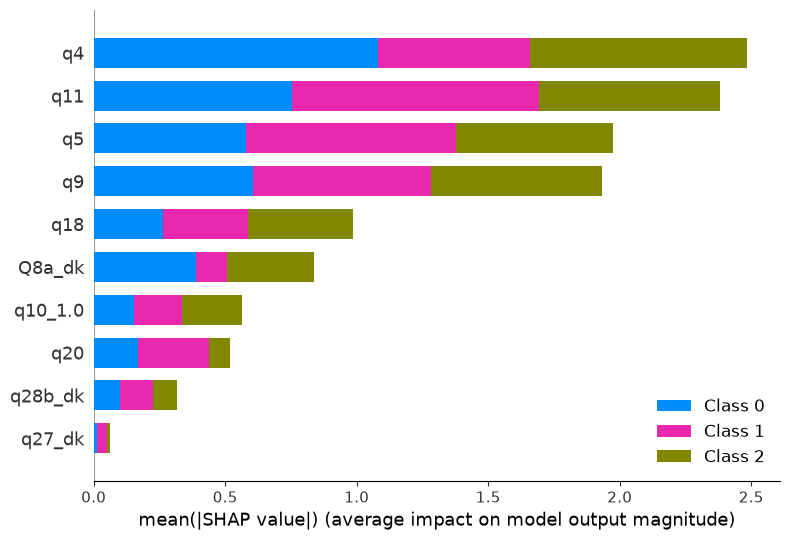

In [793]:
shap.summary_plot(shap_values, X_test)

# Bar Plot of Mean SHAP Values

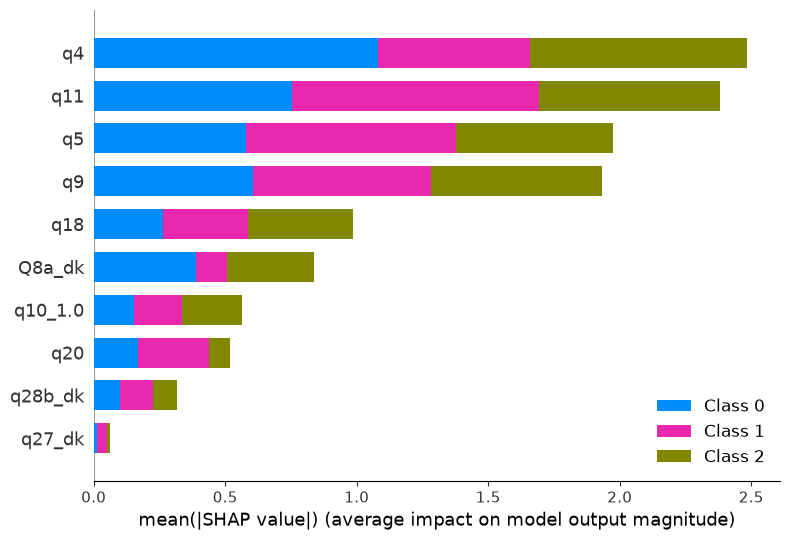

In [794]:
shap.summary_plot(shap_values, X_test, plot_type="bar")

In [795]:
import numpy as np
import pandas as pd

def get_sorted_features_by_importance(shap_values, X_test,
                                      is_multiclass=None,
                                      feature_names=None,
                                      importance_type='mean_abs',
                                      class_names=None,
                                      return_df=True):
    """Calculate feature importance for a multiclass model."""


    if feature_names is None:
        if hasattr(X_test, 'columns'):
            feature_names = X_test.columns.tolist()
        else:
            feature_names = [f'feature_{i}' for i in range(X_test.shape[1])]


    shap_array = _extract_shap_array(shap_values)


    if is_multiclass is None:
      is_multiclass = _is_multiclass_shap(shap_values)
      print('is_multiclass=', is_multiclass)

    if is_multiclass:
        n_classes = len(shap_array) if isinstance(shap_array, list) else shap_array.shape[-1]
        result = _get_multiclass_importance(shap_array, feature_names,
                                            n_classes, importance_type, class_names)
    else:
        result = _get_binary_importance(shap_array, feature_names, importance_type)

    if return_df:
        return result
    else:
        return result.to_dict(orient='list')



def _extract_shap_array(shap_values):
    """Calculate feature importance for a binary model."""
    if hasattr(shap_values, 'values'):
        # shap.Explanation
        if len(shap_values.values.shape) > 2:

            return [shap_values.values[:, :, i] for i in range(shap_values.values.shape[-1])]
        else:

            return shap_values.values
    elif isinstance(shap_values, list):

        return shap_values
    else:
        # numpy array
        return shap_values


def _is_multiclass_shap(shap_values):
    """Determine whether the model is multiclass."""
    if hasattr(shap_values, 'values'):
        return len(shap_values.values.shape) > 2
    elif isinstance(shap_values, list):
        return len(shap_values) > 1
    else:
        return False


def _get_binary_importance(shap_array, feature_names, importance_type):
    """Extract SHAP values from supported formats."""

    if hasattr(shap_array, 'values'):
        shap_array = shap_array.values
    elif len(shap_array.shape) > 2:

        shap_array = shap_array[:, :, 0] if len(shap_array.shape) == 3 else shap_array


    if importance_type == 'mean_abs':
        importance = np.abs(shap_array).mean(axis=0)
    elif importance_type == 'mean':
        importance = shap_array.mean(axis=0)
    elif importance_type == 'std':
        importance = shap_array.std(axis=0)
    elif importance_type == 'max_abs':
        importance = np.abs(shap_array).max(axis=0)
    else:
        raise ValueError(f"unknown importance type: {importance_type}")


    result = pd.DataFrame({
        'feature': feature_names,
        'importance': importance
    }).sort_values('importance', ascending=False)

    return result


def _get_multiclass_importance(shap_array, feature_names, n_classes,
                                importance_type, class_names):
    """Rank features by SHAP-based importance."""

    if isinstance(shap_array, list):
        class_arrays = shap_array
    else:
        class_arrays = [shap_array[:, :, i] for i in range(n_classes)]


    class_importances = []
    for i, class_vals in enumerate(class_arrays):
        if importance_type == 'mean_abs':
            imp = np.abs(class_vals).mean(axis=0)
        elif importance_type == 'mean':
            imp = class_vals.mean(axis=0)
        elif importance_type == 'std':
            imp = class_vals.std(axis=0)
        elif importance_type == 'max_abs':
            imp = np.abs(class_vals).max(axis=0)
        else:
            raise ValueError(f"unknown importance type: {importance_type}")
        class_importances.append(imp)


    result_df = pd.DataFrame({'feature': feature_names})


    if class_names is None:
        class_names = [f'class_{i}' for i in range(n_classes)]

    for i, imp in enumerate(class_importances):
        result_df[f'importance_{class_names[i]}'] = imp


    result_df['importance_mean'] = np.mean(class_importances, axis=0)


    result_df = result_df.sort_values('importance_mean', ascending=False)

    return result_df

In [796]:
sorted_features = get_sorted_features_by_importance(
    shap_values,
    X_test,
    importance_type='mean_abs',
    return_df=True,
    is_multiclass=(not is_binary_class),
)

sorted_features

,feature,importance_class_0,importance_class_1,importance_class_2,importance_mean
0,q4,1.081591,0.577550,0.825885,0.828342
7,q11,0.755652,0.936172,0.690656,0.794160
9,q5,0.579087,0.798698,0.595147,0.657644
2,q9,0.604239,0.678783,0.648527,0.643850
4,q18,0.263378,0.323906,0.397929,0.328404
1,Q8a_dk,0.387129,0.118799,0.332053,0.279327
8,q10_1.0,0.153772,0.183264,0.226752,0.187929
3,q20,0.167682,0.269771,0.082028,0.173160
6,q28b_dk,0.099248,0.124824,0.090809,0.104961
5,q27_dk,0.011532,0.037520,0.011616,0.020222


In [797]:
main_feature = sorted_features['feature'][0]
main_feature

'q4'

# Dependence Plot

In [798]:
shap_values = raw_shap_to_prob(explainer, X_test)

In [799]:
shap_values.shape

(328, 10, 3)

In [800]:
X_test.shape

(328, 10)

Inactive


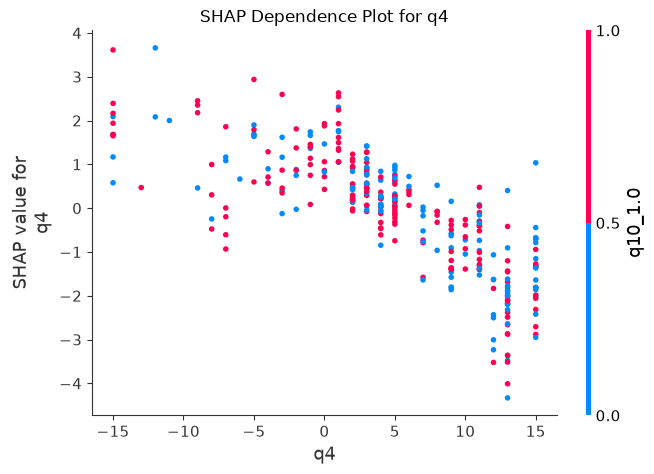

Fairly active


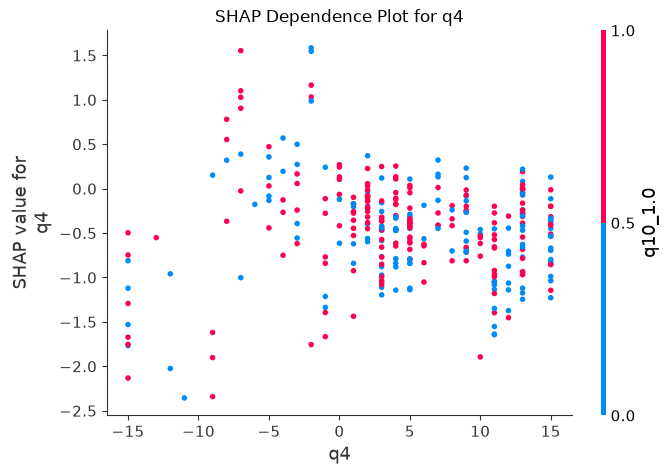

Active


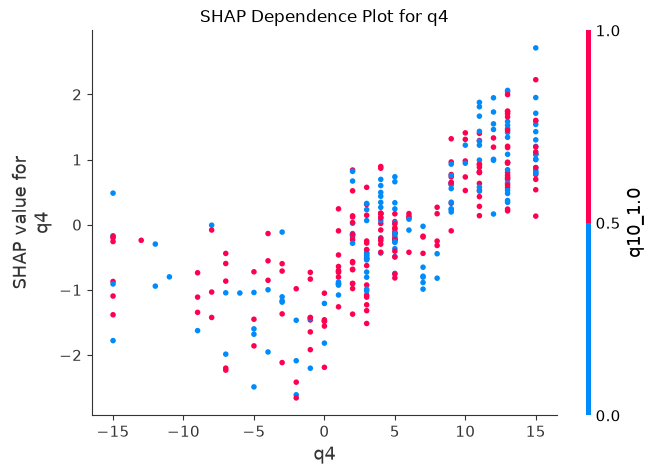

In [801]:

# feature_name = 'q1c'
# feature_name = 'q1_time'
# feature_name = 'q3_time'
# feature_name = 'q1a'



# feature_name = 'q14_sum'
# feature_name = 'q4d'
# feature_name = 'q5c'

# feature_name = 'q4'
# feature_name = 'q5'
# feature_name = 'q9'

feature_name = main_feature

# interaction_index = None
# interaction_index = 'q1c'
# interaction_index = 'q1_time'
# interaction_index = 'q3_time'
# interaction_index = 'q1a'
# interaction_index = 'q3a'
interaction_index = 'q10_1.0' # sex = female


# interaction_index = 'q14_sum'
# interaction_index = 'q4d'
# interaction_index = 'q4b'
# interaction_index = 'Q8a'

# interaction_index = 'q4'

if is_binary_class:


    shap.dependence_plot(feature_name, shap_values, X_test,
                        interaction_index=interaction_index, show=False)
    plt.title(f'SHAP Dependence Plot for {feature_name}')
    plt.show()
else:


    for which_class in range(0,3):
        print(class_names[which_class])
        shap.dependence_plot(feature_name, shap_values[:,:,which_class], X_test,
                            interaction_index=interaction_index, show=False)
        plt.title(f'SHAP Dependence Plot for {feature_name}')
        plt.show()

Inactive


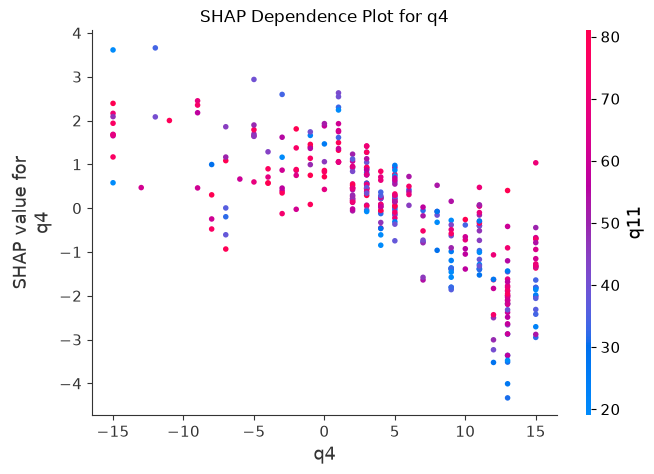

Fairly active


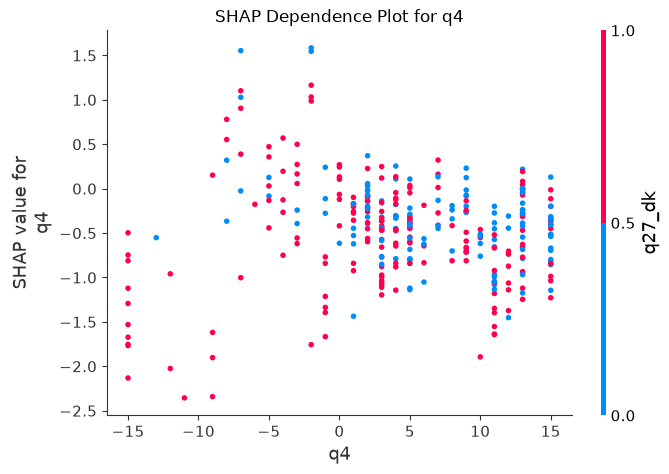

Active


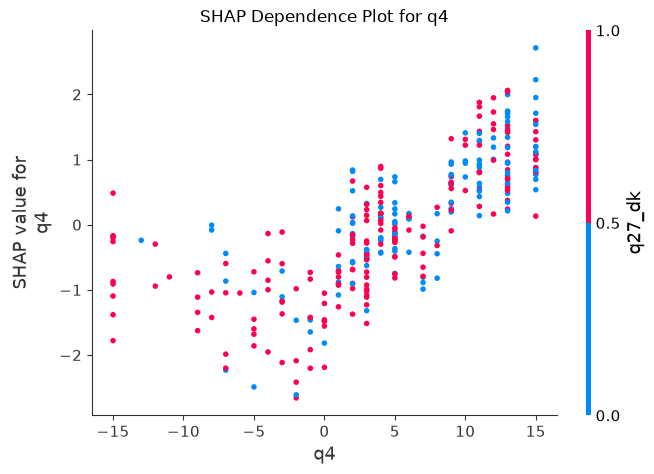

In [802]:
if is_binary_class:
    shap.dependence_plot(feature_name, shap_values, X_test, show=False)
    plt.title(f'SHAP Dependence Plot for {feature_name}')
    plt.show()
else:
    for which_class in range(0,3):
        print(class_names[which_class])
        shap.dependence_plot(feature_name, shap_values[:,:,which_class], X_test, show=False)
        plt.title(f'SHAP Dependence Plot for {feature_name}')
        plt.show()

## SHAP interpretation for inactivity

The SHAP bar chart, beeswarm plot, and dependence plots above show which features have the largest association with the model's **predicted inactivity** class. The section below turns the same values into report-ready graphics and a structured interpretation table.


,feature,mean_abs_shap,mean_shap,interpretation,intervention_hypothesis,association_direction
0,q4,1.081591,-0.086277,"Perceived ability, opportunity, enjoyment and ...","Co-design low-pressure, confidence-building ac...",Higher values tend to reduce predicted inactivity
7,q11,0.755652,0.378711,Age,"Adapt delivery, timings and communications to ...",Higher values tend to increase predicted inact...
2,q9,0.604239,0.311835,Awareness and use of local activity facilities,"Improve local awareness, wayfinding, targeted ...",Higher values tend to increase predicted inact...
9,q5,0.579087,0.269733,Personal wellbeing,Link activity offers to wellbeing and social-c...,Higher values tend to increase predicted inact...
1,Q8a_dk,0.387129,0.046106,Council-housing tenancy: missing/non-substanti...,Response-quality indicator only; do not interp...,Higher values tend to increase predicted inact...
4,q18,0.263378,0.072101,Employment status,Offer flexible sessions and targeted support f...,Higher values tend to increase predicted inact...
3,q20,0.167682,0.065160,Have you ever worked?,Review the dependence plot and subgroup result...,Higher values tend to increase predicted inact...
8,q10_1.0,0.153772,0.051941,q10_1.0,Review the dependence plot and subgroup result...,Higher values tend to increase predicted inact...
6,q28b_dk,0.099248,0.018483,q28b_dk,Review the dependence plot and subgroup result...,Higher values tend to increase predicted inact...
5,q27_dk,0.011532,0.004456,q27_dk,Review the dependence plot and subgroup result...,Higher values tend to increase predicted inact...


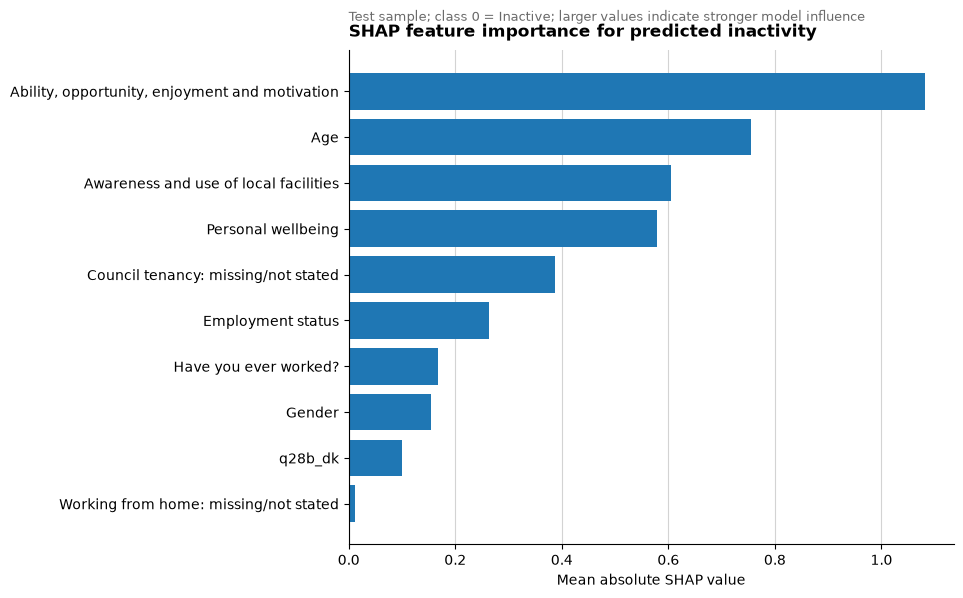

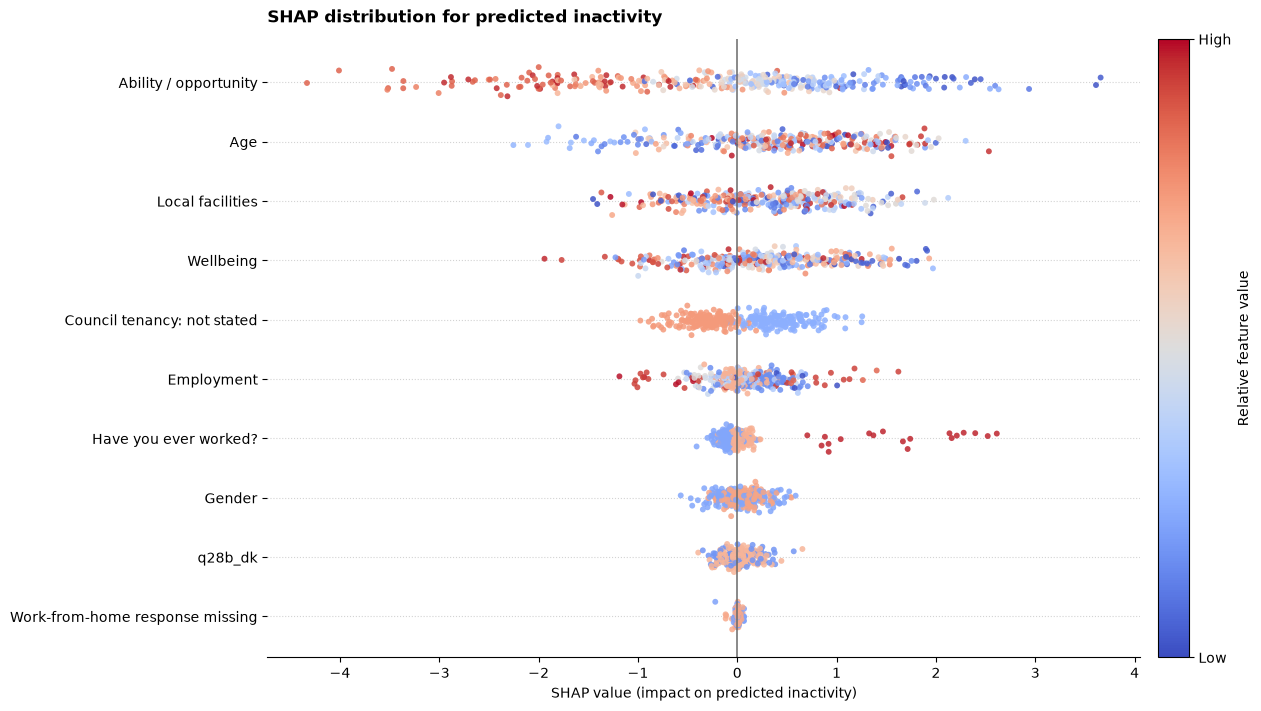

### How to use the SHAP findings
The table ranks associations in the fitted model, not causes. Prioritise features that are both highly ranked and practically actionable.
- **Perceived ability, opportunity, enjoyment and motivation**: higher values tend to reduce predicted inactivity. Intervention hypothesis: Co-design low-pressure, confidence-building activity offers; use peer support and motivational messaging.
- **Age**: higher values tend to increase predicted inactivity. Intervention hypothesis: Adapt delivery, timings and communications to age-specific needs; avoid treating age itself as a causal lever.
- **Awareness and use of local activity facilities**: higher values tend to increase predicted inactivity. Intervention hypothesis: Improve local awareness, wayfinding, targeted outreach and low-cost introductory sessions.
- **Personal wellbeing**: higher values tend to increase predicted inactivity. Intervention hypothesis: Link activity offers to wellbeing and social-connection support; consider social prescribing routes.
- **Council-housing tenancy: missing/non-substantive response**: higher values tend to increase predicted inactivity. Intervention hypothesis: Response-quality indicator only; do not interpret this as a substantive intervention driver.

In [803]:
# Report SHAP results for the inactivity class
from pathlib import Path
from textwrap import shorten
from IPython.display import Markdown, display

NON_RELEVANT_FIGURE_DIR = Path("non_relevant_figures")
NON_RELEVANT_FIGURE_DIR.mkdir(exist_ok=True)

report_explainer = shap.TreeExplainer(model)
report_shap = report_explainer(X_test)
report_shap_values = report_shap.values if hasattr(report_shap, "values") else report_shap

# The notebook encodes Inactive as class 0.
if isinstance(report_shap_values, list):
    inactivity_shap_values = report_shap_values[0]
elif report_shap_values.ndim == 3:
    inactivity_shap_values = report_shap_values[:, :, 0]
else:
    inactivity_shap_values = report_shap_values

shap_inactivity_importance = pd.DataFrame({
    "feature": X_test.columns,
    "mean_abs_shap": np.abs(inactivity_shap_values).mean(axis=0),
    "mean_shap": inactivity_shap_values.mean(axis=0),
}).sort_values("mean_abs_shap", ascending=False)

feature_context = {
    "q4": ("Perceived ability, opportunity, enjoyment and motivation", "Co-design low-pressure, confidence-building activity offers; use peer support and motivational messaging."),
    "q5": ("Personal wellbeing", "Link activity offers to wellbeing and social-connection support; consider social prescribing routes."),
    "q9": ("Awareness and use of local activity facilities", "Improve local awareness, wayfinding, targeted outreach and low-cost introductory sessions."),
    "q11": ("Age", "Adapt delivery, timings and communications to age-specific needs; avoid treating age itself as a causal lever."),
    "q18": ("Employment status", "Offer flexible sessions and targeted support for people who are retired, unemployed or long-term sick/disabled."),
    "Q8a": ("Council-housing tenancy", "Work with housing and community partners to bring activities and trusted outreach into tenant communities."),
    "Q8a_dk": ("Council-housing tenancy: missing/non-substantive response", "Response-quality indicator only; do not interpret this as a substantive intervention driver."),
    "q16": ("Long-term health condition", "Provide accessible, adapted activity pathways and clear referral options with health partners."),
    "q17": ("Condition limits daily activities", "Prioritise inclusive provision, trained instructors and support that reduces practical access barriers."),
    "ns_sec_summ": ("Socioeconomic status", "Use affordable, local, culturally relevant programmes and remove cost, transport and confidence barriers."),
}


def describe_feature(feature):
    if feature in feature_context:
        return feature_context[feature]
    if feature.startswith("q4"):
        return feature_context["q4"]
    if feature.startswith("q5"):
        return feature_context["q5"]
    if feature.startswith("q9"):
        return feature_context["q9"]
    if feature.startswith("Q8a"):
        return feature_context["Q8a"]
    if feature.startswith("ns_sec"):
        return feature_context["ns_sec_summ"]
    label = label_ds.loc[feature, "variable_label"] if feature in label_ds.index else feature
    return (label, "Review the dependence plot and subgroup results, then test tailored solutions with community members.")

shap_report_table = shap_inactivity_importance.head(12).copy()
shap_report_table[["interpretation", "intervention_hypothesis"]] = shap_report_table["feature"].apply(
    lambda feature: pd.Series(describe_feature(feature))
)
shap_report_table["association_direction"] = np.where(
    shap_report_table["mean_shap"] >= 0,
    "Higher values tend to increase predicted inactivity",
    "Higher values tend to reduce predicted inactivity",
)
display(shap_report_table)

# Short, reader-friendly labels keep the report figures legible while the table retains full wording.
plot_label_overrides = {
    "q4": "Ability, opportunity, enjoyment and motivation",
    "q5": "Personal wellbeing",
    "q9": "Awareness and use of local facilities",
    "q11": "Age",
    "q18": "Employment status",
    "Q8a": "Council-housing tenancy",
    "Q8a_dk": "Council tenancy: missing/not stated",
    "q27_dk": "Working from home: missing/not stated",
    "q10_1.0": "Gender",
    "ns_sec_summ_3.0": "Lower socioeconomic status",
}
def plot_feature_label(feature):
    label = plot_label_overrides.get(feature, describe_feature(feature)[0])
    return shorten(str(label).replace("\n", " "), width=52, placeholder="...")

# Report Figure 8: ranked SHAP importance for the inactivity class.
plot_table = shap_report_table.sort_values("mean_abs_shap").copy()
plot_table["plot_label"] = plot_table["feature"].map(plot_feature_label)
fig, ax = plt.subplots(figsize=(11, 6.5))
ax.barh(plot_table["plot_label"], plot_table["mean_abs_shap"], color="tab:blue")
ax.set_xlabel("Mean absolute SHAP value")
ax.set_title("SHAP feature importance for predicted inactivity", loc="left", pad=10, fontweight="bold")
ax.text(0, 1.06, "Test sample; class 0 = Inactive; larger values indicate stronger model influence", transform=ax.transAxes, color="dimgray", fontsize=9)
ax.spines[["top", "right"]].set_visible(False)
ax.xaxis.grid(True, color="lightgray", linewidth=0.8)
ax.set_axisbelow(True)
fig.subplots_adjust(left=0.42, right=0.97, top=0.88, bottom=0.12)
fig.savefig(NON_RELEVANT_FIGURE_DIR / "08_shap_inactivity_feature_importance.png", dpi=220, bbox_inches="tight")
plt.show()

# Report Figure 9: a layout-controlled SHAP beeswarm for the same inactivity-class values.
# Colour is each feature's within-feature percentile: blue = lower encoded value, pink = higher.
from matplotlib.colors import Normalize

beeswarm_label_overrides = {
    "q4": "Ability / opportunity",
    "q5": "Wellbeing",
    "q9": "Local facilities",
    "q11": "Age",
    "q18": "Employment",
    "Q8a": "Council tenancy",
    "Q8a_dk": "Council tenancy: not stated",
    "q27_dk": "Work-from-home response missing",
    "q10_1.0": "Gender",
    "ns_sec_summ_3.0": "Lower socioeconomic status",
    "q8_1": "Advice and support",
}
def beeswarm_label(feature):
    return beeswarm_label_overrides.get(feature, shorten(plot_feature_label(feature), width=22, placeholder="..."))

top_features = shap_inactivity_importance.head(12)["feature"].tolist()
rng = np.random.default_rng(42)
fig, ax = plt.subplots(figsize=(12.5, 7), constrained_layout=True)
for position, feature in enumerate(reversed(top_features)):
    values = pd.to_numeric(X_test[feature], errors="coerce")
    colour_values = values.rank(pct=True).fillna(0.5)
    jitter = rng.normal(0, 0.085, size=len(values))
    ax.scatter(
        inactivity_shap_values[:, X_test.columns.get_loc(feature)],
        position + jitter,
        c=colour_values,
        cmap="coolwarm",
        norm=Normalize(0, 1),
        s=18,
        alpha=0.85,
        linewidths=0,
    )
ax.axvline(0, color="dimgray", linewidth=1.1)
ax.set_yticks(range(len(top_features)), [beeswarm_label(feature) for feature in reversed(top_features)])
ax.set_xlabel("SHAP value (impact on predicted inactivity)")
ax.set_title("SHAP distribution for predicted inactivity", loc="left", pad=12, fontweight="bold")
ax.spines[["top", "right", "left"]].set_visible(False)
ax.yaxis.grid(True, color="lightgray", linewidth=0.8, linestyle=":")
ax.set_axisbelow(True)
colour_bar = fig.colorbar(plt.cm.ScalarMappable(norm=Normalize(0, 1), cmap="coolwarm"), ax=ax, pad=0.02)
colour_bar.set_ticks([0, 1])
colour_bar.set_ticklabels(["Low", "High"])
colour_bar.set_label("Relative feature value")
fig.savefig(NON_RELEVANT_FIGURE_DIR / "09_shap_inactivity_beeswarm.png", dpi=220, bbox_inches="tight")
plt.show()

insight_lines = [
    "### How to use the SHAP findings",
    "The table ranks associations in the fitted model, not causes. Prioritise features that are both highly ranked and practically actionable.",
]
for _, row in shap_report_table.head(5).iterrows():
    insight_lines.append(
        f"- **{row['interpretation']}**: {row['association_direction'].lower()}. "
        f"Intervention hypothesis: {row['intervention_hypothesis']}"
    )
display(Markdown(chr(10).join(insight_lines)))


## SHAP driver profiles within subgroups

The earlier SHAP figures show global model explanations. The figures below use the same test-set SHAP values to compare whether the model attributes predicted inactivity to different features across socioeconomic status, age band and broad area. A positive mean SHAP value means that feature tends to push the model towards the inactive class within that subgroup; a negative value pushes away from it. These are model associations, not causal effects. Areas with fewer than 10 test respondents are omitted.


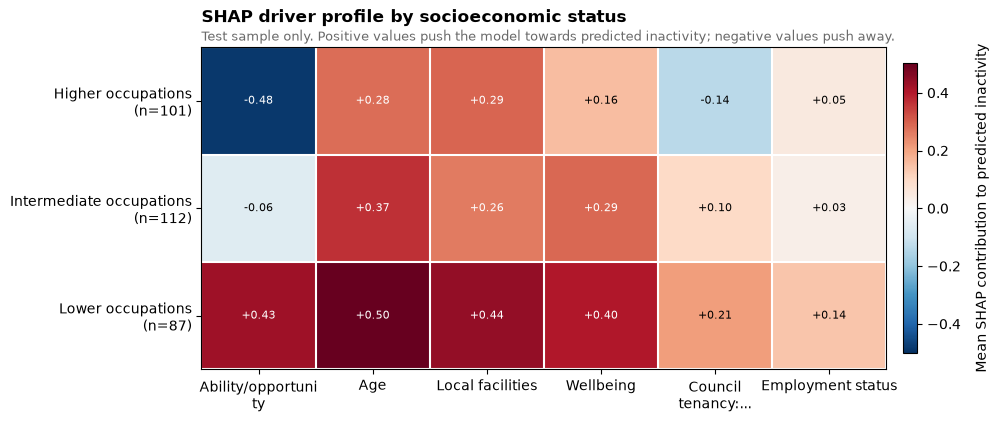

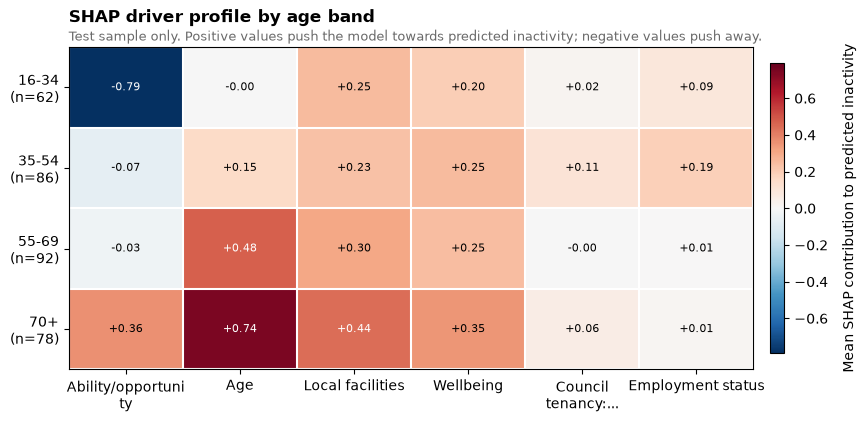

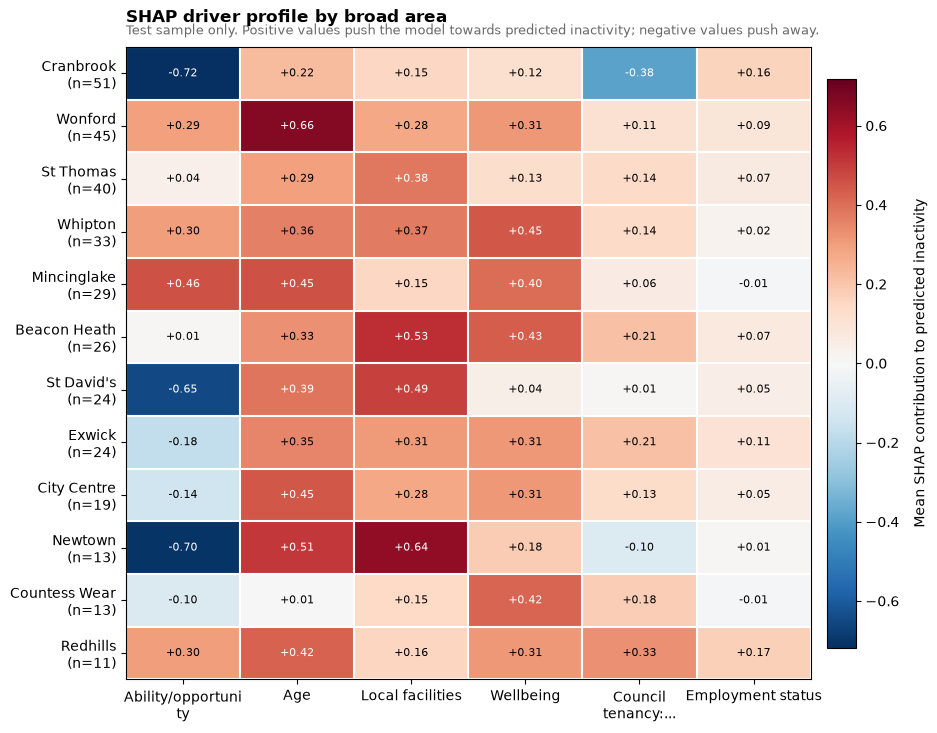

,subgroup,q4,q11,q9,q5,Q8a_dk,q18,subgroup_dimension
0,Higher occupations,-0.484996,0.278631,0.291677,0.156280,-0.137043,0.047209,Socioeconomic status
1,Intermediate occupations,-0.059632,0.366342,0.261775,0.287535,0.101816,0.027841,Socioeconomic status
2,Lower occupations,0.426428,0.502267,0.441291,0.402051,0.209017,0.139899,Socioeconomic status
3,16-34,-0.790875,-0.003123,0.249643,0.197292,0.022018,0.091101,Age band
4,35-54,-0.073592,0.150161,0.229793,0.252284,0.105664,0.185594,Age band
5,55-69,-0.033225,0.475426,0.303985,0.245808,-0.001638,0.005676,Age band
6,70+,0.363672,0.742385,0.441881,0.346737,0.059163,0.013274,Age band
7,Cranbrook,-0.718439,0.224513,0.150884,0.117826,-0.383062,0.160966,Broad area
8,Wonford,0.292125,0.662270,0.278550,0.314058,0.107599,0.089316,Broad area
9,St Thomas,0.037022,0.293827,0.380613,0.125585,0.139622,0.067308,Broad area


In [804]:
# SHAP subgroup driver profiles: use the existing model, X_test and inactivity-class SHAP values.
from matplotlib.colors import TwoSlopeNorm
import textwrap

SHAP_SUBGROUP_FIGURE_DIR = Path("non_relevant_figures")
SHAP_SUBGROUP_FIGURE_DIR.mkdir(exist_ok=True)

# X_test preserves survey-row indices through the existing preparation and split pipeline.
shap_test_metadata = raw_ds.reindex(X_test.index).copy()
if shap_test_metadata[["ns_sec_summ", "q11", "broad_area_name"]].isna().all(axis=None):
    raise ValueError("X_test row indices could not be matched to raw survey subgroup metadata.")

shap_test_metadata["socioeconomic_status"] = shap_test_metadata["ns_sec_summ"].map({
    1.0: "Higher occupations",
    2.0: "Intermediate occupations",
    3.0: "Lower occupations",
})
shap_test_metadata["age_band"] = pd.cut(
    shap_test_metadata["q11"],
    bins=[15, 34, 54, 69, np.inf],
    labels=["16-34", "35-54", "55-69", "70+"],
    include_lowest=True,
)

# Use the globally most influential individual features, then inspect their signed contribution in each subgroup.
shap_profile_features = shap_inactivity_importance.head(6)["feature"].tolist()
shap_profile_label_overrides = {
    "q4": "Ability/opportunity",
    "q11": "Age",
    "q5": "Wellbeing",
    "q9": "Local facilities",
    "Q8a": "Council tenancy",
    "q18": "Employment status",
}
shap_profile_labels = [
    shap_profile_label_overrides.get(
        feature, shorten(plot_feature_label(feature).replace("?", "..."), width=28, placeholder="...")
    )
    for feature in shap_profile_features
]
signed_shap_frame = pd.DataFrame(
    inactivity_shap_values[:, [X_test.columns.get_loc(feature) for feature in shap_profile_features]],
    index=X_test.index,
    columns=shap_profile_features,
)


def plot_shap_subgroup_profile(group_column, group_order, title, output_name):
    profile = signed_shap_frame.join(shap_test_metadata[[group_column]])
    profile = profile.dropna(subset=[group_column])
    group_counts = profile.groupby(group_column, observed=True).size().reindex(group_order)
    eligible_groups = group_counts[group_counts >= 10].index.tolist()
    profile = profile[profile[group_column].isin(eligible_groups)]
    if profile.empty:
        raise ValueError(f"No {group_column} groups have at least 10 test respondents for SHAP profiling.")

    mean_profile = profile.groupby(group_column, observed=True)[shap_profile_features].mean().reindex(eligible_groups)
    maximum = max(abs(mean_profile.min().min()), abs(mean_profile.max().max()), 0.05)
    fig, ax = plt.subplots(figsize=(12.5, max(5.2, 0.65 * len(eligible_groups) + 2.4)))
    image = ax.imshow(
        mean_profile.to_numpy(), cmap="RdBu_r",
        norm=TwoSlopeNorm(vmin=-maximum, vcenter=0, vmax=maximum), aspect="auto"
    )
    wrapped_labels = [textwrap.fill(label, width=17) for label in shap_profile_labels]
    ax.set_xticks(range(len(shap_profile_features)), wrapped_labels, rotation=0, ha="center")
    ax.set_yticks(
        range(len(eligible_groups)),
        [f"{group}\n(n={int(group_counts[group])})" for group in eligible_groups],
    )
    for row in range(len(eligible_groups)):
        for col in range(len(shap_profile_features)):
            value = mean_profile.iloc[row, col]
            ax.text(col, row, f"{value:+.2f}", ha="center", va="center", fontsize=8,
                    color="white" if abs(value) > maximum * 0.52 else "black")
    ax.set_title(title, loc="left", pad=18, fontweight="bold")
    ax.text(0, 1.02, "Test sample only. Positive values push the model towards predicted inactivity; negative values push away.",
            transform=ax.transAxes, color="dimgray", fontsize=9)
    ax.set_xticks(np.arange(-0.5, len(shap_profile_features), 1), minor=True)
    ax.set_yticks(np.arange(-0.5, len(eligible_groups), 1), minor=True)
    ax.grid(which="minor", color="white", linewidth=1.5)
    ax.tick_params(which="minor", bottom=False, left=False)
    colour_bar = fig.colorbar(image, ax=ax, shrink=0.9, pad=0.02)
    colour_bar.set_label("Mean SHAP contribution to predicted inactivity", labelpad=10)
    fig.subplots_adjust(left=0.20, right=0.86, bottom=0.24, top=0.86)
    fig.savefig(SHAP_SUBGROUP_FIGURE_DIR / output_name, dpi=220, bbox_inches="tight")
    plt.show()
    return mean_profile, group_counts


shap_ses_profile, shap_ses_counts = plot_shap_subgroup_profile(
    "socioeconomic_status",
    ["Higher occupations", "Intermediate occupations", "Lower occupations"],
    "SHAP driver profile by socioeconomic status",
    "15_shap_driver_profile_by_ses.png",
)
shap_age_profile, shap_age_counts = plot_shap_subgroup_profile(
    "age_band",
    ["16-34", "35-54", "55-69", "70+"],
    "SHAP driver profile by age band",
    "16_shap_driver_profile_by_age.png",
)
shap_area_order = shap_test_metadata["broad_area_name"].value_counts().index.tolist()
shap_area_profile, shap_area_counts = plot_shap_subgroup_profile(
    "broad_area_name",
    shap_area_order,
    "SHAP driver profile by broad area",
    "17_shap_driver_profile_by_broad_area.png",
)

shap_subgroup_profile_table = pd.concat(
    [
        shap_ses_profile.assign(subgroup_dimension="Socioeconomic status"),
        shap_age_profile.assign(subgroup_dimension="Age band"),
        shap_area_profile.assign(subgroup_dimension="Broad area"),
    ]
).reset_index(names="subgroup")
display(shap_subgroup_profile_table)


## How feature values influence the inactivity prediction

These are dependence charts for the **Inactive** class (class 0) only. Each point is a test respondent. The horizontal zero line is the model baseline: values above it increase the inactive-class model score, while values below it decrease it. The orange line is the mean SHAP contribution within each age band or feature value, making the direction of the relationship easier to read. These charts explain the fitted model and do not demonstrate causality.


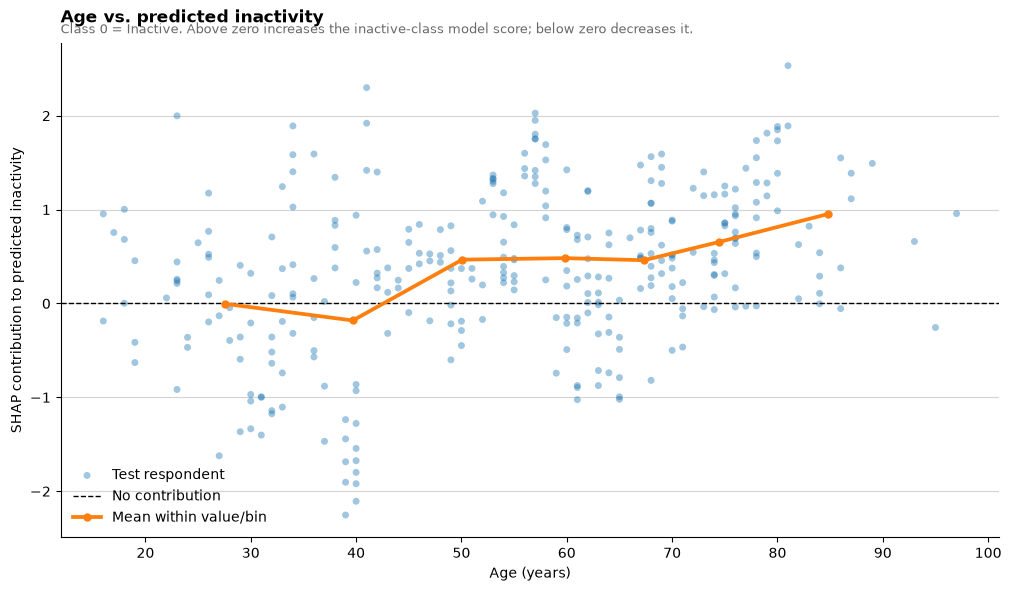

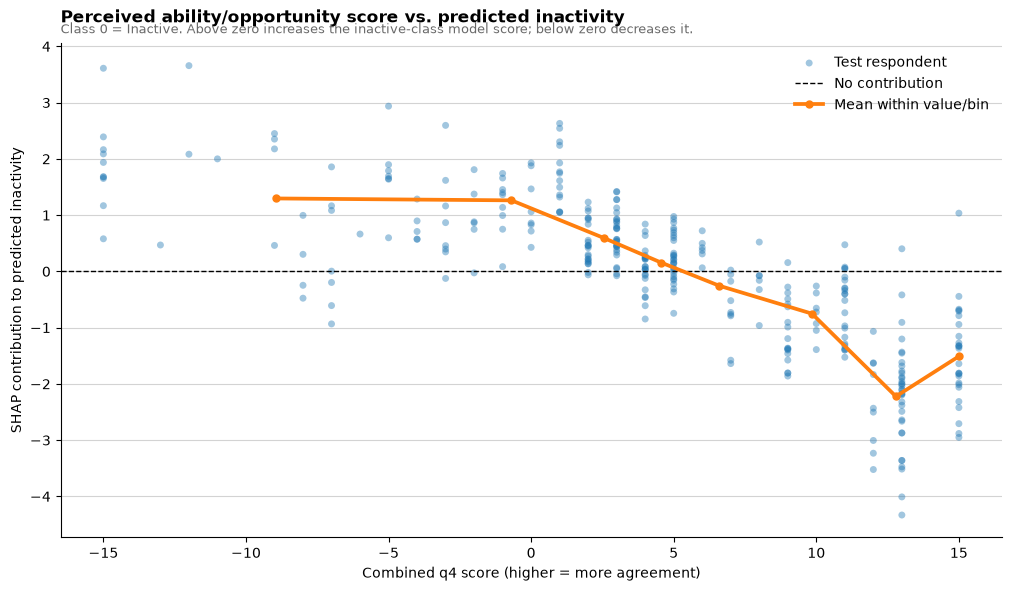

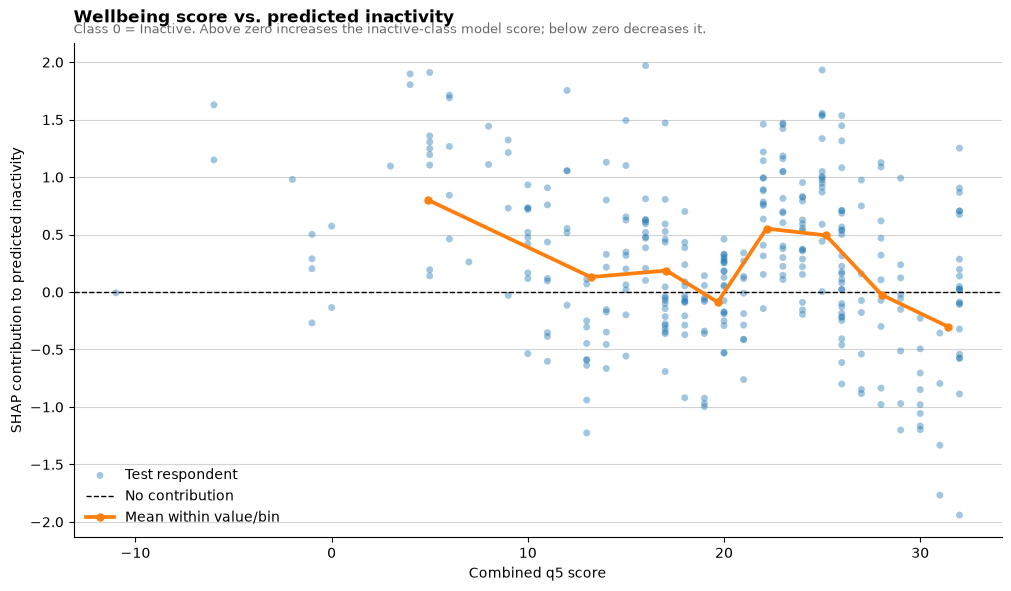

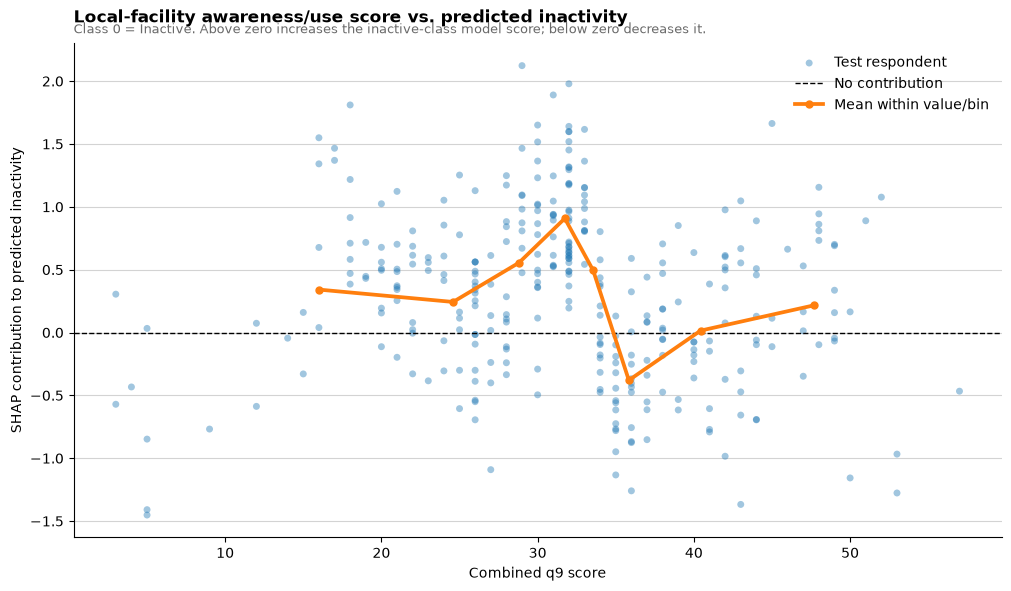

,bin,feature_value,mean_shap,n,feature,feature_label
0,16-34,27.516129,-0.003123,62,q11,age
1,35-44,39.690476,-0.181337,42,q11,age
2,45-54,50.068182,0.466591,44,q11,age
3,55-64,59.822581,0.482680,62,q11,age
4,65-69,67.333333,0.460435,30,q11,age
5,70-79,74.436364,0.654192,55,q11,age
6,80+,84.826087,0.953280,23,q11,age
7,"(-15.001, -4.0]",-8.952381,1.296559,42,q4,perceived ability/opportunity score
8,"(-4.0, 1.0]",-0.688889,1.262838,45,q4,perceived ability/opportunity score
9,"(1.0, 3.0]",2.557692,0.592172,52,q4,perceived ability/opportunity score


In [805]:
# SHAP dependence charts for the Inactive class (class 0): how values influence the prediction.
SHAP_VALUE_EFFECT_FIGURE_DIR = Path("non_relevant_figures")
SHAP_VALUE_EFFECT_FIGURE_DIR.mkdir(exist_ok=True)


def plot_inactivity_shap_dependence(feature, display_name, x_axis_label, output_name, age_bands=False):
    """Plot individual class-0 SHAP contributions plus an interpretable binned mean trend."""
    if feature not in X_test.columns:
        raise KeyError(f"{feature} is not present in X_test")
    feature_position = X_test.columns.get_loc(feature)
    effect_df = pd.DataFrame({
        "feature_value": pd.to_numeric(X_test[feature], errors="coerce"),
        "inactive_shap": inactivity_shap_values[:, feature_position],
    }).dropna()
    if feature == "q11":
        effect_df = effect_df.loc[effect_df["feature_value"] >= 16].copy()

    if age_bands:
        effect_df["bin"] = pd.cut(
            effect_df["feature_value"],
            bins=[15, 34, 44, 54, 64, 69, 79, np.inf],
            labels=["16-34", "35-44", "45-54", "55-64", "65-69", "70-79", "80+"],
        )
        trend = (
            effect_df.groupby("bin", observed=True)
            .agg(feature_value=("feature_value", "mean"), mean_shap=("inactive_shap", "mean"), n=("inactive_shap", "size"))
            .reset_index()
        )
    else:
        # Derived scores are discrete; for a large number of distinct values, use quantile bins.
        if effect_df["feature_value"].nunique() <= 20:
            trend = (
                effect_df.groupby("feature_value", observed=True)["inactive_shap"]
                .agg(mean_shap="mean", n="size")
                .reset_index()
            )
        else:
            effect_df["bin"] = pd.qcut(effect_df["feature_value"], q=8, duplicates="drop")
            trend = (
                effect_df.groupby("bin", observed=True)
                .agg(feature_value=("feature_value", "mean"), mean_shap=("inactive_shap", "mean"), n=("inactive_shap", "size"))
                .reset_index()
            )
    trend = trend.loc[trend["n"] >= 5].copy()

    fig, ax = plt.subplots(figsize=(10, 5.8), constrained_layout=True)
    ax.scatter(effect_df["feature_value"], effect_df["inactive_shap"], s=25, alpha=0.42, color="tab:blue", edgecolors="none", label="Test respondent")
    ax.axhline(0, color="black", linewidth=1.0, linestyle="--", label="No contribution")
    ax.plot(trend["feature_value"], trend["mean_shap"], color="tab:orange", linewidth=2.7, marker="o", markersize=5, label="Mean within value/bin")
    ax.set_xlabel(x_axis_label)
    ax.set_ylabel("SHAP contribution to predicted inactivity")
    ax.set_title(f"{display_name.capitalize()} vs. predicted inactivity", loc="left", pad=15, fontweight="bold")
    ax.text(0, 1.02, "Class 0 = Inactive. Above zero increases the inactive-class model score; below zero decreases it.",
            transform=ax.transAxes, color="dimgray", fontsize=9)
    ax.yaxis.grid(True, color="lightgray", linewidth=0.8)
    ax.set_axisbelow(True)
    ax.spines[["top", "right"]].set_visible(False)
    ax.legend(frameon=False, loc="best")
    fig.savefig(SHAP_VALUE_EFFECT_FIGURE_DIR / output_name, dpi=220)
    plt.show()
    return trend.assign(feature=feature, feature_label=display_name)


age_shap_trend = plot_inactivity_shap_dependence(
    "q11", "age", "Age (years)", "18_shap_age_value_effect_on_inactivity.png", age_bands=True
)
q4_shap_trend = plot_inactivity_shap_dependence(
    "q4", "perceived ability/opportunity score", "Combined q4 score (higher = more agreement)",
    "19_shap_ability_opportunity_value_effect_on_inactivity.png"
)
q5_shap_trend = plot_inactivity_shap_dependence(
    "q5", "wellbeing score", "Combined q5 score", "20_shap_wellbeing_value_effect_on_inactivity.png"
)
q9_shap_trend = plot_inactivity_shap_dependence(
    "q9", "local-facility awareness/use score", "Combined q9 score",
    "21_shap_local_facility_value_effect_on_inactivity.png"
)

shap_value_effect_summary = pd.concat([age_shap_trend, q4_shap_trend, q5_shap_trend, q9_shap_trend], ignore_index=True)
display(shap_value_effect_summary)


## Subgroup analysis: socioeconomic status, age and area

This section uses the same survey extract as the existing pipeline. Inactivity means activity level 1 (less than 30 minutes); the denominator is respondents with a stated activity level (1-3). Rates are unweighted to remain consistent with the current modelling pipeline. The figures show descriptive relationships, not causal effects. For ability/opportunity comparisons, agreement means strongly agree or agree; cells with fewer than 10 respondents are suppressed. Age bands are 16-34, 35-54, 55-69 and 70+.


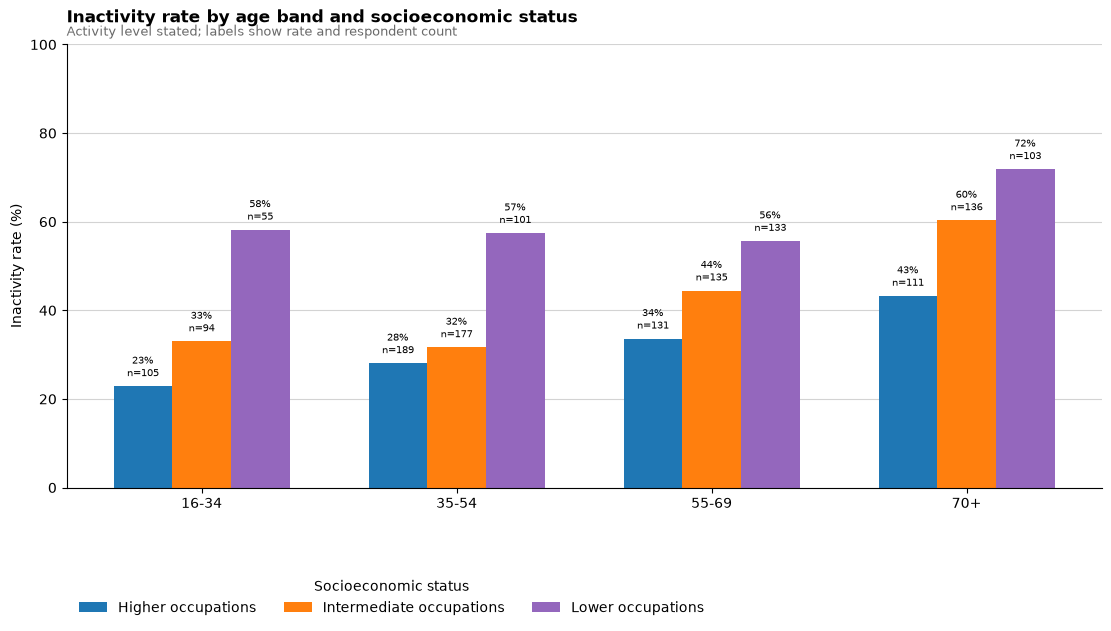

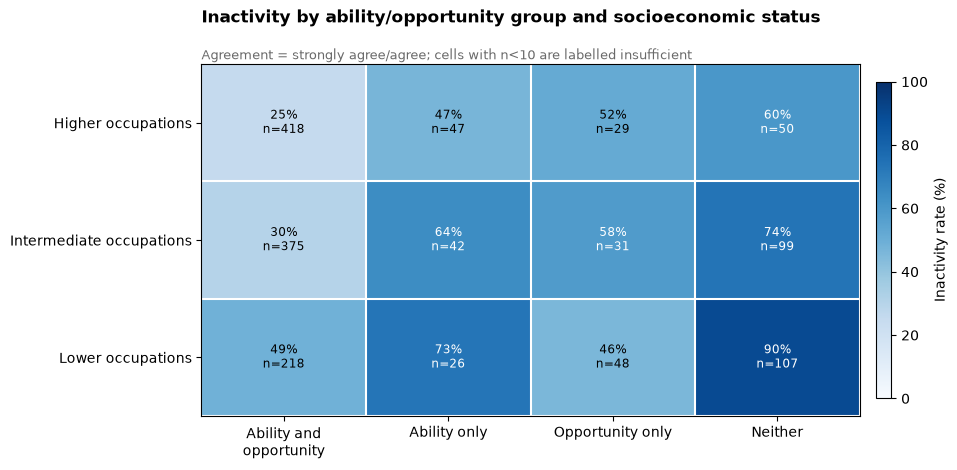

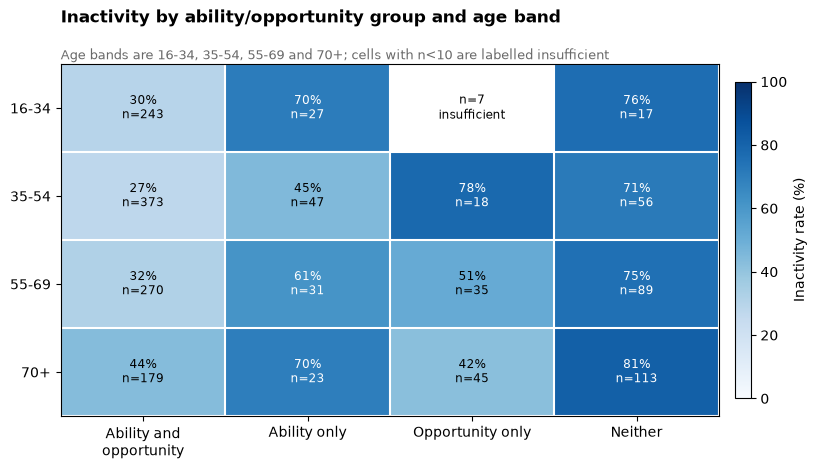

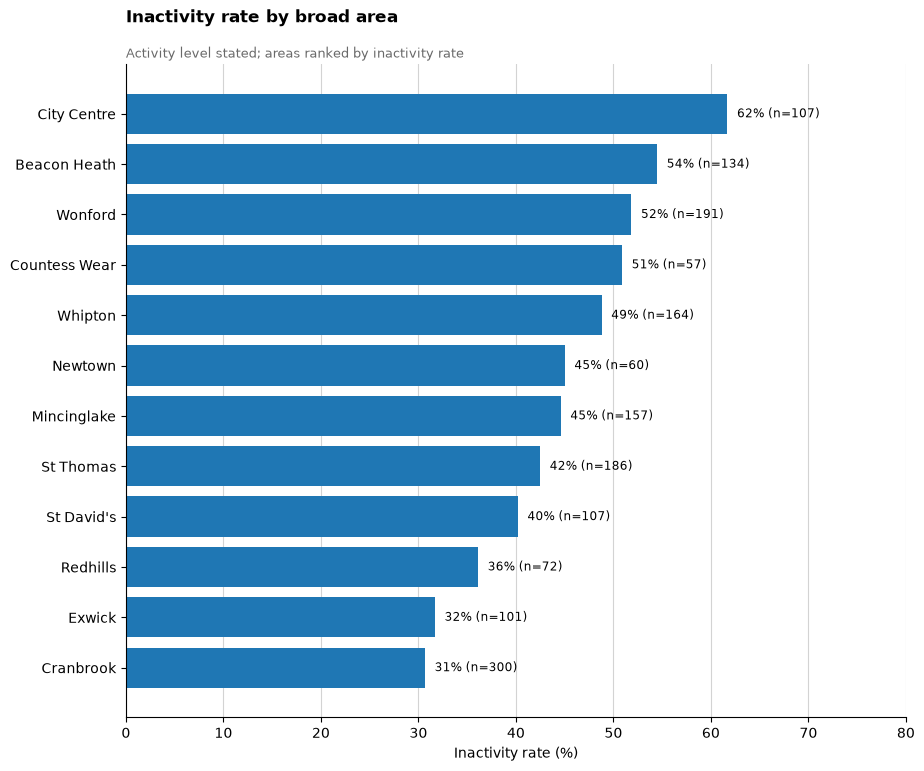

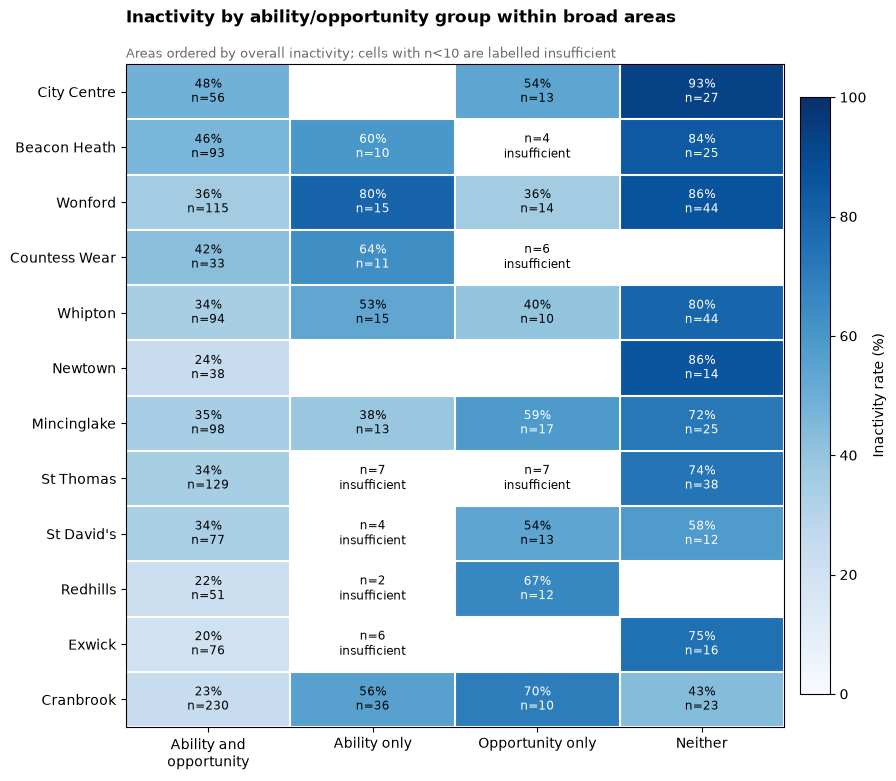

Created variable mapping workbook: report_variables_and_subgroup_results_v2.xlsx


,variable,report_label,type,definition_or_use,source_codebook_label
0,activity_level,Activity level,Outcome,1 = inactive (<30 minutes); 2 = fairly active;...,OVERALL ACTIVITY LEVELS (based on moderate phy...
1,q4,"Perceived ability, opportunity, enjoyment and ...",Model-derived combined score,Combined from q4a?q4e in the existing pipeline...,
2,q4a,Perceived ability to be physically active,Survey question,Agree = strongly agree or agree (codes 1?2),I feel that I have the ability to be physicall...
3,q4b,Perceived opportunity to be physically active,Survey question,Agree = strongly agree or agree (codes 1?2),i I feel that I have the opportunity to be phy...
4,ability_opportunity_group,Ability/opportunity group,Derived subgroup,Ability and opportunity; ability only; opportu...,
5,q5,Personal wellbeing,Model-derived combined score,Combined from q5a?q5d in the existing pipeline,
6,q9,Awareness and use of local activity facilities,Model-derived combined score,Combined from q9a?q9p in the existing pipeline,
7,q11,Age,Survey question,Used to create the requested age bands,Age:
8,age_band,Age band,Derived subgroup,16-34; 35-54; 55-69; 70+,
9,ns_sec_summ,Socioeconomic status,Survey question,"Charts use higher, intermediate and lower occu...",SUMMARY GROUPS: Socio-economic status


,age_band,socioeconomic_status,respondents,inactive_count,inactivity_rate,inactivity_percent
0,16-34,Higher occupations,105,24,0.228571,22.857143
1,16-34,Intermediate occupations,94,31,0.329787,32.978723
2,16-34,Lower occupations,55,32,0.581818,58.181818
3,35-54,Higher occupations,189,53,0.280423,28.042328
4,35-54,Intermediate occupations,177,56,0.316384,31.638418
5,35-54,Lower occupations,101,58,0.574257,57.425743
6,55-69,Higher occupations,131,44,0.335878,33.587786
7,55-69,Intermediate occupations,135,60,0.444444,44.444444
8,55-69,Lower occupations,133,74,0.556391,55.639098
9,70+,Higher occupations,111,48,0.432432,43.243243


In [806]:
# Subgroup analysis and variable-label workbook
from pathlib import Path
from textwrap import shorten, wrap
from IPython.display import display
import matplotlib.pyplot as plt
from matplotlib.colors import Normalize

SUBGROUP_FIGURE_DIR = Path("relevant_figures")
SUBGROUP_FIGURE_DIR.mkdir(exist_ok=True)
VARIABLE_WORKBOOK_PATH = Path("report_variables_and_subgroup_results_v2.xlsx")

# Use raw survey responses so subgroup definitions are transparent and independent of model encoding.
subgroup_df = raw_ds.loc[raw_ds["activity_level"].isin([1.0, 2.0, 3.0])].copy()
subgroup_df["inactive"] = subgroup_df["activity_level"].eq(1.0)

age_band_order = ["16-34", "35-54", "55-69", "70+"]
subgroup_df["age_band"] = pd.cut(
    subgroup_df["q11"],
    bins=[15, 34, 54, 69, np.inf],
    labels=age_band_order,
    include_lowest=True,
).astype("category")
subgroup_df["age_band"] = subgroup_df["age_band"].cat.set_categories(age_band_order, ordered=True)

ses_labels = {
    1.0: "Higher occupations",
    2.0: "Intermediate occupations",
    3.0: "Lower occupations",
}
ses_order = list(ses_labels.values())
subgroup_df["socioeconomic_status"] = subgroup_df["ns_sec_summ"].map(ses_labels)

# q4a and q4b are the source questions for the ability/opportunity paradox.
valid_likert = subgroup_df["q4a"].isin([1.0, 2.0, 3.0, 4.0, 5.0]) & subgroup_df["q4b"].isin([1.0, 2.0, 3.0, 4.0, 5.0])
driver_df = subgroup_df.loc[valid_likert].copy()
driver_df["agrees_ability"] = driver_df["q4a"].isin([1.0, 2.0])
driver_df["agrees_opportunity"] = driver_df["q4b"].isin([1.0, 2.0])
driver_group_order = [
    "Ability and opportunity",
    "Ability only",
    "Opportunity only",
    "Neither",
]
driver_df["ability_opportunity_group"] = np.select(
    [
        driver_df["agrees_ability"] & driver_df["agrees_opportunity"],
        driver_df["agrees_ability"] & ~driver_df["agrees_opportunity"],
        ~driver_df["agrees_ability"] & driver_df["agrees_opportunity"],
    ],
    driver_group_order[:3],
    default="Neither",
)
driver_df["ability_opportunity_group"] = pd.Categorical(
    driver_df["ability_opportunity_group"], categories=driver_group_order, ordered=True
)


def inactivity_summary(frame, group_columns):
    """Return unweighted subgroup counts and inactivity rates with explicit denominators."""
    summary = (
        frame.dropna(subset=group_columns)
        .groupby(group_columns, observed=True)["inactive"]
        .agg(respondents="size", inactive_count="sum", inactivity_rate="mean")
        .reset_index()
    )
    summary["inactivity_percent"] = summary["inactivity_rate"] * 100
    return summary


def build_rate_matrix(summary, rows, columns, row_order, column_order):
    rates = summary.pivot(index=rows, columns=columns, values="inactivity_percent").reindex(
        index=row_order, columns=column_order
    )
    counts = summary.pivot(index=rows, columns=columns, values="respondents").reindex(
        index=row_order, columns=column_order
    )
    return rates, counts


def plot_rate_heatmap(rates, counts, title, subtitle, output_name):
    """Plot rates with a stable 0?100% scale and suppress unstable cells (n < 10)."""
    display_rates = rates.copy()
    display_rates[counts < 10] = np.nan
    fig, ax = plt.subplots(figsize=(12.2, max(5.5, 0.68 * len(display_rates) + 2.2)))
    image = ax.imshow(display_rates.to_numpy(dtype=float), cmap="Blues", vmin=0, vmax=100, aspect="auto")
    wrapped_columns = ["\n".join(wrap(str(column), width=16)) for column in display_rates.columns]
    ax.set_xticks(range(len(display_rates.columns)), wrapped_columns, rotation=0, ha="center")
    ax.set_yticks(range(len(display_rates.index)), display_rates.index)
    for row_index in range(len(display_rates.index)):
        for col_index in range(len(display_rates.columns)):
            rate = rates.iloc[row_index, col_index]
            n = counts.iloc[row_index, col_index]
            if pd.isna(n):
                label = "?"
            elif n < 10:
                label = f"n={int(n)}\ninsufficient"
            else:
                label = f"{rate:.0f}%\nn={int(n)}"
            ax.text(col_index, row_index, label, ha="center", va="center", fontsize=8.5,
                    color="white" if pd.notna(rate) and rate >= 58 else "black")
    ax.set_title(title, loc="left", pad=30, fontweight="bold")
    ax.text(0, 1.005, subtitle, transform=ax.transAxes, color="dimgray", fontsize=9, va="bottom")
    ax.set_xticks(np.arange(-0.5, len(display_rates.columns), 1), minor=True)
    ax.set_yticks(np.arange(-0.5, len(display_rates.index), 1), minor=True)
    ax.grid(which="minor", color="white", linewidth=1.5)
    ax.tick_params(which="minor", bottom=False, left=False)
    colour_bar = fig.colorbar(image, ax=ax, shrink=0.9, pad=0.02)
    colour_bar.set_label("Inactivity rate (%)")
    fig.subplots_adjust(left=0.25, right=0.90, bottom=0.22, top=0.86)
    fig.savefig(SUBGROUP_FIGURE_DIR / output_name, dpi=220, bbox_inches="tight")
    plt.show()


# Figure 10: combined demographic pattern.
age_ses_summary = inactivity_summary(
    subgroup_df.loc[subgroup_df["socioeconomic_status"].notna() & subgroup_df["age_band"].notna()],
    ["age_band", "socioeconomic_status"],
)
fig, ax = plt.subplots(figsize=(11, 6.2), constrained_layout=True)
bar_width = 0.23
positions = np.arange(len(age_band_order))
palette = ["tab:blue", "tab:orange", "tab:purple"]
for offset, (ses, colour) in enumerate(zip(ses_order, palette)):
    subset = age_ses_summary.set_index(["age_band", "socioeconomic_status"]).reindex(
        pd.MultiIndex.from_product([age_band_order, [ses]], names=["age_band", "socioeconomic_status"])
    ).reset_index()
    bars = ax.bar(positions + (offset - 1) * bar_width, subset["inactivity_percent"], width=bar_width,
                  label=ses, color=colour)
    for bar, n, rate in zip(bars, subset["respondents"], subset["inactivity_percent"]):
        if pd.notna(n):
            ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 1.5, f"{rate:.0f}%\nn={int(n)}",
                    ha="center", va="bottom", fontsize=7.5)
ax.set_xticks(positions, age_band_order)
ax.set_ylim(0, 100)
ax.set_ylabel("Inactivity rate (%)")
ax.set_title("Inactivity rate by age band and socioeconomic status", loc="left", pad=16, fontweight="bold")
ax.text(0, 1.02, "Activity level stated; labels show rate and respondent count", transform=ax.transAxes,
        color="dimgray", fontsize=9)
ax.yaxis.grid(True, color="lightgray", linewidth=0.8)
ax.set_axisbelow(True)
ax.spines[["top", "right"]].set_visible(False)
ax.legend(title="Socioeconomic status", frameon=False, ncol=3, loc="upper left", bbox_to_anchor=(0, -0.18))
fig.savefig(SUBGROUP_FIGURE_DIR / "10_inactivity_by_age_and_ses.png", dpi=220)
plt.show()

# Figure 11: does the ability/opportunity relationship differ by socioeconomic status?
ses_driver_summary = inactivity_summary(
    driver_df.loc[driver_df["socioeconomic_status"].notna()],
    ["socioeconomic_status", "ability_opportunity_group"],
)
ses_rates, ses_counts = build_rate_matrix(
    ses_driver_summary, "socioeconomic_status", "ability_opportunity_group", ses_order, driver_group_order
)
plot_rate_heatmap(
    ses_rates, ses_counts,
    "Inactivity by ability/opportunity group and socioeconomic status",
    "Agreement = strongly agree/agree; cells with n<10 are labelled insufficient",
    "11_inactivity_by_ability_opportunity_and_ses.png",
)

# Figure 12: the requested age bands use the same within-subgroup relationship.
age_driver_summary = inactivity_summary(
    driver_df.loc[driver_df["age_band"].notna()],
    ["age_band", "ability_opportunity_group"],
)
age_rates, age_counts = build_rate_matrix(
    age_driver_summary, "age_band", "ability_opportunity_group", age_band_order, driver_group_order
)
plot_rate_heatmap(
    age_rates, age_counts,
    "Inactivity by ability/opportunity group and age band",
    "Age bands are 16-34, 35-54, 55-69 and 70+; cells with n<10 are labelled insufficient",
    "12_inactivity_by_ability_opportunity_and_age.png",
)

# Figure 13: area-level rates use broad_area_name, as requested.
area_summary = inactivity_summary(subgroup_df.dropna(subset=["broad_area_name"]), ["broad_area_name"])
area_summary = area_summary.sort_values("inactivity_percent", ascending=True)
fig, ax = plt.subplots(figsize=(12, max(7.4, 0.55 * len(area_summary) + 2.0)))
bars = ax.barh(area_summary["broad_area_name"], area_summary["inactivity_percent"], color="tab:blue")
for bar, n, rate in zip(bars, area_summary["respondents"], area_summary["inactivity_percent"]):
    ax.text(bar.get_width() + 1, bar.get_y() + bar.get_height() / 2, f"{rate:.0f}% (n={int(n)})",
            va="center", fontsize=8.5)
ax.set_xlim(0, max(80, area_summary["inactivity_percent"].max() + 14))
ax.set_xlabel("Inactivity rate (%)")
ax.set_title("Inactivity rate by broad area", loc="left", pad=30, fontweight="bold")
ax.text(0, 1.005, "Activity level stated; areas ranked by inactivity rate", transform=ax.transAxes,
        color="dimgray", fontsize=9, va="bottom")
ax.xaxis.grid(True, color="lightgray", linewidth=0.8)
ax.set_axisbelow(True)
ax.spines[["top", "right"]].set_visible(False)
fig.subplots_adjust(left=0.30, right=0.95, bottom=0.10, top=0.86)
fig.savefig(SUBGROUP_FIGURE_DIR / "13_inactivity_by_broad_area.png", dpi=220, bbox_inches="tight")
plt.show()

# Figure 14: relationship within each broad area. Areas are ordered by their overall inactivity rate.
area_order = area_summary.sort_values("inactivity_percent", ascending=False)["broad_area_name"].tolist()
area_driver_summary = inactivity_summary(
    driver_df.dropna(subset=["broad_area_name"]),
    ["broad_area_name", "ability_opportunity_group"],
)
area_rates, area_counts = build_rate_matrix(
    area_driver_summary, "broad_area_name", "ability_opportunity_group", area_order, driver_group_order
)
plot_rate_heatmap(
    area_rates, area_counts,
    "Inactivity by ability/opportunity group within broad areas",
    "Areas ordered by overall inactivity; cells with n<10 are labelled insufficient",
    "14_inactivity_by_ability_opportunity_and_area.png",
)

# Workbook: traceable report labels, definitions and the tables behind the new subgroup charts.
def codebook_label(variable):
    return label_ds.loc[variable, "variable_label"] if variable in label_ds.index else ""

mapping_rows = [
    ("activity_level", "Activity level", "Outcome", "1 = inactive (<30 minutes); 2 = fairly active; 3 = active; 4/not stated excluded", codebook_label("activity_level")),
    ("q4", "Perceived ability, opportunity, enjoyment and motivation", "Model-derived combined score", "Combined from q4a?q4e in the existing pipeline; report subgroup graphs use q4a/q4b directly", ""),
    ("q4a", "Perceived ability to be physically active", "Survey question", "Agree = strongly agree or agree (codes 1?2)", codebook_label("q4a")),
    ("q4b", "Perceived opportunity to be physically active", "Survey question", "Agree = strongly agree or agree (codes 1?2)", codebook_label("q4b")),
    ("ability_opportunity_group", "Ability/opportunity group", "Derived subgroup", "Ability and opportunity; ability only; opportunity only; neither", ""),
    ("q5", "Personal wellbeing", "Model-derived combined score", "Combined from q5a?q5d in the existing pipeline", ""),
    ("q9", "Awareness and use of local activity facilities", "Model-derived combined score", "Combined from q9a?q9p in the existing pipeline", ""),
    ("q11", "Age", "Survey question", "Used to create the requested age bands", codebook_label("q11")),
    ("age_band", "Age band", "Derived subgroup", "16-34; 35-54; 55-69; 70+", ""),
    ("ns_sec_summ", "Socioeconomic status", "Survey question", "Charts use higher, intermediate and lower occupations; students/unclassified and not stated excluded", codebook_label("ns_sec_summ")),
    ("broad_area_name", "Broad area", "Survey geography", "Area-level subgroup variable used as supplied", codebook_label("broad_area_name")),
    ("q16", "Long-term health condition", "Survey question", "Used in SHAP interpretation", codebook_label("q16")),
    ("q17", "Condition limits daily activities", "Survey question", "Used in SHAP interpretation", codebook_label("q17")),
    ("q18", "Employment status", "Survey question", "Used in SHAP interpretation", codebook_label("q18")),
    ("Q8a", "Council-housing tenancy", "Survey question", "Used in SHAP interpretation", codebook_label("Q8a")),
    ("q10", "Gender", "Survey question", "One-hot encoded for the existing model", codebook_label("q10")),
    ("q27_dk", "Working from home: missing/not stated", "Derived indicator", "Missing/response handling indicator from the existing pipeline", codebook_label("q27")),
]
variable_mapping = pd.DataFrame(
    mapping_rows,
    columns=["variable", "report_label", "type", "definition_or_use", "source_codebook_label"],
)

analysis_notes = pd.DataFrame({
    "item": ["Data source", "Outcome denominator", "Rate calculation", "Weighting", "Small-cell rule", "Causal interpretation"],
    "detail": [
        "data_raw__no_index.csv", "Respondents with activity_level 1, 2 or 3", 
        "100 ? inactive respondents (activity_level=1) / respondents in the subgroup with stated activity level",
        "Unweighted, matching the current notebook modelling pipeline", "Cells with fewer than 10 respondents are labelled insufficient in relationship heatmaps",
        "Descriptive subgroup associations; not evidence that a characteristic causes inactivity",
    ],
})

with pd.ExcelWriter(VARIABLE_WORKBOOK_PATH, engine="openpyxl") as writer:
    variable_mapping.to_excel(writer, sheet_name="Variable mapping", index=False)
    analysis_notes.to_excel(writer, sheet_name="Analysis notes", index=False)
    age_ses_summary.to_excel(writer, sheet_name="Age x SES", index=False)
    ses_driver_summary.to_excel(writer, sheet_name="Ability-opportunity x SES", index=False)
    age_driver_summary.to_excel(writer, sheet_name="Ability-opportunity x age", index=False)
    area_summary.to_excel(writer, sheet_name="Broad area", index=False)
    area_driver_summary.to_excel(writer, sheet_name="Ability-opportunity x area", index=False)
    # These profiles are created by the SHAP subgroup cell immediately above.
    shap_ses_profile.reset_index(names="socioeconomic_status").to_excel(writer, sheet_name="SHAP drivers - SES", index=False)
    shap_age_profile.reset_index(names="age_band").to_excel(writer, sheet_name="SHAP drivers - age", index=False)
    shap_area_profile.reset_index(names="broad_area_name").to_excel(writer, sheet_name="SHAP drivers - area", index=False)

# Make the workbook readable without changing any values.
from openpyxl import load_workbook
from openpyxl.styles import Font
workbook = load_workbook(VARIABLE_WORKBOOK_PATH)
for worksheet in workbook.worksheets:
    worksheet.freeze_panes = "A2"
    worksheet.auto_filter.ref = worksheet.dimensions
    for cell in worksheet[1]:
        cell.font = Font(bold=True)
    for column_cells in worksheet.columns:
        width = min(max(len(str(cell.value or "")) for cell in column_cells) + 2, 55)
        worksheet.column_dimensions[column_cells[0].column_letter].width = width
workbook.save(VARIABLE_WORKBOOK_PATH)

print(f"Created variable mapping workbook: {VARIABLE_WORKBOOK_PATH}")
display(variable_mapping)
display(age_ses_summary)


# Comparison groups

In [807]:
compare_ns_sec_summ = [
    {
        'ns_sec_summ': (0.0, 6.0),
        # 'salary': '> 50000'
    },
    {
        'ns_sec_summ': 1.0,
        # 'salary': '> 50000'
    },
    {
        'ns_sec_summ': 2.0,
        # 'salary': '> 50000'
    },
    {
        'ns_sec_summ': 3.0,
        # 'salary': '> 50000'
    },
]

In [808]:
compare_sex = [
    {
        'q10_1.0': 1.0,
    },
    {
        'q10_1.0': 0.0,
    },
]

In [809]:
compare_age = [
    {
        'q11': (0.0, 18.0),
    },
    {
        'q11': (18.1, 27.0),
    },
    {
        'q11': (27.1, 45.0),
    },
    {
        'q11': (45.1, 65.0),
    },
    {
        'q11': (65.1, 200.0),
    },
]

# Comparison

In [810]:
# compare_conditions = compare_ns_sec_summ
compare_conditions = compare_sex
# compare_conditions = compare_age

In [811]:
def do_pipeline_fit_model(conditions, source_ds, target_col_name,
                          model_fields_cols, req_model_fields_cols,
                          min_cor_val, max_cor_val, is_binary_class):
  source_ds = filter_dataframe(source_ds, conditions, how=HOW_FILTER)

  # Non-outcome column filtering can use all rows; correlation screening cannot.
  source_ds, candidate_fields = do_filter_columns(
      source_ds, target_col_name, list(model_fields_cols)
  )

  X, y = do_X_y_data(source_ds, target_col_name)
  # print(X.shape)
  # print(y.shape)
  X_train, X_test, y_train, y_test = split_source(X, y)
  X_train, X_test, model_fields_cols = screen_features_on_training_data(
      X_train, X_test, y_train, target_col_name, candidate_fields,
      min_cor_val, max_cor_val, req_model_fields_cols
  )

  model = fit_XGB(X_train, y_train, X_test, y_test, is_binary_class, upsample=True, verbose=True)

  return model, X_train, X_test, y_train, y_test

{'q10_1.0': 1.0} 


=== Filtered data ===
  Original number of records: 1636
  Filtered records: 945
  Records removed: 691
  Type of condition combination: and
  Number of applied conditions: 1


,feature,correlation,abs_correlation,n_samples,correlation_type,strength
0,q4,0.455508,0.455508,756,positive,weak
2,Q8a_dk,0.258007,0.258007,756,positive,very weak
1,q8_1,0.251704,0.251704,756,positive,very weak
3,q9,0.217316,0.217316,756,positive,very weak


,feature,correlation,abs_correlation,n_samples,correlation_type,strength
3,q20,-0.278224,0.278224,756,negative,very weak
2,q18,-0.268518,0.268518,756,negative,very weak
4,q27_dk,-0.244014,0.244014,756,negative,very weak
6,ns_sec_summ_3.0,-0.228385,0.228385,756,negative,very weak
5,q28b_dk,-0.224474,0.224474,756,negative,very weak
0,q6,-0.224239,0.224239,756,negative,very weak
1,Q8a,-0.206741,0.206741,756,negative,very weak


{0: 0.5625, 2: 0.6737896423304226, 1: 4.973294698096953}
Best: 0.9089205994897959 using {'colsample_bytree': 0.75, 'learning_rate': 0.5, 'max_depth': 5, 'n_estimators': 150, 'subsample': 1} 

Launching cross-validation for multiclass classification...
Fold amount: 5
Number of classes: 3
Dataset size: 1008
----------------------------------------------------------------------

Results of cross-validation:
                 Train Mean  Train Std  Train Min  Train Max  Test Mean  \
accuracy                1.0        0.0        1.0        1.0     0.8145   
precision_macro         1.0        0.0        1.0        1.0     0.8154   
recall_macro            1.0        0.0        1.0        1.0     0.8143   
f1_macro                1.0        0.0        1.0        1.0     0.8111   
roc_auc_ovr             1.0        0.0        1.0        1.0     0.9323   

                 Test Std  Test Min  Test Max  Test/Val diff  
accuracy           0.0208    0.7822    0.8416        -0.1855  
precision_macro

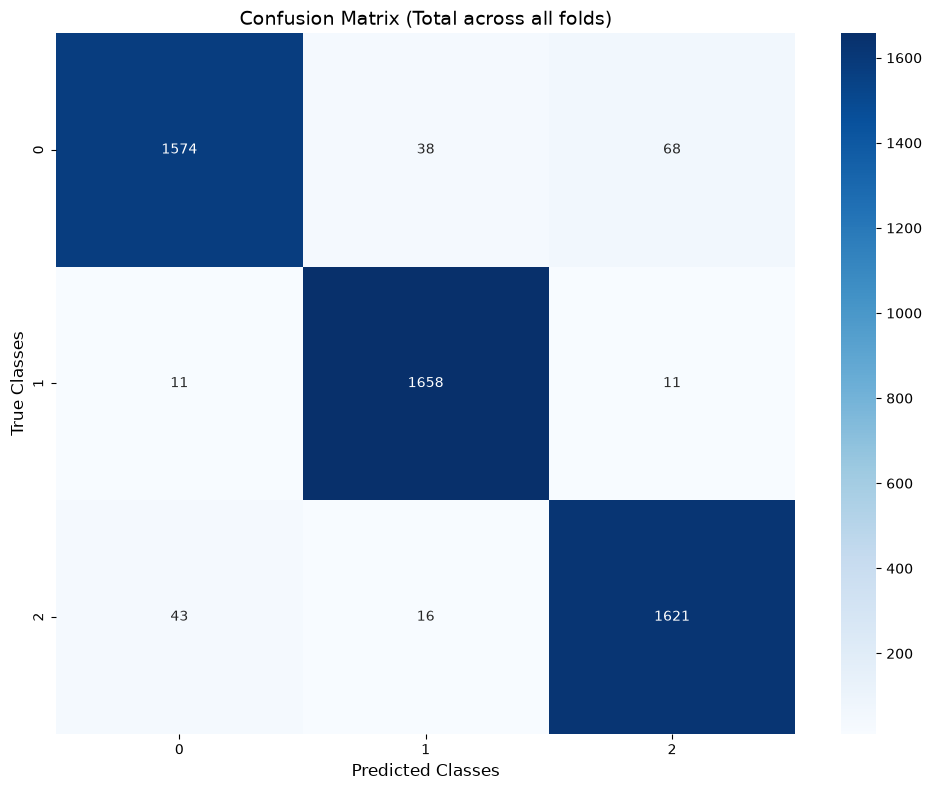

activity_level
0    336
2    307
1    113
Name: count, dtype: int64
activity_level
0    83
2    77
1    29
Name: count, dtype: int64
Classification report (Test): 

              precision    recall  f1-score   support

           0       0.53      0.71      0.61        83
           1       0.04      0.03      0.04        29
           2       0.54      0.35      0.43        77

    accuracy                           0.46       189
   macro avg       0.37      0.37      0.36       189
weighted avg       0.46      0.46      0.44       189

Confusion matrix (Test): 

        Pred 0  Pred 1  Pred 2
True 0   0.312   0.053   0.074
True 1   0.101   0.005   0.048
True 2   0.180   0.085   0.143

Train Accuracy: 0.917989417989418
Test Accuracy: 0.4603174603174603


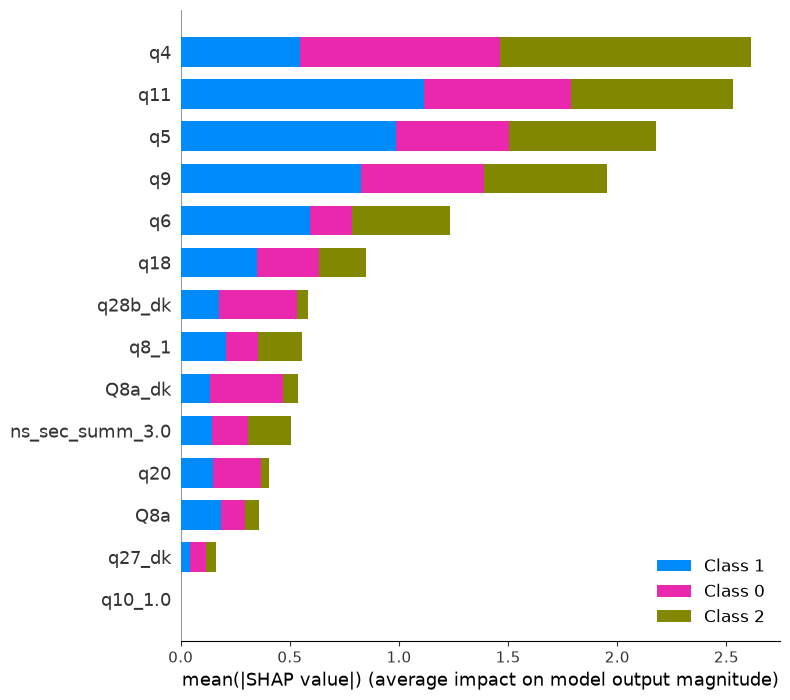

,feature,importance_class_0,importance_class_1,importance_class_2,importance_mean
0,q4,0.913637,0.547372,1.153515,0.871508
11,q11,0.677586,1.112233,0.740395,0.843404
13,q5,0.516550,0.985705,0.672784,0.725013
3,q9,0.563181,0.827466,0.562315,0.650988
9,q6,0.192990,0.593011,0.445276,0.410425
5,q18,0.283919,0.349235,0.215126,0.282760
8,q28b_dk,0.360261,0.173993,0.046809,0.193688
2,q8_1,0.146349,0.206112,0.202257,0.184906
1,Q8a_dk,0.332323,0.135049,0.068860,0.178744
7,ns_sec_summ_3.0,0.163093,0.144213,0.198885,0.168730


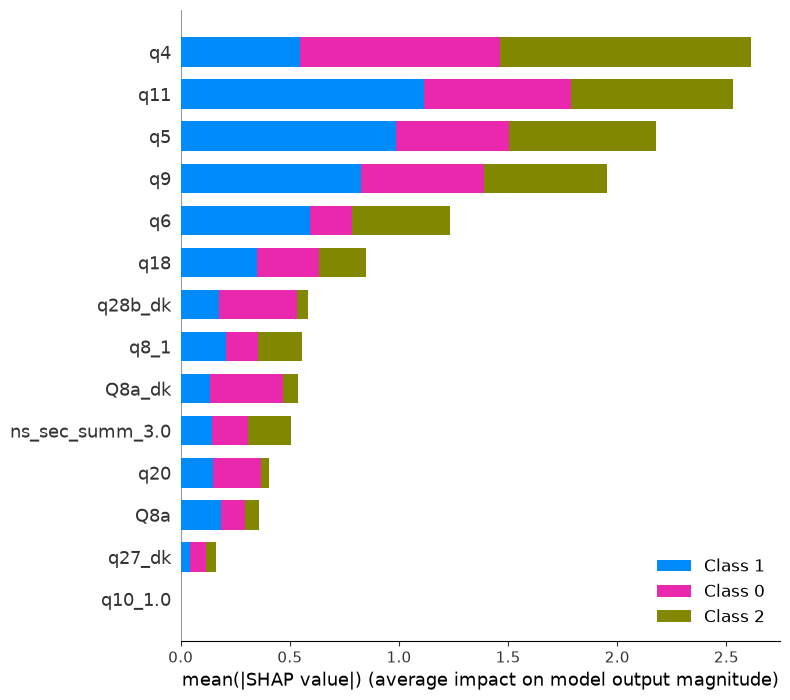

Inactive


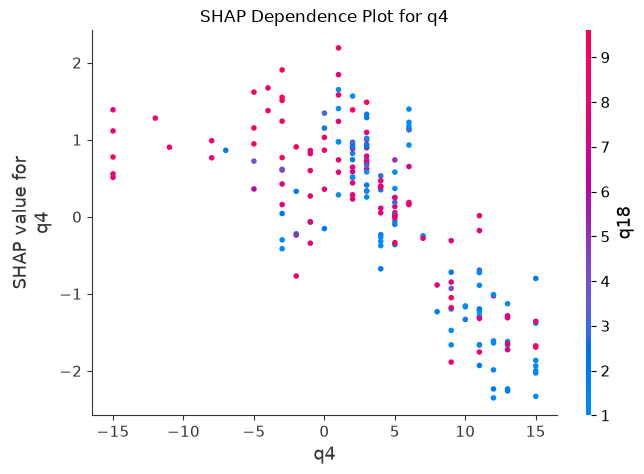

Fairly active


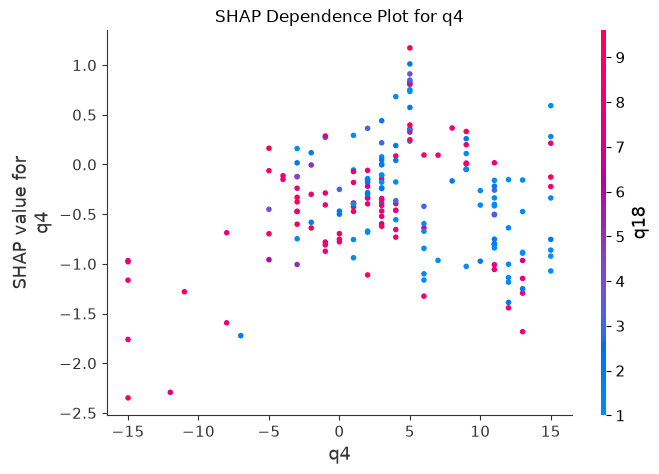

Active


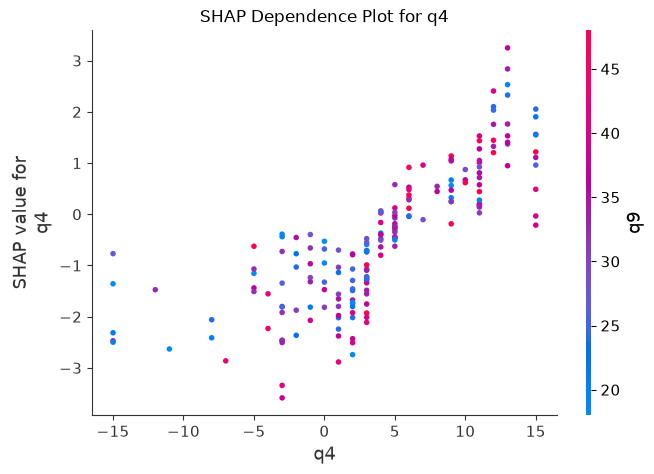





{'q10_1.0': 0.0} 


=== Filtered data ===
  Original number of records: 1636
  Filtered records: 691
  Records removed: 945
  Type of condition combination: and
  Number of applied conditions: 1


,feature,correlation,abs_correlation,n_samples,correlation_type,strength
0,q4,0.484180,0.484180,552,positive,weak
1,Q8a_dk,0.259241,0.259241,552,positive,very weak
3,q30_1,0.238578,0.238578,552,positive,very weak
2,q28a_5,0.214553,0.214553,552,positive,very weak
4,ns_sec_summ_1.0,0.213997,0.213997,552,positive,very weak


,feature,correlation,abs_correlation,n_samples,correlation_type,strength
3,q20,-0.285071,0.285071,552,negative,very weak
2,q18,-0.274415,0.274415,552,negative,very weak
5,q28b_dk,-0.269406,0.269406,552,negative,very weak
4,q27_dk,-0.267809,0.267809,552,negative,very weak
7,ns_sec_summ_3.0,-0.250807,0.250807,552,negative,very weak
0,q6,-0.210672,0.210672,552,negative,very weak
1,Q8a,-0.208232,0.208232,552,negative,very weak
6,ns_sec_8.0,-0.204577,0.204577,552,negative,very weak


{2: 0.568664337543671, 0: 0.5877777777777778, 1: 7.321799307958479}
Best: 0.9293632324373845 using {'colsample_bytree': 0.75, 'learning_rate': 0.3, 'max_depth': 5, 'n_estimators': 150, 'subsample': 1} 

Launching cross-validation for multiclass classification...
Fold amount: 5
Number of classes: 3
Dataset size: 732
----------------------------------------------------------------------

Results of cross-validation:
                 Train Mean  Train Std  Train Min  Train Max  Test Mean  \
accuracy                1.0        0.0        1.0        1.0     0.8305   
precision_macro         1.0        0.0        1.0        1.0     0.8312   
recall_macro            1.0        0.0        1.0        1.0     0.8304   
f1_macro                1.0        0.0        1.0        1.0     0.8275   
roc_auc_ovr             1.0        0.0        1.0        1.0     0.9512   

                 Test Std  Test Min  Test Max  Test/Val diff  
accuracy           0.0383    0.7808    0.8912        -0.1695  
preci

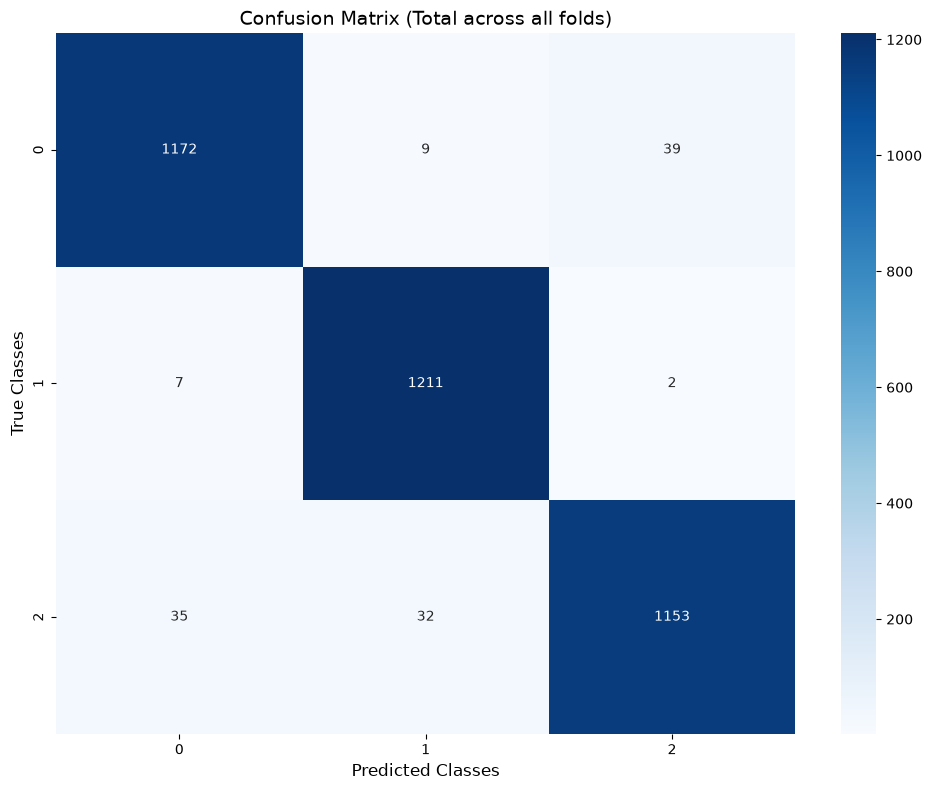

activity_level
2    244
0    240
1     68
Name: count, dtype: int64
activity_level
2    65
0    57
1    17
Name: count, dtype: int64
Classification report (Test): 

              precision    recall  f1-score   support

           0       0.67      0.51      0.58        57
           1       0.09      0.12      0.10        17
           2       0.59      0.68      0.63        65

    accuracy                           0.54       139
   macro avg       0.45      0.43      0.44       139
weighted avg       0.57      0.54      0.55       139

Confusion matrix (Test): 

        Pred 0  Pred 1  Pred 2
True 0   0.209   0.065   0.137
True 1   0.029   0.014   0.079
True 2   0.072   0.079   0.317

Train Accuracy: 0.9257246376811594
Test Accuracy: 0.539568345323741


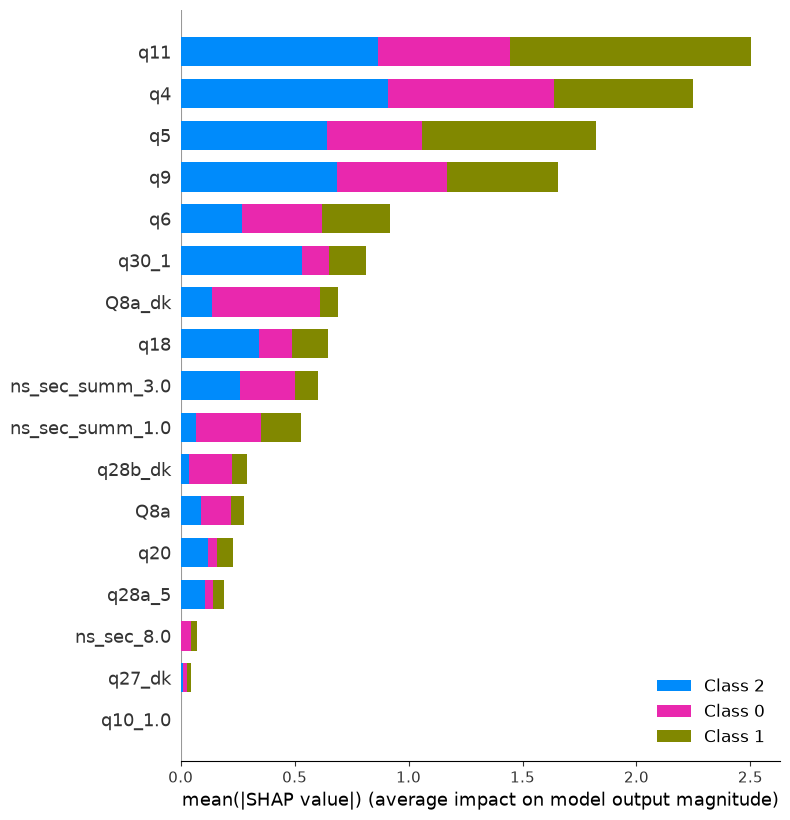

,feature,importance_class_0,importance_class_1,importance_class_2,importance_mean
13,q11,0.577430,1.061464,0.865663,0.834852
0,q4,0.730964,0.608428,0.907691,0.749028
15,q5,0.418575,0.762253,0.641697,0.607508
16,q9,0.483760,0.485893,0.686853,0.552169
10,q6,0.350309,0.299204,0.270341,0.306618
2,q30_1,0.119558,0.162576,0.530710,0.270948
1,Q8a_dk,0.474216,0.079140,0.138212,0.230522
6,q18,0.147024,0.157889,0.342638,0.215850
9,ns_sec_summ_3.0,0.241214,0.100086,0.261874,0.201058
4,ns_sec_summ_1.0,0.282317,0.176651,0.068882,0.175950


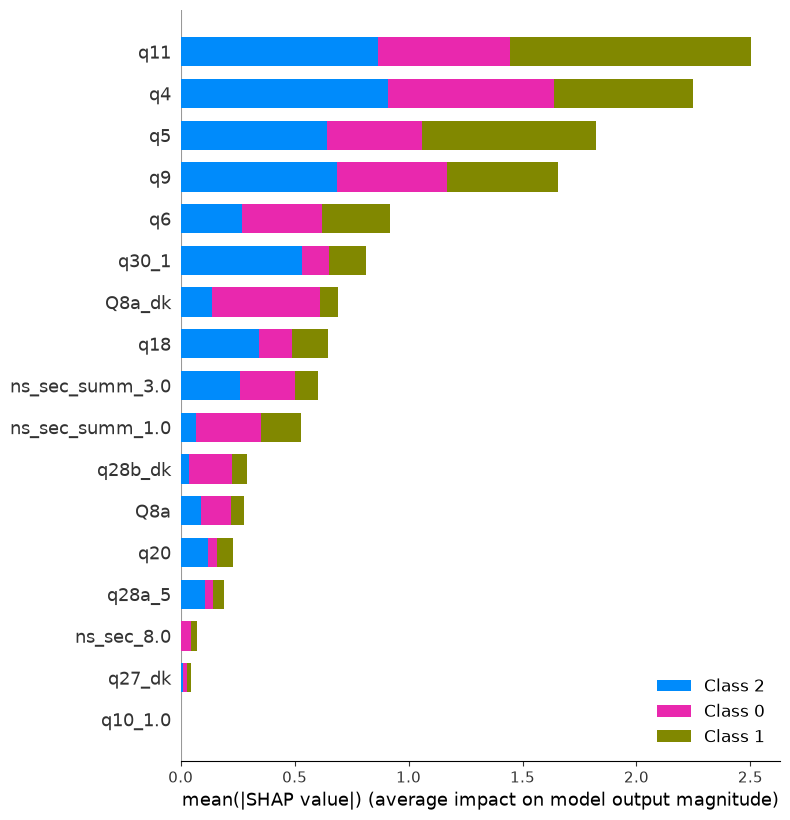

Inactive


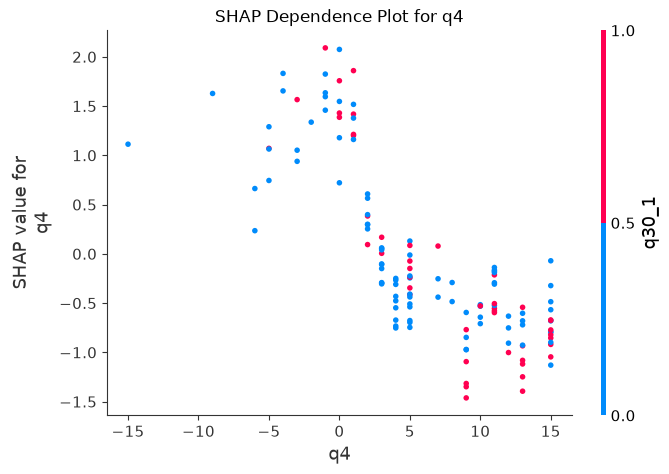

Fairly active


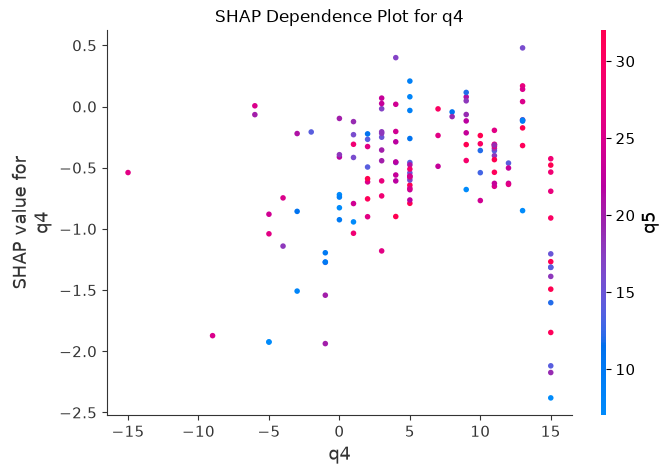

Active


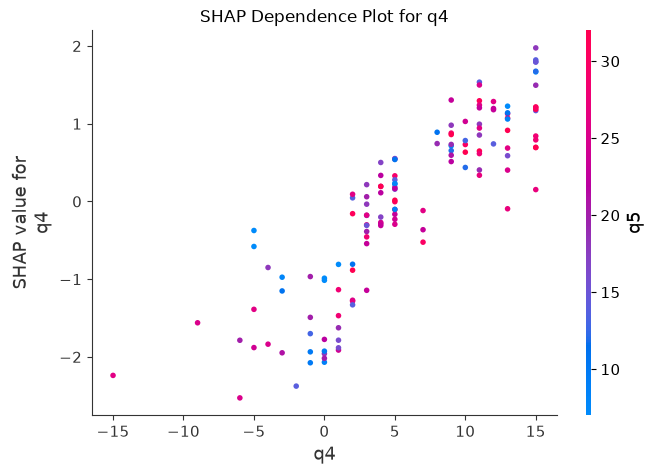

In [812]:
for cond in compare_conditions:
  print('='*50)
  print(cond, '\n')
  model, X_train, X_test, y_train, y_test = do_pipeline_fit_model(
      cond, source_ds_cleaned, target_col_name,
      raw_model_fields_cols, req_model_fields_cols,
      min_cor_val, max_cor_val, is_binary_class)

  explainer = shap.TreeExplainer(model)
  shap_values = explainer(X_test)

  shap.summary_plot(shap_values, X_test, plot_type="bar")
  sorted_features = get_sorted_features_by_importance(
      shap_values,
      X_test,
      importance_type='mean_abs',
      return_df=True,
      is_multiclass=(not is_binary_class),
  )
  display(sorted_features)

  main_feature = sorted_features['feature'][0]

  shap.summary_plot(shap_values, X_test)


  shap_values = raw_shap_to_prob(explainer, X_test)

  if is_binary_class:
    shap.dependence_plot(main_feature, shap_values, X_test, show=False)
    plt.title(f'SHAP Dependence Plot for {main_feature}')
    plt.show()
  else:
    for which_class in range(0,3):
        print(class_names[which_class])
        shap.dependence_plot(main_feature, shap_values[:,:,which_class], X_test, show=False)
        plt.title(f'SHAP Dependence Plot for {main_feature}')
        plt.show()

  print('='*50)
  print('\n\n\n')

## Robust model validation and SHAP stability

This section evaluates new regularised models using a hold-out test set and five-fold validation. It compares the multiclass outcome with an inactive-versus-not-inactive model, checks probability calibration, and measures whether the leading SHAP features for the inactive class are stable across folds. SHAP results remain model explanations rather than causal evidence.

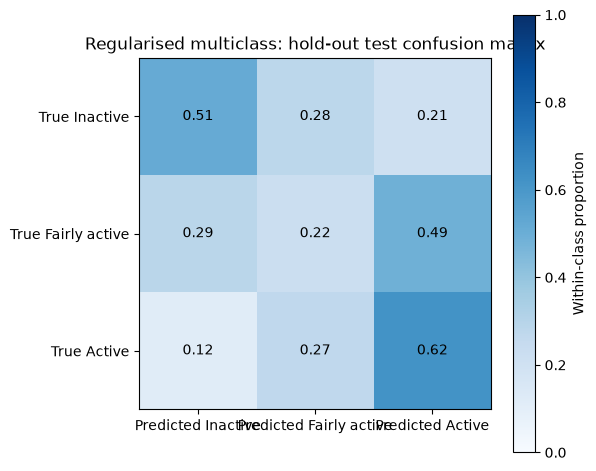

Prepared rows: 1636 | Features: 10

Selected multiclass validation configuration:
max_depth            3.00
min_child_weight    15.00
learning_rate        0.03
subsample            0.90
colsample_bytree     0.80
reg_alpha            0.50
reg_lambda          15.00
dtype: float64

Five-fold tuning results (top 3):


,candidate,macro_f1,balanced_accuracy,inactive_precision,inactive_recall,inactive_f1,selection_score
0,4,0.487,0.487,0.672,0.614,0.640,0.564
1,5,0.484,0.482,0.668,0.612,0.638,0.561
2,2,0.487,0.487,0.683,0.596,0.634,0.561



Untouched hold-out test metrics:


,test_accuracy,test_balanced_accuracy,test_macro_f1,inactive_precision,inactive_recall,inactive_f1,multiclass_log_loss
Regularised multiclass,0.518,0.452,0.457,0.718,0.514,0.599,0.965


,test_accuracy,test_balanced_accuracy,inactive_precision,inactive_recall,inactive_f1,brier_score
Regularised binary: inactive vs not inactive,0.738,0.728,0.727,0.646,0.684,0.188



Probability calibration check:


,measure,uncalibrated,calibrated
0,Class-0 Brier score (lower is better),0.209,0.212
1,Multiclass log loss (lower is better),0.965,0.975



SHAP stability for the inactive class (top 12):


,feature,mean_abs_shap,mean_rank,folds_in_top10
7,q4,0.417,1.0,5
0,Q8a_dk,0.142,2.0,5
4,q20,0.088,3.2,5
9,q9,0.067,4.2,5
8,q5,0.055,5.0,5
2,q11,0.048,5.8,5
3,q18,0.033,6.8,5
6,q28b_dk,0.006,8.6,5
5,q27_dk,0.005,8.6,5
1,q10_1.0,0.002,9.8,5


In [813]:
# Leakage-safe validation, model comparison, calibration, and SHAP stability
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import shap
from pathlib import Path
from sklearn.model_selection import StratifiedKFold, train_test_split
from sklearn.impute import SimpleImputer
from sklearn.metrics import (accuracy_score, balanced_accuracy_score, f1_score,
                             precision_score, recall_score, confusion_matrix,
                             brier_score_loss, log_loss)
from sklearn.calibration import CalibratedClassifierCV
from xgboost import XGBClassifier

RANDOM_STATE = 42
RESULTS_DIR = Path('validation_results')
RESULTS_DIR.mkdir(exist_ok=True)
RELEVANT_FIGURE_DIR = Path('relevant_figures')
RELEVANT_FIGURE_DIR.mkdir(exist_ok=True)

# Use the existing modelling dataset, but construct features and all fitting steps afresh.
validation_target = target_col_name
validation_features = [c for c in model_fields_cols if c != validation_target and c in source_ds.columns]
X_validation = source_ds[validation_features].select_dtypes(include=[np.number]).copy()
y_multiclass = pd.to_numeric(source_ds[validation_target], errors='coerce')
valid_rows = y_multiclass.notna()
X_validation = X_validation.loc[valid_rows].replace([np.inf, -np.inf], np.nan)
y_multiclass = y_multiclass.loc[valid_rows].astype(int)

# Drop all-missing or constant columns. Median imputation remains inside each split.
X_validation = X_validation.dropna(axis=1, how='all')
X_validation = X_validation.loc[:, X_validation.nunique(dropna=True) > 1]
X_train_v, X_test_v, y_train_v, y_test_v = train_test_split(
    X_validation, y_multiclass, test_size=0.20, stratify=y_multiclass,
    random_state=RANDOM_STATE
)

candidate_params = [
    dict(max_depth=2, min_child_weight=5, learning_rate=0.05, subsample=0.80, colsample_bytree=0.70, reg_alpha=0.10, reg_lambda=5.0),
    dict(max_depth=2, min_child_weight=10, learning_rate=0.05, subsample=0.90, colsample_bytree=0.80, reg_alpha=0.30, reg_lambda=10.0),
    dict(max_depth=3, min_child_weight=10, learning_rate=0.03, subsample=0.80, colsample_bytree=0.70, reg_alpha=0.30, reg_lambda=10.0),
    dict(max_depth=3, min_child_weight=15, learning_rate=0.03, subsample=0.90, colsample_bytree=0.80, reg_alpha=0.50, reg_lambda=15.0),
    dict(max_depth=4, min_child_weight=20, learning_rate=0.02, subsample=0.80, colsample_bytree=0.70, reg_alpha=1.00, reg_lambda=20.0),
]

def make_multiclass_model(params):
    return XGBClassifier(
        objective='multi:softprob', num_class=len(np.unique(y_train_v)), n_estimators=180,
        eval_metric='mlogloss', random_state=RANDOM_STATE, n_jobs=1, tree_method='hist',
        verbosity=0, **params
    )

def balanced_sample_weights(y):
    counts = pd.Series(y).value_counts()
    weights = len(y) / (len(counts) * pd.Series(y).map(counts))
    return weights.to_numpy(dtype=float)

def inactive_class_metrics(y_true, y_pred):
    return {
        'inactive_precision': precision_score(y_true, y_pred, labels=[0], average='macro', zero_division=0),
        'inactive_recall': recall_score(y_true, y_pred, labels=[0], average='macro', zero_division=0),
        'inactive_f1': f1_score(y_true, y_pred, labels=[0], average='macro', zero_division=0),
    }

# Tune by mean macro F1 and inactive-class F1, using folds inside training data only.
inner_cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
tuning_rows = []
for candidate_id, params in enumerate(candidate_params, start=1):
    fold_scores = []
    for train_idx, valid_idx in inner_cv.split(X_train_v, y_train_v):
        X_tr_raw, X_va_raw = X_train_v.iloc[train_idx], X_train_v.iloc[valid_idx]
        y_tr, y_va = y_train_v.iloc[train_idx], y_train_v.iloc[valid_idx]
        imputer = SimpleImputer(strategy='median')
        X_tr = imputer.fit_transform(X_tr_raw)
        X_va = imputer.transform(X_va_raw)
        model = make_multiclass_model(params)
        model.fit(X_tr, y_tr, sample_weight=balanced_sample_weights(y_tr))
        prediction = model.predict(X_va)
        fold_scores.append({
            'macro_f1': f1_score(y_va, prediction, average='macro', zero_division=0),
            'balanced_accuracy': balanced_accuracy_score(y_va, prediction),
            **inactive_class_metrics(y_va, prediction)
        })
    mean_scores = pd.DataFrame(fold_scores).mean()
    tuning_rows.append({'candidate': candidate_id, **params, **mean_scores.to_dict(),
                        'selection_score': 0.5 * mean_scores['macro_f1'] + 0.5 * mean_scores['inactive_f1']})
tuning_results = pd.DataFrame(tuning_rows).sort_values('selection_score', ascending=False).reset_index(drop=True)
best_params = candidate_params[int(tuning_results.loc[0, 'candidate']) - 1]

# Fit the selected multiclass model once on training data and evaluate the untouched test set.
final_imputer = SimpleImputer(strategy='median')
X_train_final = final_imputer.fit_transform(X_train_v)
X_test_final = final_imputer.transform(X_test_v)
final_multiclass = make_multiclass_model(best_params)
final_multiclass.fit(X_train_final, y_train_v, sample_weight=balanced_sample_weights(y_train_v))
multiclass_pred = final_multiclass.predict(X_test_final)
multiclass_prob = final_multiclass.predict_proba(X_test_final)
multiclass_metrics = {
    'test_accuracy': accuracy_score(y_test_v, multiclass_pred),
    'test_balanced_accuracy': balanced_accuracy_score(y_test_v, multiclass_pred),
    'test_macro_f1': f1_score(y_test_v, multiclass_pred, average='macro', zero_division=0),
    **inactive_class_metrics(y_test_v, multiclass_pred),
    'multiclass_log_loss': log_loss(y_test_v, multiclass_prob, labels=final_multiclass.classes_)
}

# Binary comparison: inactive (class 0) versus all other stated activity levels.
y_binary_train = (y_train_v == 0).astype(int)
y_binary_test = (y_test_v == 0).astype(int)
negative_to_positive = (y_binary_train == 0).sum() / (y_binary_train == 1).sum()
binary_model = XGBClassifier(
    objective='binary:logistic', n_estimators=180, eval_metric='logloss', random_state=RANDOM_STATE,
    n_jobs=1, tree_method='hist', verbosity=0, scale_pos_weight=negative_to_positive, **best_params
)
binary_model.fit(X_train_final, y_binary_train)
binary_pred = binary_model.predict(X_test_final)
binary_prob = binary_model.predict_proba(X_test_final)[:, 1]
binary_metrics = {
    'test_accuracy': accuracy_score(y_binary_test, binary_pred),
    'test_balanced_accuracy': balanced_accuracy_score(y_binary_test, binary_pred),
    'inactive_precision': precision_score(y_binary_test, binary_pred, zero_division=0),
    'inactive_recall': recall_score(y_binary_test, binary_pred, zero_division=0),
    'inactive_f1': f1_score(y_binary_test, binary_pred, zero_division=0),
    'brier_score': brier_score_loss(y_binary_test, binary_prob),
}

# Calibrate the multiclass probabilities using training-only three-fold sigmoid calibration.
calibrated_model = CalibratedClassifierCV(make_multiclass_model(best_params), method='sigmoid', cv=3)
calibrated_model.fit(X_train_final, y_train_v, sample_weight=balanced_sample_weights(y_train_v))
calibrated_prob = calibrated_model.predict_proba(X_test_final)
class0_position = list(final_multiclass.classes_).index(0)
calibrated_class0_position = list(calibrated_model.classes_).index(0)
calibration_results = pd.DataFrame({
    'measure': ['Class-0 Brier score (lower is better)', 'Multiclass log loss (lower is better)'],
    'uncalibrated': [brier_score_loss((y_test_v == 0).astype(int), multiclass_prob[:, class0_position]),
                      log_loss(y_test_v, multiclass_prob, labels=final_multiclass.classes_)],
    'calibrated': [brier_score_loss((y_test_v == 0).astype(int), calibrated_prob[:, calibrated_class0_position]),
                   log_loss(y_test_v, calibrated_prob, labels=calibrated_model.classes_)]
})

# SHAP stability: feature ranks for inactive class (class 0) across validation folds.
stability_rows = []
for fold, (train_idx, valid_idx) in enumerate(inner_cv.split(X_train_v, y_train_v), start=1):
    imputer = SimpleImputer(strategy='median')
    X_tr = imputer.fit_transform(X_train_v.iloc[train_idx])
    X_va = imputer.transform(X_train_v.iloc[valid_idx])
    model = make_multiclass_model(best_params)
    model.fit(X_tr, y_train_v.iloc[train_idx], sample_weight=balanced_sample_weights(y_train_v.iloc[train_idx]))
    shap_values = shap.TreeExplainer(model).shap_values(X_va)
    if isinstance(shap_values, list):
        class0_shap = shap_values[list(model.classes_).index(0)]
    elif np.asarray(shap_values).ndim == 3:
        class0_shap = np.asarray(shap_values)[:, :, list(model.classes_).index(0)]
    else:
        class0_shap = np.asarray(shap_values)
    fold_importance = np.abs(class0_shap).mean(axis=0)
    rank = pd.Series(fold_importance, index=X_validation.columns).rank(ascending=False, method='min')
    stability_rows.append(pd.DataFrame({'feature': X_validation.columns, 'fold': fold,
                                        'mean_abs_shap': fold_importance, 'rank': rank}))
shap_stability_long = pd.concat(stability_rows, ignore_index=True)
shap_stability = (shap_stability_long.groupby('feature', as_index=False)
                  .agg(mean_abs_shap=('mean_abs_shap', 'mean'), mean_rank=('rank', 'mean'),
                       folds_in_top10=('rank', lambda x: int((x <= 10).sum())))
                  .sort_values(['folds_in_top10', 'mean_abs_shap'], ascending=[False, False]))

# Save reproducible artifacts.
tuning_results.to_csv(RESULTS_DIR / 'multiclass_tuning_results.csv', index=False)
pd.DataFrame([multiclass_metrics], index=['Regularised multiclass']).to_csv(RESULTS_DIR / 'model_test_metrics.csv')
pd.DataFrame([binary_metrics], index=['Regularised binary']).to_csv(RESULTS_DIR / 'binary_test_metrics.csv')
calibration_results.to_csv(RESULTS_DIR / 'calibration_results.csv', index=False)
shap_stability.to_csv(RESULTS_DIR / 'inactive_class_shap_stability.csv', index=False)

cm = confusion_matrix(y_test_v, multiclass_pred, labels=final_multiclass.classes_, normalize='true')
fig, ax = plt.subplots(figsize=(6, 5))
im = ax.imshow(cm, cmap='Blues', vmin=0, vmax=1)
for row in range(cm.shape[0]):
    for col in range(cm.shape[1]): ax.text(col, row, f'{cm[row, col]:.2f}', ha='center', va='center')
activity_labels = {0: 'Inactive', 1: 'Fairly active', 2: 'Active'}
ax.set_xticks(range(len(final_multiclass.classes_)), [f"Predicted {activity_labels.get(c, c)}" for c in final_multiclass.classes_])
ax.set_yticks(range(len(final_multiclass.classes_)), [f"True {activity_labels.get(c, c)}" for c in final_multiclass.classes_])
ax.set_title('Regularised multiclass: hold-out test confusion matrix')
fig.colorbar(im, ax=ax, label='Within-class proportion')
fig.tight_layout(); fig.savefig(RELEVANT_FIGURE_DIR / '31_multiclass_test_confusion_matrix.png', dpi=220, bbox_inches='tight'); plt.show()

print('Prepared rows:', len(X_validation), '| Features:', X_validation.shape[1])
print('\nSelected multiclass validation configuration:')
print(pd.Series(best_params))
print('\nFive-fold tuning results (top 3):')
display(tuning_results[['candidate', 'macro_f1', 'balanced_accuracy', 'inactive_precision', 'inactive_recall', 'inactive_f1', 'selection_score']].head(3).round(3))
print('\nUntouched hold-out test metrics:')
display(pd.DataFrame([multiclass_metrics], index=['Regularised multiclass']).round(3))
display(pd.DataFrame([binary_metrics], index=['Regularised binary: inactive vs not inactive']).round(3))
print('\nProbability calibration check:')
display(calibration_results.round(3))
print('\nSHAP stability for the inactive class (top 12):')
display(shap_stability.head(12).round(3))


## Binary-model SHAP figures

Binary coding is **1 = Inactive** and **0 = Not inactive** (the original fairly active and active classes combined). Positive SHAP values increase the binary model's predicted inactivity score. They explain predictions, not causes.

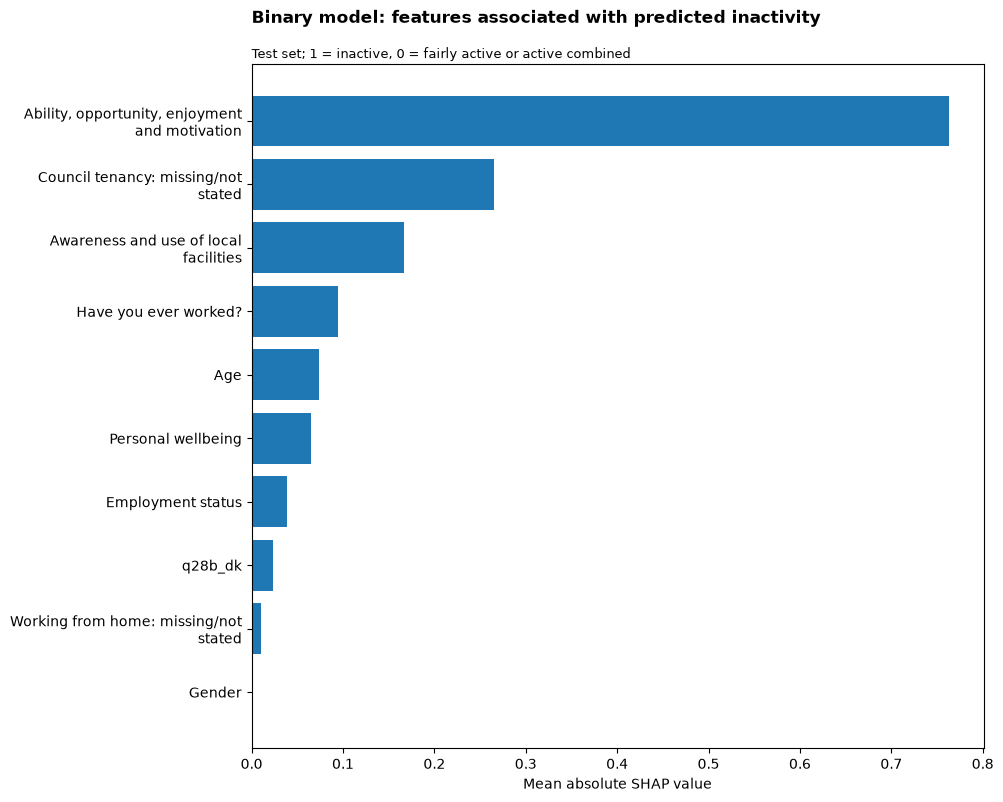

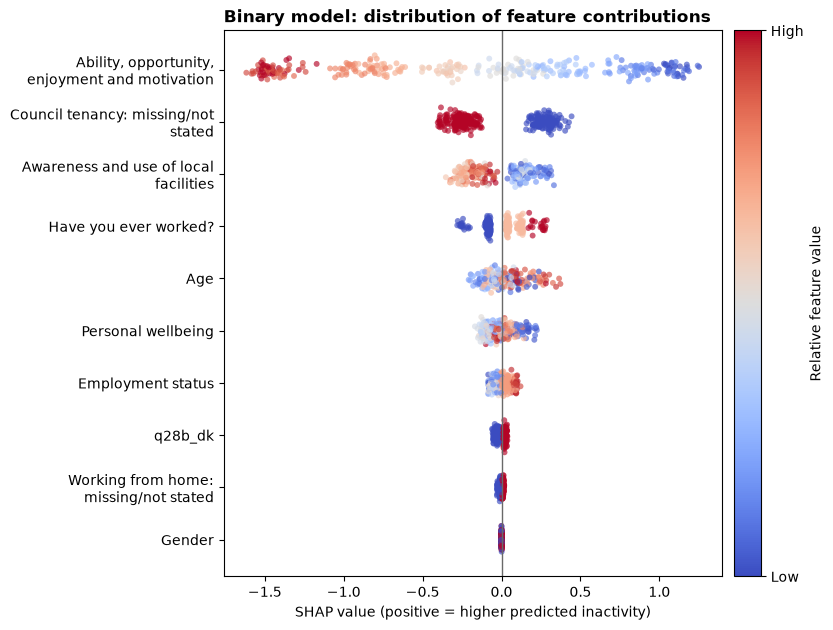

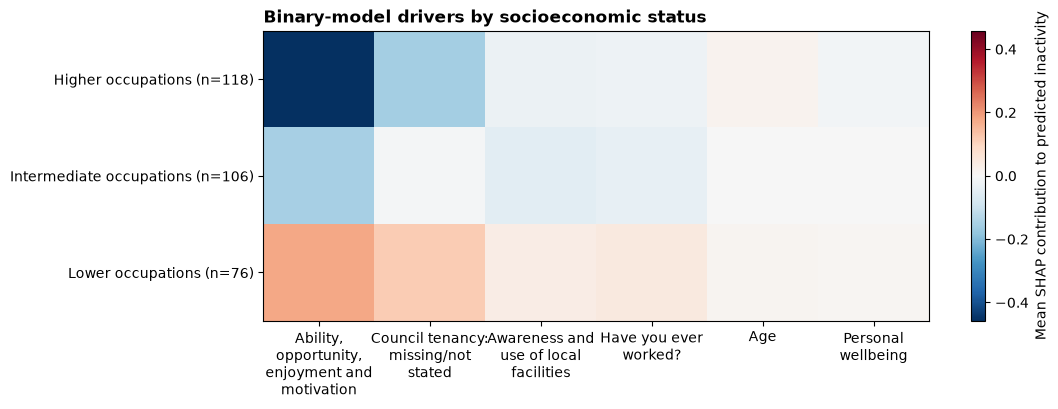

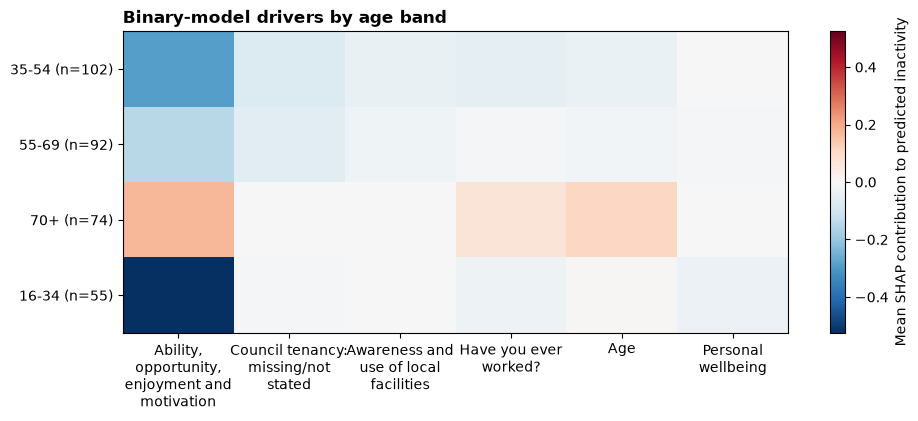

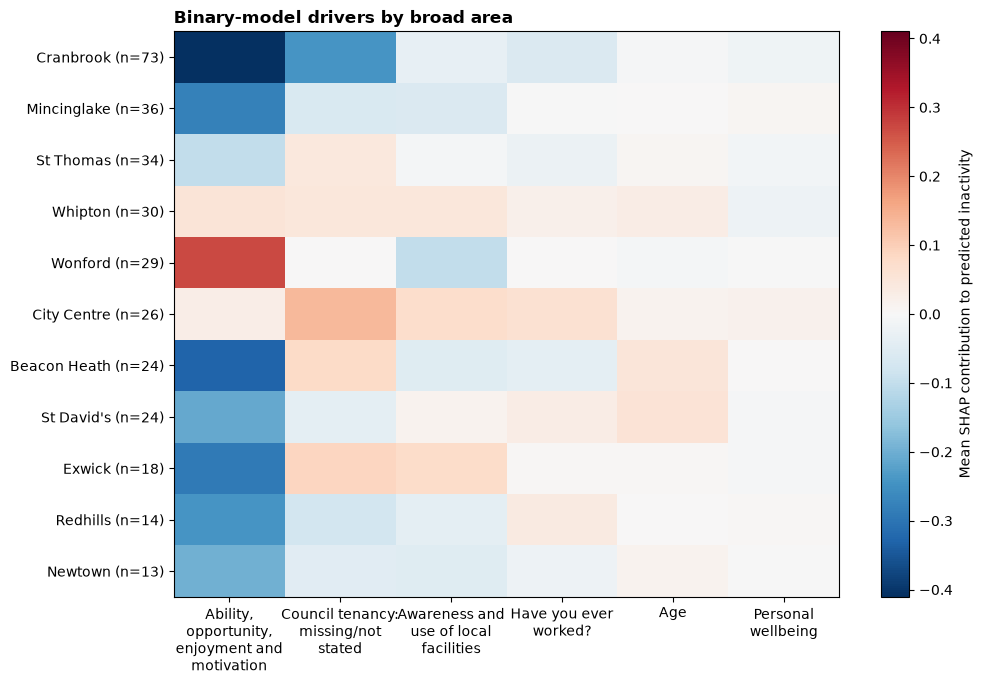

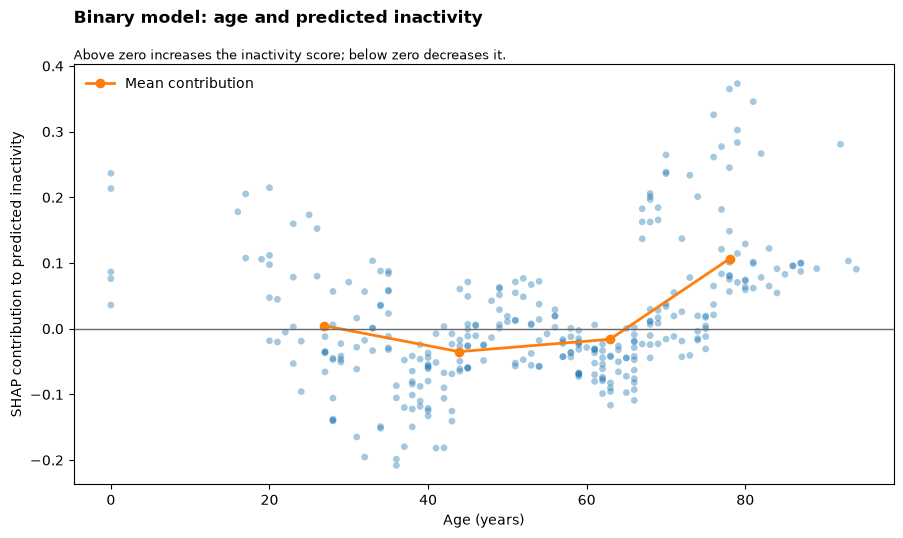

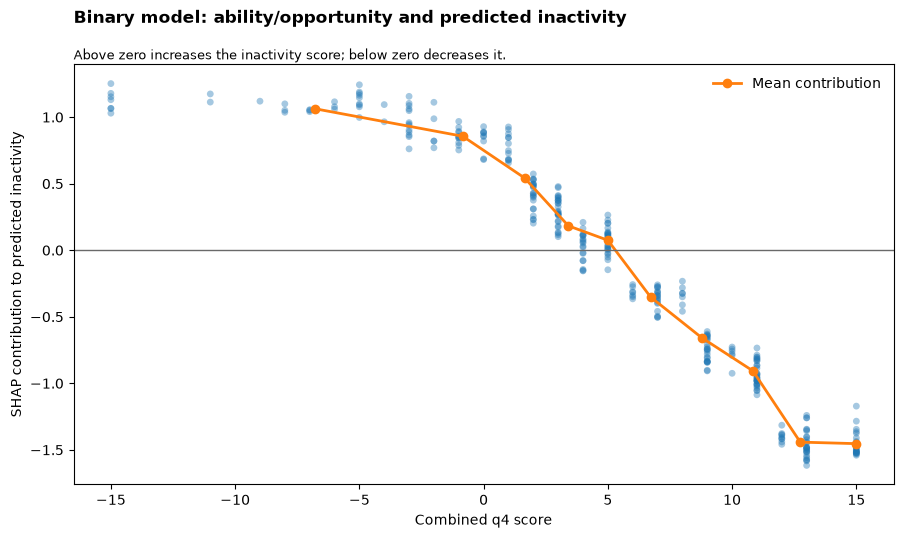

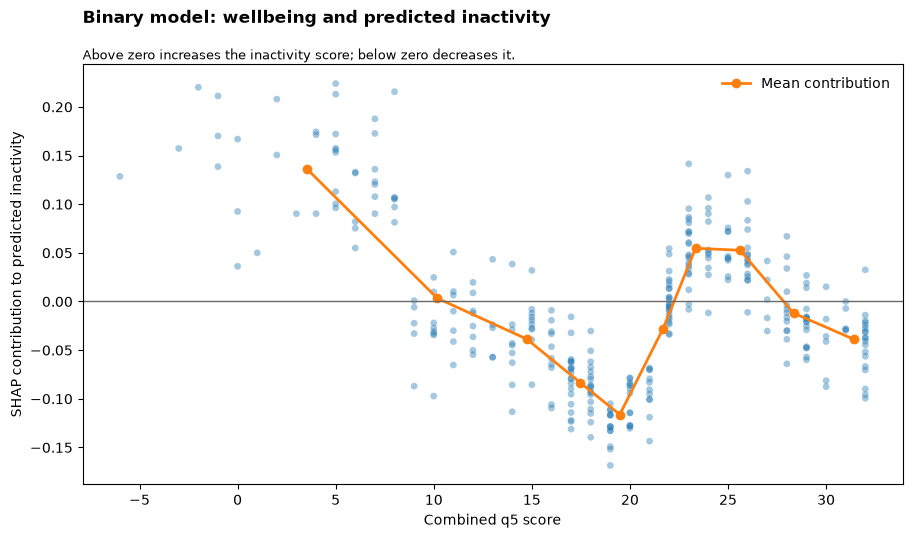

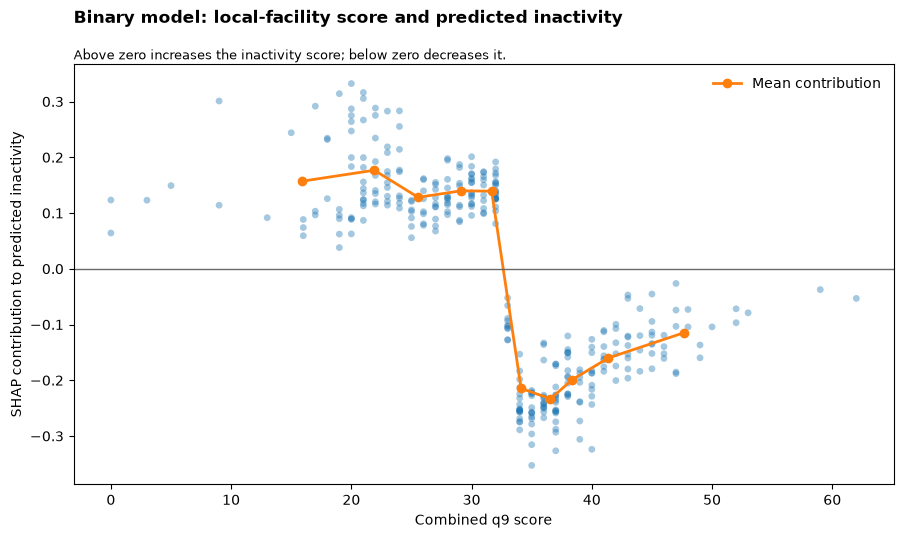

Saved binary-model SHAP figures 22-30.


In [814]:
# Binary SHAP figures: positive values increase predicted inactivity (class 1).
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import shap
import textwrap
from matplotlib.colors import Normalize

BINARY_FIGURE_DIR = Path("relevant_figures")
BINARY_FIGURE_DIR.mkdir(exist_ok=True)
binary_shap = np.asarray(shap.TreeExplainer(binary_model).shap_values(X_test_final))
if binary_shap.ndim == 3:
    binary_shap = binary_shap[:, :, -1]
feature_names_binary = list(X_validation.columns)
label_map = {f: (plot_feature_label(f) if "plot_feature_label" in globals() else f)
             for f in feature_names_binary}
importance_binary = pd.DataFrame({
    "feature": feature_names_binary,
    "label": [label_map[f] for f in feature_names_binary],
    "mean_abs_shap": np.abs(binary_shap).mean(axis=0),
    "mean_shap": binary_shap.mean(axis=0),
}).sort_values("mean_abs_shap", ascending=False)
importance_binary.to_csv(RESULTS_DIR / "binary_shap_feature_importance.csv", index=False)

# 22: global importance
top = importance_binary.head(12).iloc[::-1]
wrapped_top_labels = [textwrap.fill(str(label), width=34) for label in top["label"]]
fig, ax = plt.subplots(figsize=(12, 9))
ax.barh(wrapped_top_labels, top["mean_abs_shap"], color="tab:blue")
ax.set_xlabel("Mean absolute SHAP value")
ax.set_title("Binary model: features associated with predicted inactivity", loc="left", pad=30, fontweight="bold")
ax.text(0, 1.005, "Test set; 1 = inactive, 0 = fairly active or active combined",
        transform=ax.transAxes, fontsize=9, va="bottom")
fig.subplots_adjust(left=0.36, right=0.97, bottom=0.10, top=0.86)
fig.savefig(BINARY_FIGURE_DIR / "22_binary_shap_inactivity_feature_importance.png", dpi=220, bbox_inches="tight")
plt.show()

# 23: beeswarm
top_features = importance_binary.head(12)["feature"].tolist()
top_indices = [feature_names_binary.index(f) for f in top_features]
fig, ax = plt.subplots(figsize=(12.5, 7))
rng = np.random.default_rng(RANDOM_STATE)
for pos, fi in enumerate(reversed(top_indices)):
    colour = pd.Series(X_test_final[:, fi]).rank(pct=True).fillna(.5)
    ax.scatter(binary_shap[:, fi], pos + rng.normal(0, .09, len(colour)), c=colour,
               cmap="coolwarm", s=18, alpha=.65, edgecolors="none")
ax.axvline(0, color="dimgray", lw=1)
wrapped_beeswarm_labels = [textwrap.fill(str(label_map[feature_names_binary[i]]), width=28) for i in reversed(top_indices)]
ax.set_yticks(range(len(top_indices)), wrapped_beeswarm_labels)
ax.set_xlabel("SHAP value (positive = higher predicted inactivity)")
ax.set_title("Binary model: distribution of feature contributions", loc="left", fontweight="bold")
colour_bar = fig.colorbar(plt.cm.ScalarMappable(norm=Normalize(0, 1), cmap="coolwarm"), ax=ax, pad=0.02)
colour_bar.set_ticks([0, 1]); colour_bar.set_ticklabels(["Low", "High"])
colour_bar.set_label("Relative feature value")
fig.subplots_adjust(left=0.40, right=0.88, bottom=0.12, top=0.90)
fig.savefig(BINARY_FIGURE_DIR / "23_binary_shap_inactivity_beeswarm.png", dpi=220, bbox_inches="tight")
plt.show()

# Metadata for test respondents enables subgroup profiles.
binary_meta = subgroup_df.reindex(X_test_v.index).copy() if "subgroup_df" in globals() else pd.DataFrame(index=X_test_v.index)
profile_features = importance_binary.head(6)["feature"].tolist()
profile_indices = [feature_names_binary.index(f) for f in profile_features]
profile_labels = [textwrap.fill(str(label_map[f]), width=16) for f in profile_features]
for group_col, output_name, title in [
    ("socioeconomic_status", "24_binary_shap_driver_profile_by_ses.png", "Binary-model drivers by socioeconomic status"),
    ("age_band", "25_binary_shap_driver_profile_by_age.png", "Binary-model drivers by age band"),
    ("broad_area_name", "26_binary_shap_driver_profile_by_broad_area.png", "Binary-model drivers by broad area"),
]:
    if group_col not in binary_meta:
        print(f"Skipped {group_col}: metadata unavailable.")
        continue
    counts = binary_meta[group_col].value_counts()
    groups = counts[counts >= 10].index.tolist()
    if not groups:
        print(f"Skipped {group_col}: no test-set groups with n >= 10.")
        continue
    matrix = np.array([binary_shap[binary_meta[group_col].eq(g).to_numpy()][:, profile_indices].mean(axis=0) for g in groups])
    limit = np.abs(matrix).max()
    fig, ax = plt.subplots(figsize=(13, max(5, 0.65 * len(groups) + 2.6)))
    image = ax.imshow(matrix, cmap="RdBu_r", vmin=-limit, vmax=limit, aspect="auto")
    ax.set_xticks(range(len(profile_labels)), profile_labels, rotation=0, ha="center")
    ax.set_yticks(range(len(groups)), [f"{group} (n={counts[group]})" for group in groups])
    ax.set_title(title, loc="left", fontweight="bold")
    fig.colorbar(image, ax=ax, label="Mean SHAP contribution to predicted inactivity")
    fig.subplots_adjust(left=0.22, right=0.86, bottom=0.30, top=0.88)
    fig.savefig(BINARY_FIGURE_DIR / output_name, dpi=220, bbox_inches="tight")
    plt.show()

# 27-30: value-effect charts for the leading survey scales.
def binary_dependence(feature, title, xlabel, filename, age_bands=False):
    if feature not in feature_names_binary:
        print(f"Skipped {feature}: absent from binary model.")
        return
    fi = feature_names_binary.index(feature)
    effect = pd.DataFrame({"value": X_test_final[:, fi], "shap": binary_shap[:, fi]})
    if age_bands:
        effect["group"] = pd.cut(effect["value"], [16, 35, 55, 70, np.inf], right=False,
                                 labels=["16-34", "35-54", "55-69", "70+"])
        average = effect.groupby("group", observed=True).agg(value=("value", "mean"), shap=("shap", "mean"))
    elif effect["value"].nunique() <= 12:
        average = effect.groupby("value", observed=True)["shap"].mean().reset_index()
    else:
        effect["group"] = pd.qcut(effect["value"], q=min(10, effect["value"].nunique()), duplicates="drop")
        average = effect.groupby("group", observed=True).agg(value=("value", "mean"), shap=("shap", "mean"))
    fig, ax = plt.subplots(figsize=(10, 6))
    ax.scatter(effect["value"], effect["shap"], s=24, alpha=.4, color="tab:blue", edgecolors="none")
    ax.plot(average["value"], average["shap"], color="tab:orange", marker="o", lw=2, label="Mean contribution")
    ax.axhline(0, color="dimgray", lw=1)
    ax.set_xlabel(xlabel); ax.set_ylabel("SHAP contribution to predicted inactivity")
    ax.set_title(f"Binary model: {title} and predicted inactivity", loc="left", pad=30, fontweight="bold")
    ax.text(0, 1.005, "Above zero increases the inactivity score; below zero decreases it.",
            transform=ax.transAxes, fontsize=9, va="bottom")
    ax.legend(frameon=False)
    fig.subplots_adjust(left=0.15, right=0.97, bottom=0.15, top=0.85)
    fig.savefig(BINARY_FIGURE_DIR / filename, dpi=220, bbox_inches="tight")
    plt.show()

binary_dependence("q11", "age", "Age (years)", "27_binary_shap_age_value_effect.png", age_bands=True)
binary_dependence("q4", "ability/opportunity", "Combined q4 score", "28_binary_shap_ability_opportunity_value_effect.png")
binary_dependence("q5", "wellbeing", "Combined q5 score", "29_binary_shap_wellbeing_value_effect.png")
binary_dependence("q9", "local-facility score", "Combined q9 score", "30_binary_shap_local_facility_value_effect.png")
print("Saved binary-model SHAP figures 22-30.")


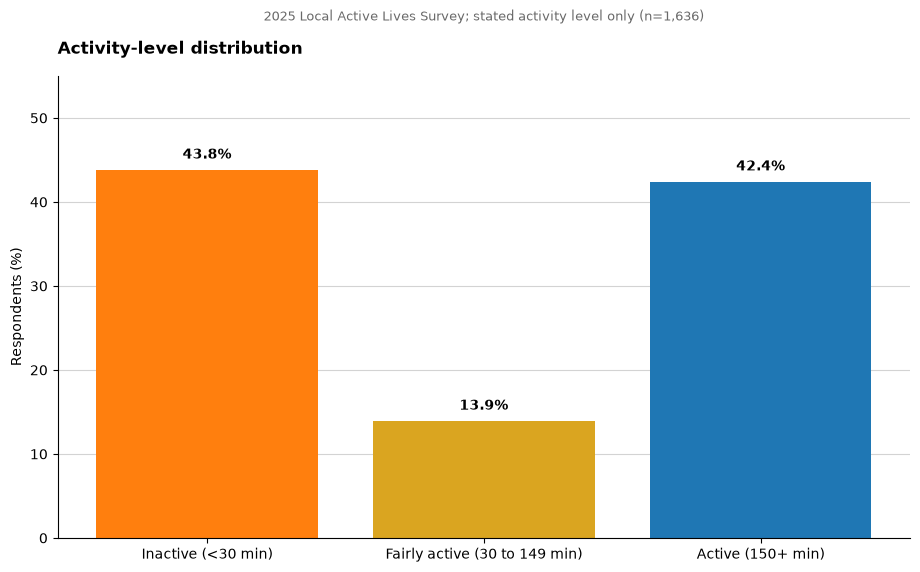

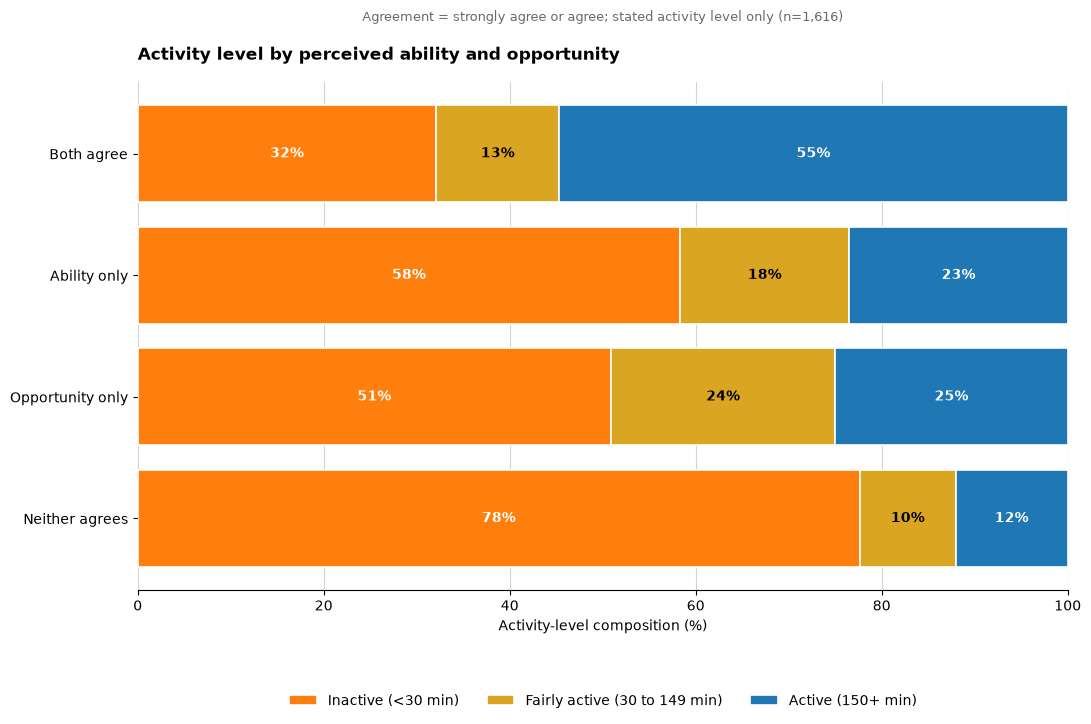

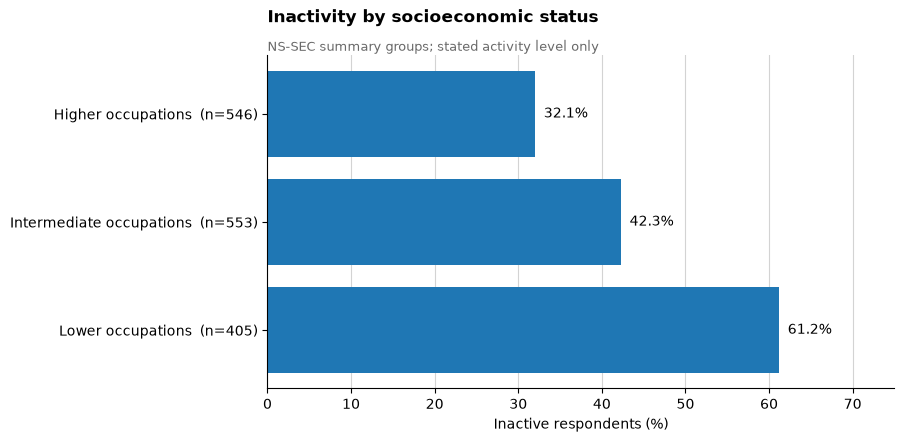

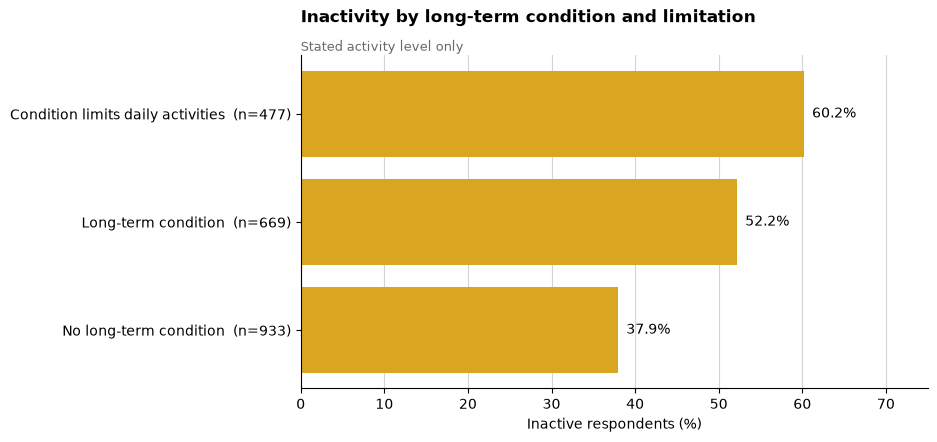

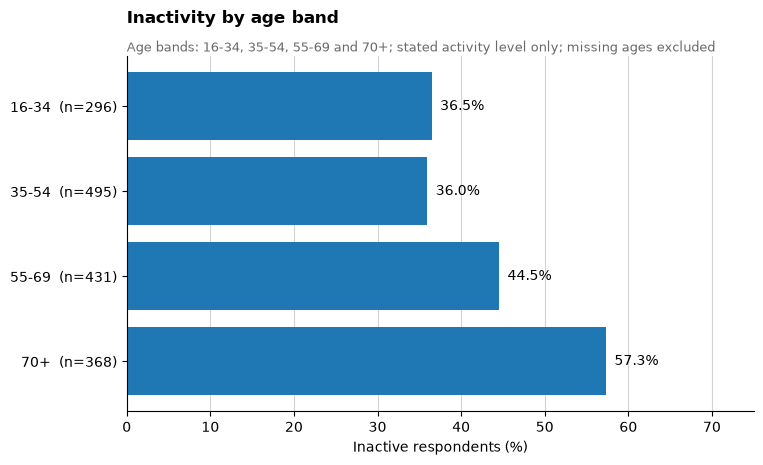

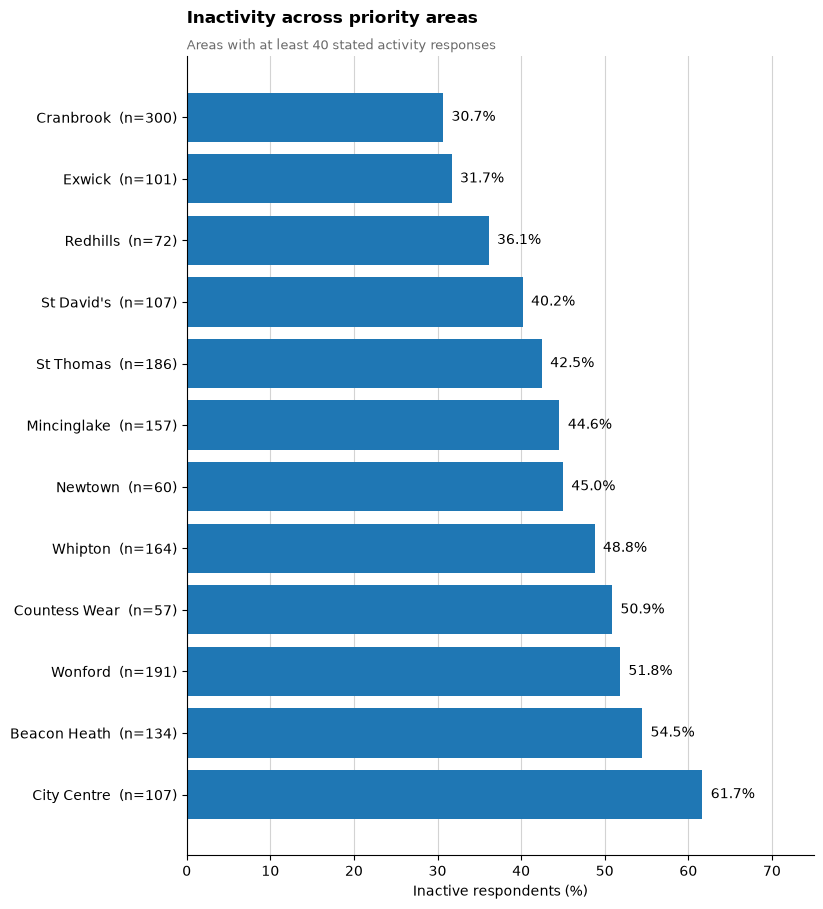

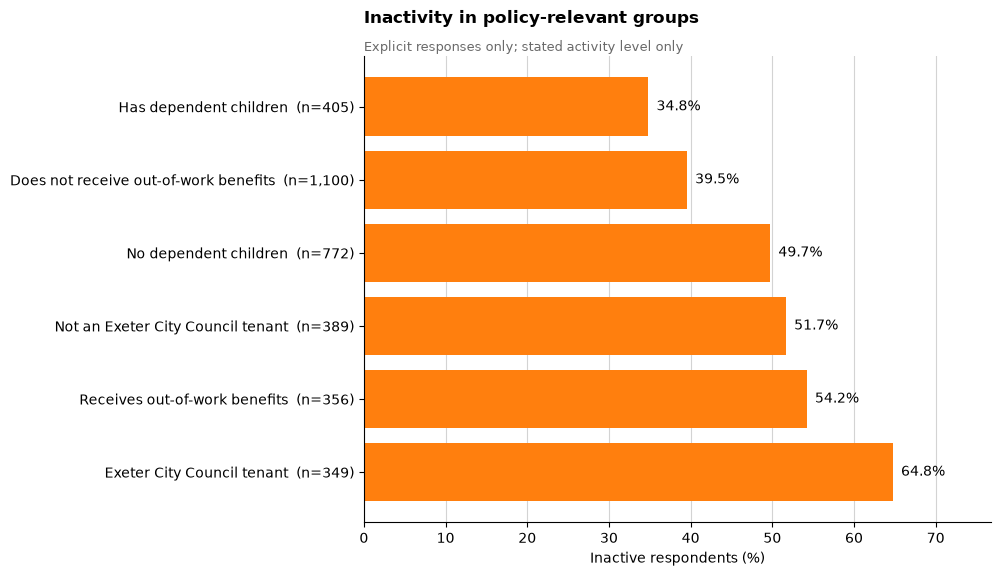

Regenerated descriptive report figures 01-07.


In [815]:
# Restored report figures 01-07: descriptive survey charts with no weighting label in the image.
RESTORED_FIGURE_DIR = Path("relevant_figures")
RESTORED_FIGURE_DIR.mkdir(exist_ok=True)

descriptive_df = raw_ds.loc[raw_ds["activity_level"].isin([1.0, 2.0, 3.0])].copy()
descriptive_df["inactive"] = descriptive_df["activity_level"].eq(1.0)

activity_labels = {
    1.0: "Inactive (<30 min)",
    2.0: "Fairly active (30 to 149 min)",
    3.0: "Active (150+ min)",
}
activity_colours = ["tab:orange", "goldenrod", "tab:blue"]


def style_rate_chart(ax):
    ax.xaxis.grid(True, color="lightgray", linewidth=0.8)
    ax.set_axisbelow(True)
    ax.spines[["top", "right"]].set_visible(False)


def save_horizontal_rate_chart(summary, title, subtitle, filename, colour="tab:blue"):
    fig, ax = plt.subplots(figsize=(11, max(4.5, 0.75 * len(summary) + 1.8)))
    bars = ax.barh(summary["label"], summary["rate"], color=colour)
    for bar, value in zip(bars, summary["rate"]):
        ax.text(bar.get_width() + 1.0, bar.get_y() + bar.get_height() / 2, f"{value:.1f}%",
                va="center", fontsize=10)
    ax.set_xlim(0, max(75, summary["rate"].max() + 12))
    ax.set_xlabel("Inactive respondents (%)")
    ax.set_title(title, loc="left", pad=24, fontweight="bold")
    ax.text(0, 1.005, subtitle, transform=ax.transAxes, fontsize=9, va="bottom", color="dimgray")
    style_rate_chart(ax)
    fig.subplots_adjust(left=0.36, right=0.93, bottom=0.12, top=0.86)
    fig.savefig(RESTORED_FIGURE_DIR / filename, dpi=220, bbox_inches="tight")
    plt.show()


# Figure 01: stated activity-level distribution.
activity_distribution = (
    descriptive_df["activity_level"].value_counts(normalize=True).reindex([1.0, 2.0, 3.0]).mul(100)
)
fig, ax = plt.subplots(figsize=(11, 6))
bars = ax.bar([activity_labels[level] for level in activity_distribution.index],
              activity_distribution.to_numpy(), color=activity_colours)
for bar, value in zip(bars, activity_distribution):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 1.0, f"{value:.1f}%",
            ha="center", va="bottom", fontweight="bold")
ax.set_ylim(0, max(55, activity_distribution.max() + 10))
ax.set_ylabel("Respondents (%)")
ax.set_title("Activity-level distribution", loc="left", pad=16, fontweight="bold")
ax.text(0.5, 1.12, f"2025 Local Active Lives Survey; stated activity level only (n={len(descriptive_df):,})",
        transform=ax.transAxes, ha="center", color="dimgray", fontsize=9)
ax.spines[["top", "right"]].set_visible(False)
ax.yaxis.grid(True, color="lightgray", linewidth=0.8)
ax.set_axisbelow(True)
fig.savefig(RESTORED_FIGURE_DIR / "01_activity_level_distribution.png", dpi=220, bbox_inches="tight")
plt.show()

# Figure 02: activity composition by perceived ability and opportunity.
valid_agreement = descriptive_df["q4a"].isin([1.0, 2.0, 3.0, 4.0, 5.0]) & descriptive_df["q4b"].isin([1.0, 2.0, 3.0, 4.0, 5.0])
agreement_df = descriptive_df.loc[valid_agreement].copy()
agreement_df["ability_agrees"] = agreement_df["q4a"].isin([1.0, 2.0])
agreement_df["opportunity_agrees"] = agreement_df["q4b"].isin([1.0, 2.0])
agreement_df["group"] = np.select(
    [
        agreement_df["ability_agrees"] & agreement_df["opportunity_agrees"],
        agreement_df["ability_agrees"] & ~agreement_df["opportunity_agrees"],
        ~agreement_df["ability_agrees"] & agreement_df["opportunity_agrees"],
    ],
    ["Both agree", "Ability only", "Opportunity only"],
    default="Neither agrees",
)
agreement_order = ["Neither agrees", "Opportunity only", "Ability only", "Both agree"]
composition = (
    pd.crosstab(agreement_df["group"], agreement_df["activity_level"], normalize="index")
    .reindex(index=agreement_order, columns=[1.0, 2.0, 3.0])
    .mul(100)
)
fig, ax = plt.subplots(figsize=(12, 6.6))
left = np.zeros(len(composition))
for level, colour in zip([1.0, 2.0, 3.0], activity_colours):
    values = composition[level].to_numpy()
    bars = ax.barh(composition.index, values, left=left, color=colour, edgecolor="white", linewidth=1.2,
                   label=activity_labels[level])
    for bar, value, start in zip(bars, values, left):
        if value >= 8:
            ax.text(start + value / 2, bar.get_y() + bar.get_height() / 2, f"{value:.0f}%",
                    ha="center", va="center", fontweight="bold",
                    color="white" if level in [1.0, 3.0] else "black")
    left += values
ax.set_xlim(0, 100)
ax.set_xlabel("Activity-level composition (%)")
ax.set_title("Activity level by perceived ability and opportunity", loc="left", pad=16, fontweight="bold")
ax.text(0.5, 1.12, f"Agreement = strongly agree or agree; stated activity level only (n={len(agreement_df):,})",
        transform=ax.transAxes, ha="center", color="dimgray", fontsize=9)
ax.xaxis.grid(True, color="lightgray", linewidth=0.8)
ax.set_axisbelow(True)
ax.spines[["top", "right", "left"]].set_visible(False)
ax.legend(ncol=3, loc="upper center", bbox_to_anchor=(0.5, -0.18), frameon=False)
fig.savefig(RESTORED_FIGURE_DIR / "02_ability_opportunity_paradox.png", dpi=220, bbox_inches="tight")
plt.show()

# Figure 03: socioeconomic status.
ses_map = {
    1.0: "Higher occupations",
    2.0: "Intermediate occupations",
    3.0: "Lower occupations",
}
ses_summary = (
    descriptive_df.loc[descriptive_df["ns_sec_summ"].isin(ses_map)]
    .groupby("ns_sec_summ", observed=True)["inactive"]
    .agg(n="size", rate="mean")
    .reindex([3.0, 2.0, 1.0])
    .reset_index()
)
ses_summary["label"] = ses_summary.apply(
    lambda row: f"{ses_map[row['ns_sec_summ']]}  (n={int(row['n'])})", axis=1
)
ses_summary["rate"] *= 100
save_horizontal_rate_chart(
    ses_summary, "Inactivity by socioeconomic status",
    "NS-SEC summary groups; stated activity level only",
    "03_inactivity_by_socioeconomic_status.png",
)

# Figure 04: health status (q16 / q17).
health_groups = [
    ("No long-term condition", descriptive_df["q16"].eq(2.0)),
    ("Long-term condition", descriptive_df["q16"].eq(1.0)),
    ("Condition limits daily activities", descriptive_df["q17"].eq(1.0)),
]
health_summary = pd.DataFrame([
    {"label": f"{label}  (n={int(mask.sum())})", "rate": descriptive_df.loc[mask, "inactive"].mean() * 100}
    for label, mask in health_groups if mask.any()
])
save_horizontal_rate_chart(
    health_summary, "Inactivity by long-term condition and limitation",
    "Stated activity level only",
    "04_inactivity_by_health_status.png", colour="goldenrod",
)

# Figure 05: requested report age bands.
legacy_age_band = pd.cut(
    descriptive_df["q11"], bins=[15, 34, 54, 69, np.inf],
    labels=["16-34", "35-54", "55-69", "70+"], include_lowest=True
)
age_summary = (
    descriptive_df.assign(age_band=legacy_age_band)
    .dropna(subset=["age_band"])
    .groupby("age_band", observed=True)["inactive"]
    .agg(n="size", rate="mean")
    .reindex(["70+", "55-69", "35-54", "16-34"])
    .reset_index()
)
age_summary["label"] = age_summary.apply(lambda row: f"{row['age_band']}  (n={int(row['n'])})", axis=1)
age_summary["rate"] *= 100
save_horizontal_rate_chart(
    age_summary, "Inactivity by age band",
    "Age bands: 16-34, 35-54, 55-69 and 70+; stated activity level only; missing ages excluded",
    "05_inactivity_by_age_band.png",
)

# Figure 06: broad areas with at least 40 stated activity responses.
area_summary_legacy = (
    descriptive_df.dropna(subset=["broad_area_name"])
    .groupby("broad_area_name", observed=True)["inactive"]
    .agg(n="size", rate="mean")
    .query("n >= 40")
    .sort_values("rate", ascending=False)
    .reset_index()
)
area_summary_legacy["label"] = area_summary_legacy.apply(
    lambda row: f"{row['broad_area_name']}  (n={int(row['n'])})", axis=1
)
area_summary_legacy["rate"] *= 100
save_horizontal_rate_chart(
    area_summary_legacy, "Inactivity across priority areas",
    "Areas with at least 40 stated activity responses",
    "06_inactivity_by_priority_area.png",
)

# Figure 07: policy-relevant groups based on explicit survey responses.
policy_groups = [
    ("Exeter City Council tenant", descriptive_df["Q8a"].eq(1.0)),
    ("Receives out-of-work benefits", descriptive_df["receive_oow_ben"].eq(1.0)),
    ("Not an Exeter City Council tenant", descriptive_df["Q8a"].eq(2.0)),
    ("No dependent children", descriptive_df["no_dep_children"].eq(1.0)),
    ("Does not receive out-of-work benefits", descriptive_df["receive_oow_ben"].eq(2.0)),
    ("Has dependent children", descriptive_df["dep_children"].eq(1.0)),
]
policy_summary = pd.DataFrame([
    {"label": f"{label}  (n={int(mask.sum()):,})", "rate": descriptive_df.loc[mask, "inactive"].mean() * 100}
    for label, mask in policy_groups if mask.any()
]).sort_values("rate", ascending=False)
save_horizontal_rate_chart(
    policy_summary, "Inactivity in policy-relevant groups",
    "Explicit responses only; stated activity level only",
    "07_inactivity_by_policy_group.png", colour="tab:orange",
)

print("Regenerated descriptive report figures 01-07.")
